## **Step 1: System Dynamics**

In [1]:
import torch

def system_dynamics(state_vector, control_input, mass, inertia, g):
    """
    Physics of the drone
    State_vector = [x, y, z, roll, pitch, yaw, vx, vy, vz, w_roll, w_pitch, w_yaw]
    Control_input = [thrust, torque_roll, torque_pitch, torque_yaw]
    """
    # # Physical parameters definition REMEMBER TO ADJUST IF NECESSARY
    # g = 9.81  # gravity [m/s^2]
    # mass = 2.0  # mass of the drone [kg]
    # inertia = torch.tensor([0.0216, 0.0216, 0.04])  # inertia around roll (Ix), pitch (Iy), yaw (Iz) [kg*m^2]
    if not isinstance(inertia, torch.Tensor):
        inertia = torch.tensor(inertia)

    # Unpack state vector
    x, y, z, roll, pitch, yaw, vx, vy, vz, w_roll, w_pitch, w_yaw = state_vector[:,0], state_vector[:,1], state_vector[:,2], state_vector[:,3], state_vector[:,4], state_vector[:,5], state_vector[:,6], state_vector[:,7], state_vector[:,8], state_vector[:,9], state_vector[:,10], state_vector[:,11]
    thrust, torque_roll, torque_pitch, torque_yaw = control_input[:,0], control_input[:,1], control_input[:,2], control_input[:,3]
    
    # # Move sin/cos components to torch tensors (if they aren't already) to be consistent with the rest of the states
    # if not isinstance(roll, torch.Tensor):
    #     roll = torch.tensor(roll)
    # if not isinstance(pitch, torch.Tensor):
    #     pitch = torch.tensor(pitch)
    # if not isinstance(yaw, torch.Tensor):
    #     yaw = torch.tensor(yaw)

    # NOTICE THAT: the dataset is recorded in the North-East-Down (NED) frame, so z is positive downwards. The system dynamics then must be consistent with this frame ( ==> vz_dot gravity is positive and thrust is negative)
    # Compute dynamics
    x_dot = vx # world frame
    y_dot = vy # world frame
    z_dot = vz # world frame
    roll_dot = w_roll + (torch.sin(roll) * torch.tan(pitch) * w_pitch) + (torch.cos(roll) * torch.tan(pitch) * w_yaw) # world frame
    pitch_dot = (torch.cos(roll) * w_pitch) - (torch.sin(roll) * w_yaw) # world frame
    yaw_dot = (torch.sin(roll) / torch.cos(pitch) * w_pitch) + (torch.cos(roll) / torch.cos(pitch) * w_yaw) # world frame
    vx_dot = (thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.cos(yaw) + torch.sin(roll) * torch.sin(yaw)) # world frame
    vy_dot = (thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.sin(yaw) - torch.sin(roll) * torch.cos(yaw)) # world frame
    vz_dot = g + (thrust / mass) * (torch.cos(roll) * torch.cos(pitch)) # world frame
    w_roll_dot = (inertia[1]-inertia[2]) / inertia[0] * w_pitch * w_yaw + torque_roll / inertia[0] # body frame
    w_pitch_dot = (inertia[2]-inertia[0]) / inertia[1] * w_roll * w_yaw + torque_pitch / inertia[1] # body frame
    w_yaw_dot = (inertia[0]-inertia[1]) / inertia[2] * w_roll * w_pitch + torque_yaw / inertia[2] # body frame

    state_vector_dot = torch.stack([x_dot, y_dot, z_dot,
                                  roll_dot, pitch_dot, yaw_dot,
                                  vx_dot, vy_dot, vz_dot,
                                  w_roll_dot, w_pitch_dot, w_yaw_dot], dim=1) 

    # Return derivatives of the state vector
    return state_vector_dot

## **Step 2: NN model**

In [2]:
import torch
import torch.nn as nn
from torch.nn.utils import spectral_norm
import numpy as np

class ResidualBModel(nn.Module):
    """
    Input:  [sin/cos(roll,pitch,yaw), v(3), w(3), u(4)]  -> (B,16)
    Output: discrete corrections [Δv(3), Δw(3)]          -> (B,6)
    """
    def __init__(self, hidden_layers_size, activation_fn, S=None, output_activation=nn.Identity):
        super().__init__()
        self.n_out = 6 # corrections for vx, vy, vz, w_roll, w_pitch, w_yaw
        n_control = 4 # thrust, torque_roll, torque_pitch, torque_yaw
        n_input = 6 + 3 + 3 + n_control  # sin/cos(roll,pitch,yaw) + v(3) + w(3) + u(4)
        #self.dropout = nn.Dropout(p=0.05) # Start with 10% dropout

        layers = [nn.Linear(n_input, hidden_layers_size[0]), activation_fn()]
        for i in range(len(hidden_layers_size) - 1):
            layers += [nn.Linear(hidden_layers_size[i], hidden_layers_size[i + 1]), activation_fn()]

        layers += [nn.Linear(hidden_layers_size[-1], self.n_out), output_activation()]
        self.corr_net = nn.Sequential(*layers)
        for m in self.corr_net.modules():
            if isinstance(m, nn.Linear):
            # Check if spectral_norm is applied: it renames 'weight' to 'weight_orig'
                target_w = m.weight_orig if hasattr(m, 'weight_orig') else m.weight
                if activation_fn == nn.ReLU: # ReLU is simple and effective. He Uniform initialization is recommended for ReLU.
                        nn.init.kaiming_uniform_(target_w, nonlinearity='relu')
                        if m.bias is not None:
                            nn.init.zeros_(m.bias)
                elif activation_fn == nn.ELU: # ELU is smooth and can produce negative outputs, which can help with learning corrections that reduce velocities. He Normal initialization is recommended for ELU.
                        #nn.init.kaiming_uniform_(m.weight, nonlinearity='leaky_relu')
                        nn.init.xavier_uniform_(target_w) # Xavier works much better than kaiming
                        if m.bias is not None:
                            nn.init.zeros_(m.bias)
                elif activation_fn == nn.SELU: # SELU is self-normalizing. Good for non dead neurons and stable training. LeCun Normal initialization is recommended for SELU
                        # LeCun Normal Initialization for SELU
                        std = 1 / np.sqrt(m.in_features)
                        nn.init.normal_(target_w, std=std)
                        if m.bias is not None:
                            nn.init.zeros_(m.bias)

        # Input normalization buffers for [v(3), w(3), u(4)]
        self.register_buffer('v_mean', torch.zeros(3, dtype=torch.float32))
        self.register_buffer('v_std', torch.ones(3, dtype=torch.float32))
        self.register_buffer('w_mean', torch.zeros(3, dtype=torch.float32))
        self.register_buffer('w_std', torch.ones(3, dtype=torch.float32))
        self.register_buffer('u_mean', torch.zeros(4, dtype=torch.float32))
        self.register_buffer('u_std', torch.ones(4, dtype=torch.float32))

    def set_input_norm_stats(self, mean, std, eps=1e-8):
        mean_t = torch.as_tensor(mean, dtype=self.v_mean.dtype, device=self.v_mean.device).view(-1)
        std_t = torch.as_tensor(std, dtype=self.v_std.dtype, device=self.v_std.device).view(-1)

        # Expected layout from get_mean_and_std:
        # [lin_pos(3), lin_vel(3), ang_vel(3), lin_acc(3), ang_acc(3), controls(4)]
        self.v_mean.copy_(mean_t[3:6])
        self.v_std.copy_(std_t[3:6].clamp_min(eps))
        self.w_mean.copy_(mean_t[6:9])
        self.w_std.copy_(std_t[6:9].clamp_min(eps))
        self.u_mean.copy_(mean_t[15:19])
        self.u_std.copy_(std_t[15:19].clamp_min(eps))
        print(f"Linear Velocity STD: {model.v_std.cpu().numpy()}")
        print(f"Angular Velocity STD: {model.w_std.cpu().numpy()}")

    def build_features(self, state_vector, control_input):
        roll, pitch, yaw = state_vector[:, 3], state_vector[:, 4], state_vector[:, 5]
        trig = torch.stack([
            torch.sin(roll), torch.cos(roll),
            torch.sin(pitch), torch.cos(pitch),
            torch.sin(yaw), torch.cos(yaw),
        ], dim=1)
        v = state_vector[:, 6:9]
        w = state_vector[:, 9:12]

        # Normalize dynamic states and controls used by the NN input.
        v_n = (v - self.v_mean) / self.v_std
        w_n = (w - self.w_mean) / self.w_std
        u_n = (control_input - self.u_mean) / self.u_std
        #print(f"Linear norm: {v_n}")
        #print(f"Angular norm: {w_n}")

        return torch.cat([trig, v_n, w_n, u_n], dim=1)


    def forward(self, state_vector, control_input):
        z = self.build_features(state_vector, control_input)
        delta_vw_norm = self.corr_net(z)   # (B,6)
        gain_v = 1.0 
        gain_w = 1.0
        gain_w_yaw = 1.0
        
        gains = torch.tensor([gain_v, gain_v, gain_v, gain_w, gain_w, gain_w_yaw], 
                             device=delta_vw_norm.device)
                             
        return delta_vw_norm * gains

## **Step 3: Data preprocessing**

In [3]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def dataset_masking(dataset=None):

    # Add dt column at position 1 (limiting the number to 6 decimal points)
    dataset.insert(1, 'dt', dataset['time'].diff().fillna(0).round(6))  # Calculate time intervals (dt) between consecutive samples and place it in a new column 'dt' in position 1

    # Add Euler angles columns (roll, pitch, yaw) at positions 17, 18, 19
    dataset.insert(17, 'roll', 0.0)
    dataset.insert(18, 'pitch', 0.0)
    dataset.insert(19, 'yaw', 0.0)

    # Add the following non-used columns to match the old dataset format
    dataset.insert(24, 'pwm_1', 0.0)
    dataset.insert(25, 'pwm_2', 0.0)
    dataset.insert(26, 'pwm_3', 0.0)
    dataset.insert(27, 'pwm_4', 0.0)
    dataset.insert(28, 'total_thrust', 0.0)
    #dataset.insert(37, 'true_corr', 0.0) ¤# Column for the true correction (not used for training, but useful for inspection and debugging)

    # Drop the unused columns (from 37 to the end)
    dataset = dataset.drop(columns=dataset.columns[37:])

    return dataset

def from_quaternion_to_euler(dataset=None):
    """
    Convert quaternion orientation to Euler angles (roll, pitch, yaw) in the dataset.
    Quaternion format in dataset: [q_w, q_x, q_y, q_z]
    Euler angles format: [roll, pitch, yaw]
    """
    q_w = dataset[:, 20:21]
    q_x = dataset[:, 21:22]
    q_y = dataset[:, 22:23]
    q_z = dataset[:, 23:24]

    # Compute roll (x-axis rotation)
    sinr_cosp = 2 * (q_w * q_x + q_y * q_z)
    cosr_cosp = 1 - 2 * (q_x**2 + q_y**2)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Compute pitch (y-axis rotation)
    sinp = 2 * (q_w * q_y - q_z * q_x)
    pitch = np.where(np.abs(sinp) >= 1, np.sign(sinp) * (np.pi / 2), np.arcsin(sinp))

    # Compute yaw (z-axis rotation)
    siny_cosp = 2 * (q_w * q_z + q_x * q_y)
    cosy_cosp = 1 - 2 * (q_y**2 + q_z**2)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    # Replace quaternion columns with Euler angles in the dataset (rounding to 6 decimal points)
    dataset[:, 17:18] = np.round(roll, 6)
    dataset[:, 18:19] = np.round(pitch, 6)
    dataset[:, 19:20] = np.round(yaw, 6)

    return dataset

def px4_pwm_to_thrust(dataset = None, mass=2.0, g=9.81):
    """
    1) I need to clamp the values of cmd_thrust between -1 and 0, because out of this interval the drone will read only -1 and 0, so it doesn't make sense to have values outside this range
    2) The cmd_thrust in the dataset is a PWM (or another signal), so i need to apply a conversion factor to get the actual thrust force. This factor is determined empirically to match the hover condition
    """
    cmd_thrust = dataset[:, 29:30] 
    cmd_thrust = np.clip(cmd_thrust, -1.0, 0.0)  # Clamp between -1 and 0

    thrust = cmd_thrust * mass * g / 0.72 #-0.72 # conversion factor to get thrust in Newtons
    dataset[:, 29:30] = np.round(thrust, 6)

    return dataset

# def px4_angular_rate_to_torque(dataset = None, inertia = np.array([0.0216, 0.0216, 0.04])):
#     """
#     Convert PX4 angular velocities ref to torques ref.
#     Let's design 3 PD controllers, one for each axis, to convert angular rate references to torque references.
#     1) tau_roll = Kp_roll * (theta_roll_ref - theta_roll) + Kd_roll * (w_roll_ref - w_roll)
#     2) tau_pitch = Kp_pitch * (theta_pitch_ref - theta_pitch) + Kd_pitch * (w_pitch_ref - w_pitch)
#     3) tau_yaw = Kp_yaw * (theta_yaw_ref - theta_yaw) + Kd_yaw * (w_yaw_ref - w_yaw)

#     Notice that: a) the PX4-gazebo-model for the x500 quadcopter doesn't provide the damping, it provides the time ccontsants (equals for each motor): timeConstantUp = 0.0125 s, timeConstantDown = 0.025 s 
#                     (they probably are the time constants when the motor speed up (faster) or slow down (slower))
#                  b) Since there is no drect damping ratio, we could assume the motor dynamics as first order systems
#                  c) make controller bandwidth significantly lower than motor dynamics bandwidth to avoid instability
#     """

#     # 1) define time constants and compute motor bandwidth
#     time_constant_up = 0.0125  # seconds (it's the time necessary for the motor to reach 63% of the final value when speeding up)
#     time_constant_down = 0.025  # seconds (it's the time necessary for the motor to reach 63% of the final value when slowing down)

#     tau_motor = time_constant_down  # use the slower time constant to stay conservative
#     wn_motor = 1 / tau_motor  # motor bandwidth (rad/s)

#     # 2) define controller bandwidth
#     safety_factor = 0.5  # to ensure stability, make controller bandwidth lower than motor bandwidth
#     wn_controller = safety_factor * wn_motor  # controller bandwidth (rad/s), significantly lower than motor bandwidth

#     # 3) define PD gains for each axis
#     zeta = 0.7  # damping ratio

#     Kp_roll = 2 * zeta * wn_controller * inertia[0]
#     Kd_roll = inertia[0] * wn_controller**2

#     Kp_pitch = 2 * zeta * wn_controller * inertia[1]
#     Kd_pitch = inertia[1] * wn_controller**2

#     Kp_yaw = 2 * zeta * wn_controller * inertia[2]
#     Kd_yaw = inertia[2] * wn_controller**2

#     # 4) find torque references
#     roll_ref = 0 # set to 0 to stabilize the drone
#     pitch_ref = 0 # set to 0 to stabilize the drone
#     yaw_ref = dataset[:, 36:37]  # desired yaw angle from dataset
#     w_roll_ref = dataset[:, 30:31]
#     w_pitch_ref = dataset[:, 31:32]
#     w_yaw_ref = dataset[:, 32:33]

#     roll, pitch, yaw = dataset[:, 17:18], dataset[:, 18:19], dataset[:, 19:20]
#     w_roll, w_pitch, w_yaw = dataset[:, 11:12], dataset[:, 12:13], dataset[:, 13:14]

#     torque_roll = Kp_roll * (roll_ref - roll) + Kd_roll * (w_roll_ref - w_roll)
#     torque_pitch = Kp_pitch * (pitch_ref - pitch) + Kd_pitch * (w_pitch_ref - w_pitch)
#     torque_yaw = Kp_yaw * (yaw_ref - yaw) + Kd_yaw * (w_yaw_ref - w_yaw)

#     dataset[:, 30:31] = np.round(torque_roll, 6)
#     dataset[:, 31:32] = np.round(torque_pitch, 6)
#     dataset[:, 32:33] = np.round(torque_yaw, 6)

#     return dataset


def px4_angular_rate_to_torque(dataset=None, inertia=np.array([0.0216, 0.0216, 0.04])):
    """
    Compute the actual torques applied to the drone by inverting the rotational dynamics equations.
    
    From Euler's rotational equations:
        I_x * alpha_x = (I_y - I_z) * wy * wz + tau_x
        I_y * alpha_y = (I_z - I_x) * wx * wz + tau_y
        I_z * alpha_z = (I_x - I_y) * wx * wy + tau_z
    
    Solving for torques:
        tau_x = I_x * alpha_x - (I_y - I_z) * wy * wz
        tau_y = I_y * alpha_y - (I_z - I_x) * wx * wz
        tau_z = I_z * alpha_z - (I_x - I_y) * wx * wy
    """
    I_x, I_y, I_z = inertia[0], inertia[1], inertia[2]

    # Angular velocities from the dataset
    w_roll = dataset[:, 11:12]
    w_pitch = dataset[:, 12:13]
    w_yaw = dataset[:, 13:14]

    # Angular accelerations from the dataset
    alpha_roll = dataset[:, 14:15]
    alpha_pitch = dataset[:, 15:16]
    alpha_yaw = dataset[:, 16:17]

    # Invert the rotational dynamics to get torques
    tau_x = I_x * alpha_roll - (I_y - I_z) * w_pitch * w_yaw
    tau_y = I_y * alpha_pitch - (I_z - I_x) * w_roll * w_yaw
    tau_z = I_z * alpha_yaw - (I_x - I_y) * w_roll * w_pitch

    # Store torques in the control columns
    dataset[:, 30:31] = np.round(tau_x, 6)
    dataset[:, 31:32] = np.round(tau_y, 6)
    dataset[:, 32:33] = np.round(tau_z, 6)

    return dataset

def get_mean_and_std(dataset=None):
    """
    Get mean and standard deviation of the whole dataset for normalization.
    """
    time = dataset[:, 0:1]
    dt = dataset[:, 1:2]
    linear_pos = dataset[:, 2:5] # x, y, z 
    linear_vel = dataset[:, 5:8] # vx, vy, vz
    linear_acc = dataset[:, 8:11] # a_x, a_y, a_z
    angular_vel = dataset[:, 11:14] # w_x, w_y, w_z
    angular_acc = dataset[:, 14:17] # alpha_x, alpha_y, alpha_z
    angular_pos = dataset[:, 17:20] # roll, pitch, yaw
    rest_of_the_data = dataset[:, 20:29] # other data not used for training
    controls = dataset[:, 29:33] # thrust, torque_roll, torque_pitch, torque_yaw

    lin_pos_mean = linear_pos.mean(axis=0)
    lin_pos_std = linear_pos.std(axis=0) + 1e-8
    
    lin_vel_mean = linear_vel.mean(axis=0)
    lin_vel_std = linear_vel.std(axis=0) + 1e-8
    
    lin_acc_mean = linear_acc.mean(axis=0)
    lin_acc_std = linear_acc.std(axis=0) + 1e-8
    
    ang_vel_mean = angular_vel.mean(axis=0)
    ang_vel_std = angular_vel.std(axis=0) + 1e-8
    
    ang_acc_mean = angular_acc.mean(axis=0)
    ang_acc_std = angular_acc.std(axis=0) + 1e-8
    
    # rest_mean = rest_of_the_data.mean(axis=0)
    # rest_std = rest_of_the_data.std(axis=0) + 1e-8
    
    controls_mean = controls.mean(axis=0)
    controls_std = controls.std(axis=0) + 1e-8

    mean = np.hstack((lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean))
    std = np.hstack((lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std))

    return mean, std

def normalize_data(dataset=None, mean=None, std=None):
    """
    Normalize all the dataset meaningful quantities (so not time or angles for example)
    """
    time = dataset[:, 0:1]
    dt = dataset[:, 1:2]
    linear_pos = dataset[:, 2:5] # x, y, z 
    linear_vel = dataset[:, 5:8] # vx, vy, vz
    linear_acc = dataset[:, 8:11] # a_x, a_y, a_z
    angular_vel = dataset[:, 11:14] # w_x, w_y, w_z
    angular_acc = dataset[:, 14:17] # alpha_x, alpha_y, alpha_z
    angular_pos = dataset[:, 17:20] # roll, pitch, yaw
    rest_of_the_data = dataset[:, 20:29] # other data not used for training
    controls = dataset[:, 29:33] # thrust, torque_roll, torque_pitch, torque_yaw

    # Normalization
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

        # Compute mean and std for each feature
    # lin_pos_mean = linear_pos.mean(axis=0, keepdims=True)
    # lin_pos_std = linear_pos.std(axis=0, keepdims=True) + 1e-8
    
    # lin_vel_mean = linear_vel.mean(axis=0, keepdims=True)
    # lin_vel_std = linear_vel.std(axis=0, keepdims=True) + 1e-8
    
    # lin_acc_mean = linear_acc.mean(axis=0, keepdims=True)
    # lin_acc_std = linear_acc.std(axis=0, keepdims=True) + 1e-8
    
    # ang_vel_mean = angular_vel.mean(axis=0, keepdims=True)
    # ang_vel_std = angular_vel.std(axis=0, keepdims=True) + 1e-8
    
    # ang_acc_mean = angular_acc.mean(axis=0, keepdims=True)
    # ang_acc_std = angular_acc.std(axis=0, keepdims=True) + 1e-8
    
    # rest_mean = rest_of_the_data.mean(axis=0, keepdims=True)
    # rest_std = rest_of_the_data.std(axis=0, keepdims=True) + 1e-8
    
    # controls_mean = controls.mean(axis=0, keepdims=True)
    # controls_std = controls.std(axis=0, keepdims=True) + 1e-8

    # Standardize (z-score normalization)
    linear_pos_normalized = (linear_pos - lin_pos_mean) / lin_pos_std
    linear_vel_normalized = (linear_vel - lin_vel_mean) / lin_vel_std
    linear_acc_normalized = (linear_acc - lin_acc_mean) / lin_acc_std
    angular_vel_normalized = (angular_vel - ang_vel_mean) / ang_vel_std
    angular_acc_normalized = (angular_acc - ang_acc_mean) / ang_acc_std
    # rest_of_the_data_normalized = (rest_of_the_data - rest_mean) / rest_std
    controls_normalized = (controls - controls_mean) / controls_std

    dataset_normalized = np.hstack((time, dt, linear_pos_normalized, linear_vel_normalized, linear_acc_normalized, angular_vel_normalized, angular_acc_normalized, angular_pos, rest_of_the_data, controls_normalized))
    
    return dataset_normalized

def split_data(dataset=None, time_period = 1, dt=0.2, t0 = 30, t1 = 150, t2 = 220):
    """
    Split dataset into training, validation, and testing sets based on time intervals.
    """
    m, _ = dataset.shape

    # Define the delta_t in terms of number of samples
    delta_t = int(time_period / dt)  # number of samples corresponding to the time_period (3/0.2 = 15 samples)

    # Find the first index that corresponding to t0, t1, t2
    start_t0 = np.searchsorted(dataset[:, 0], t0) # index where time >= t0 ( it takes the first index that satisfies the condition)
    start_t1 = np.searchsorted(dataset[:, 0], t1) 
    start_t2 = np.searchsorted(dataset[:, 0], t2)

    end_t0 = start_t0 + delta_t
    end_t1 = start_t1 + delta_t
    end_t2 = start_t2 + delta_t 
    
    data_test_0 = dataset[ start_t0:end_t0, : ]  
    data_test_1 = dataset[ start_t1:end_t1, : ]  
    data_test_2 = dataset[ start_t2:end_t2, : ]

    # Make an array for the tests
    data_test = [data_test_0, data_test_1, data_test_2]

    # Separate testing data from the rest
    data_train_val_0 = dataset[0:start_t0, :]
    data_train_val_1 = dataset[end_t0:start_t1, :]
    data_train_val_2 = dataset[end_t1:start_t2, :]
    data_train_val_3 = dataset[end_t2:m, :]

    # Ensure that the testing/validation samples are evenly distributed in each set, to ease the pair creation (current, next)
    if (data_train_val_0.shape[0] % 2) != 0:
        data_train_val_0 = data_train_val_0[:-1, :] # remove the last sample if odd
    if (data_train_val_1.shape[0] % 2) != 0:
        data_train_val_1 = data_train_val_1[:-1, :]
    if (data_train_val_2.shape[0] % 2) != 0:
        data_train_val_2 = data_train_val_2[:-1, :]
    if (data_train_val_3.shape[0] % 2) != 0:
        data_train_val_3 = data_train_val_3[:-1, :]

    data_train_val = np.vstack((data_train_val_0, data_train_val_1, data_train_val_2, data_train_val_3))

    return data_test, data_train_val


def configure_data(dataset):
    m, n = dataset.shape
    dt_test = dataset[:, 1:2]
    linear_pos = dataset[:,2:5]
    linear_vel = dataset[:,5:8]
    linear_acc = dataset[:, 8:11]
    angular_vel = dataset[:,11:14]
    angular_acc = dataset[:, 14:17]
    angular_pos = dataset[:,17:20]
    states = np.hstack((linear_pos, angular_pos, linear_vel, angular_vel, linear_acc, angular_acc))
    controls = dataset[:, 29:33]

    # states = torch.tensor(np.array(states, dtype=np.float32))
    # controls = torch.tensor(np.array(controls, dtype=np.float32))
    # dt_test = torch.tensor(np.array(dt_test, dtype=np.float32))

    return states, controls, dt_test

def create_and_shuffle_pairs(data=None):
    """
    Create non-overlapping (current, next) pairs and shuffle them.
    This ensures each state appears exactly once in the dataset.
    """
    n_pairs = (data.shape[0] - 1)  # All possible consecutive pairs
    
    # Stack current and next states
    current_samples = data[:-1]   # All except last
    next_samples = data[1:]       # All except first
    t_idx = np.arange(n_pairs)  # Time indices for pairs (0 to n_pairs-1)

    # Create indices and shuffle
    indices = np.arange(n_pairs)
    np.random.seed(42)
    np.random.shuffle(indices)
    
    # Return shuffled pairs
    return current_samples[indices], next_samples[indices], t_idx[indices]


def gap_data_train_val(data_train_val, dt_nominal, split_ratio=0.7, gap_seconds=2.0):
    """
    Split time-ordered data into train/val blocks with purge gap,
    then create+shuffle pairs independently per block.
    """
    N = len(data_train_val)
    split = int(split_ratio * N)
    gap = int(gap_seconds / dt_nominal)

    left_end = max(split - gap, 1)
    right_start = min(split + gap, N - 1)

    train_block = data_train_val[:left_end]
    val_block   = data_train_val[right_start:]

    train_pairs_curr, train_pairs_next, _ = create_and_shuffle_pairs(train_block)
    val_pairs_curr, val_pairs_next, _ = create_and_shuffle_pairs(val_block)

    return train_pairs_curr, train_pairs_next, val_pairs_curr, val_pairs_next, train_block, val_block


def configure_training_and_validation_data(data_current=None, data_next=None):
    """
    Prepare paired data for training. 
    
    Args:
        data_current: Array of current states
        data_next: Array of corresponding next states
    """
    # Extract current state features
    linear_pos_curr = data_current[:,2:5]
    linear_vel_curr = data_current[:,5:8]
    linear_acc_curr = data_current[:, 8:11]
    angular_vel_curr = data_current[:,11:14]
    angular_acc = data_current[:, 14:17]
    angular_pos_curr = data_current[:,17:20]
    states_curr = np.hstack((linear_pos_curr, angular_pos_curr, linear_vel_curr, angular_vel_curr, linear_acc_curr, angular_acc))
    controls_curr = data_current[:, 29:33]
    
    # Extract next state features
    dt = data_next[: ,1]  # time step between current and next state
    linear_pos_next = data_next[:,2:5]
    linear_vel_next = data_next[:,5:8]
    linear_acc_next = data_next[:, 8:11]
    angular_vel_next = data_next[:,11:14]
    angular_acc_next = data_next[:, 14:17]
    angular_pos_next = data_next[:,17:20]
    states_next = np.hstack((linear_pos_next, angular_pos_next, linear_vel_next, angular_vel_next, linear_acc_next, angular_acc_next))
    controls_next = data_next[:, 29:33]

    states_curr = np.array(states_curr, dtype=np.float32)
    states_next = np.array(states_next, dtype=np.float32)
    controls_curr = np.array(controls_curr, dtype=np.float32)
    controls_next = np.array(controls_next, dtype=np.float32)
    dt = np.array(dt, dtype=np.float32)
    
    # vel_curr_norm, vel_next_norm, controls_norm = normalize_data(states_curr[:,3:], states_next[:,3:], controls) # to normalize only velocities and not positions

    # states_curr_norm = np.hstack((states_curr[:, :3], vel_curr_norm))
    # states_next_norm = np.hstack((states_next[:, :3], vel_next_norm))
    
    # Convert to tensors
    X_curr = torch.tensor(states_curr)
    X_next = torch.tensor(states_next)
    U_curr = torch.tensor(controls_curr)
    U_next = torch.tensor(controls_next)
    dt = torch.tensor(dt)
    
    return X_curr, X_next, U_curr, U_next, dt


def save_pairs_to_csv(X_current=None, X_next=None, U_curr=None, U_next=None, dt=None, filename=None):
    """
    Save paired data to CSV with clear structure for inspection.
    """
    import pandas as pd
    
    # Convert tensors to numpy if needed
    if isinstance(X_current, torch. Tensor):
        X_current = X_current.cpu().numpy()
        X_next = X_next. cpu().numpy()
        U_curr = U_curr.cpu().numpy()
        U_next = U_next.cpu().numpy()
        dt = dt.cpu().numpy()
    
    # Create a dataframe with descriptive column names
    df = pd.DataFrame({
        # Pair index
        'pair_idx':  np.arange(len(X_current)),
        
        # Time step
        'dt': dt,
        
        # Current state
        'curr_x': X_current[:, 0],
        'curr_y': X_current[:, 1],
        'curr_z': X_current[:, 2],
        'curr_roll': X_current[:, 3],
        'curr_pitch': X_current[:, 4],
        'curr_yaw': X_current[:, 5],
        'curr_vx': X_current[:, 6],
        'curr_vy': X_current[:, 7],
        'curr_vz': X_current[:, 8],
        'curr_wx': X_current[:, 9],
        'curr_wy': X_current[:, 10],
        'curr_wz': X_current[:, 11],
        'curr_ax': X_current[:, 12],
        'curr_ay': X_current[:, 13],
        'curr_az': X_current[:, 14],
        'curr_alpha_x': X_current[:, 15],
        'curr_alpha_y': X_current[:, 16],
        'curr_alpha_z': X_current[:, 17],

        # Current controls
        'thrust': U_curr[:, 0],
        'torque_roll': U_curr[:, 1],
        'torque_pitch': U_curr[:, 2],
        'torque_yaw': U_curr[: , 3],
        
        # Next state
        'next_x': X_next[:, 0],
        'next_y': X_next[:, 1],
        'next_z': X_next[:, 2],
        'next_roll': X_next[:, 3],
        'next_pitch': X_next[:, 4],
        'next_yaw': X_next[:, 5],
        'next_vx': X_next[:, 6],
        'next_vy': X_next[:, 7],
        'next_vz': X_next[:, 8],
        'next_wx': X_next[:, 9],
        'next_wy': X_next[:, 10],
        'next_wz': X_next[:, 11],
        'next_ax': X_next[:, 12],
        'next_ay': X_next[:, 13],
        'next_az': X_next[:, 14],
        'next_alpha_x': X_next[:, 15],
        'next_alpha_y': X_next[:, 16],
        'next_alpha_z': X_next[:, 17],

        # Next controls
        'thrust': U_next[:, 0],
        'torque_roll': U_next[:, 1],
        'torque_pitch': U_next[:, 2],
        'torque_yaw': U_next[: , 3],
    })
    
    
    # Save to CSV
    df.to_csv(filename, index=False, float_format='%.6f')
    print(f"✅ Saved {len(df)} pairs to '{filename}'")
    
    return df


def diff_sysdyn_dataset(state_vector, control_input, mass, inertia, g, dt, X_next):
    """
    Compute the error between the approximated system dynamics and the dataset derivatives.
    """
    # Compute the approximated derivatives using the system dynamics function
    state_vector_dot_approx = system_dynamics(state_vector, control_input, mass, inertia, g)

    # Euler integration to get the next state from the current state and the approximated derivatives
    state_vector_next_approx = state_vector + state_vector_dot_approx * dt

    # Compute the error between the approximated and actual next states
    delta_error = X_next - state_vector_next_approx

    return delta_error, state_vector_next_approx


def normalize_NN_inputs(X_current=None, U_curr=None, mean=None, std=None):
    """
    Normalize NN inputs using provided mean and std.
    """
    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Normalize current states
    linear_pos_curr_norm = (X_current[:3] - lin_pos_mean) / lin_pos_std
    linear_vel_curr_norm = (X_current[6:9] - lin_vel_mean) / lin_vel_std
    angular_vel_curr_norm = (X_current[9:12] - ang_vel_mean) / ang_vel_std
    # linear_acc_curr_norm = (X_current[12:15] - lin_acc_mean) / lin_acc_std
    # angular_acc_curr_norm = (X_current[15:18] - ang_acc_mean) / ang_acc_std
    controls_curr_norm = (U_curr - controls_mean) / controls_std

    # Reconstruct normalized current state tensor
    X_current_norm = np.concatenate((linear_pos_curr_norm, X_current[3:6], linear_vel_curr_norm, angular_vel_curr_norm)) #, linear_acc_curr_norm, angular_acc_curr_norm))
    U_curr_norm = controls_curr_norm

    return X_current_norm, U_curr_norm



def denormalize_NN_outputs(X_pred=None, mean=None, std=None):
    """
    Denormalize NN outputs using provided mean and std.
    """
    # Move mean and std from cpu to the same device as X_pred
    mean = torch.tensor(mean, dtype=torch.float32, device=X_pred.device)
    std = torch.tensor(std, dtype=torch.float32, device=X_pred.device)

    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Denormalize predicted states
    linear_acc_pred_denorm = X_pred[:,:3] * lin_acc_std + lin_acc_mean
    angular_acc_pred_denorm = X_pred[:,3:6] * ang_acc_std + ang_acc_mean
    linear_vel_pred_denorm = X_pred[:,6:9] * lin_vel_std + lin_vel_mean
    angular_vel_pred_denorm = X_pred[:,9:12] * ang_vel_std + ang_vel_mean
    

    # Reconstruct denormalized next state tensor
    # X_pred_denorm = np.concatenate((linear_acc_denorm, angular_acc_denorm, linear_vel_denorm, angular_vel_denorm))
    X_pred_norm = torch.cat((linear_acc_pred_denorm, angular_acc_pred_denorm, linear_vel_pred_denorm, angular_vel_pred_denorm), dim=1) # dim=1 to concatenate along the feature dimension

    return X_pred_norm


In [4]:
import matplotlib.pyplot as plt

def visualize_linear_pos_trajectory(dataset):
    """
    Plot x,y,z trajectories over time.
    """
    time = dataset[:, 0:1]
    x = dataset[:, 2:3]
    y = dataset[:, 3:4]
    z = dataset[:, 4:5]



    fig = plt.figure(figsize=(12, 14))
    fig.suptitle('Linear position trajectories over time', fontsize=14, fontweight='bold') # y=0.8)

    # Remove space between title and subplots
    plt.subplots_adjust(top=0.92)

    # X position
    ax1 = fig.add_subplot(3, 1, 1)
    ax1.plot(time, x, color='blue', label='X Position')
    ax1.set_xlabel('Time [s]')
    ax1.set_ylabel('X Position [m]')
    ax1.set_title('X Position over Time')
    ax1.grid(True)

    #add spacing between subplots
    fig.subplots_adjust(hspace=0.4)

    # Y position
    ax2 = fig.add_subplot(3, 1, 2)
    ax2.plot(time, y, color='orange', label='Y Position')
    ax2.set_xlabel('Time [s]')
    ax2.set_ylabel('Y Position [m]')
    ax2.set_title('Y Position over Time')
    ax2.grid(True)

    # Z position
    ax3 = fig.add_subplot(3, 1, 3)
    ax3.plot(time, z, color='green', label='Z Position (Altitude)')
    ax3.set_xlabel('Time [s]')
    ax3.set_ylabel('Z Position [m]')
    ax3.set_title('Z Position (Altitude) over Time')
    ax3.grid(True)

    plt.savefig(f'dataset/linear_position_trajectories.png', dpi=150, bbox_inches='tight')
    print(f"📊 Saved linear position trajectories plot to 'dataset/linear_position_trajectories.png'")


def visualize_3d_linear_pos_trajectory(dataset):
    """
    Visualize the 3D linear position trajectory of the quadcopter.
    """
    time = dataset[:, 0:1]
    x = dataset[:, 2:3]
    y = dataset[:, 3:4]
    z = dataset[:, 4:5]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot with time-based coloring
    scatter = ax.scatter(x, y, z, c=time, cmap='viridis', s=20)
    ax.plot(x, y, z, 'k-', alpha=0.3, linewidth=0.5)
    
    # Mark start and end
    ax.scatter(x[0], y[0], z[0], c='green', s=200, marker='o', label='Start')
    ax.scatter(x[-1], y[-1], z[-1], c='red', s=200, marker='X', label='End')
    
    plt.colorbar(scatter, label='Time', shrink=0.5)
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Z Position (Altitude)')
    ax.set_title('3D linear position trajectory')
    ax.legend()
    

    plt.savefig(f'dataset/3d_linear_position_trajectory.png', dpi=150, bbox_inches='tight')
    print(f"📊 Saved 3D trajectory plot to 'dataset/3d_linear_position_trajectory.png'")
    plt.show()



def plot_data_summary(label, X, U):
    """
    Plot the data summary statistics.
    """
    x, y, z, roll, pitch, yaw, vx, vy, vz, w_roll, w_pitch, w_yaw, ax, ay, az, alpha_x, alpha_y, alpha_z = X[:,0:1], X[:,1:2], X[:,2:3], X[:,3:4], X[:,4:5], X[:,5:6], X[:,6:7], X[:,7:8], X[:,8:9], X[:,9:10], X[:,10:11], X[:,11:12], X[:,12:13], X[:,13:14], X[:,14:15], X[:,15:16], X[:,16:17], X[:,17:18]
    thrust, roll_torque, pitch_torque, yaw_torque = U[:,0:1], U[:,1:2], U[:,2:3], U[:,3:4]

    fig = plt.figure(figsize=(24, 28)) #(16,28)
    gs = fig.add_gridspec(5, 6, hspace=0.3, wspace=0.3) # GridSpec for 8 rows and 3 columns with spacing

    # Print title and subtitles
    fig.suptitle(f'{label} values summary', fontsize=20, fontweight='bold', y=0.92) 
    # Subtitles
    fig.text(0.3125, 0.895, 'Linear quantities', ha='center', fontsize=16, fontweight='bold') #0.5, 0.89 is the position: it is in the middle (0.5) and near the top (0.89)
    fig.text(0.715, 0.895, 'Angular quantities', ha='center', fontsize=16, fontweight='bold')
    #fig.text(0.5, 0.35, 'Torques', ha='center', fontsize=16, fontweight='bold')

    
    # 1 X position distribution
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(x, bins=50, alpha=0.7, edgecolor='black', color='yellow')
    ax1.set_xlabel('x position [m]', fontsize=10)
    ax1.set_ylabel('Frequency', fontsize=10)
    ax1.set_title('X position distribution', fontsize=11, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # 2 Y position distribution
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(y, bins=50, alpha=0.7, edgecolor='black', color='yellow')
    ax2.set_xlabel('y position [m]', fontsize=10)
    #ax2.set_ylabel('Frequency', fontsize=10)
    ax2.set_title('Y position distribution', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # 3 Z position distribution
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(z, bins=50, alpha=0.7, edgecolor='black', color='yellow')
    ax3.set_xlabel('z position [m]', fontsize=10)
    #ax3.set_ylabel('Frequency', fontsize=10)
    ax3.set_title('Z position distribution', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y') 

    # 4. Roll angle distribution
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.hist(roll, bins=50, alpha=0.7, edgecolor='black', color='orange')
    ax4.set_xlabel('roll [rad]', fontsize=10)
    #ax4.set_ylabel('Frequency', fontsize=10)
    ax4.set_title('Roll angle distribution', fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')

    # 5. Pitch angle distribution
    ax5 = fig.add_subplot(gs[0, 4])
    ax5.hist(pitch, bins=50, alpha=0.7, edgecolor='black', color='orange')
    ax5.set_xlabel('pitch [rad]', fontsize=10)
    #ax5.set_ylabel('Frequency', fontsize=10)
    ax5.set_title('Pitch angle distribution', fontsize=11, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')
    
    # 6. Yaw angle distribution
    ax6 = fig.add_subplot(gs[0, 5])
    ax6.hist(yaw, bins=50, alpha=0.7, edgecolor='black', color='orange')
    ax6.set_xlabel('yaw [rad]', fontsize=10)
    #ax6.set_ylabel('Frequency', fontsize=10)
    ax6.set_title('Yaw angle distribution', fontsize=11, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')

    # 7. v_x distribution
    ax7 = fig.add_subplot(gs[1, 0])
    ax7.hist(vx, bins=50, alpha=0.7, edgecolor='black', color='magenta') #cyan
    ax7.set_xlabel('v_x [m/s]', fontsize=10)
    ax7.set_ylabel('Frequency', fontsize=10)
    ax7.set_title('V_x distribution', fontsize=11, fontweight='bold')
    ax7.grid(True, alpha=0.3, axis='y')

    # 8. v_y distribution
    ax8 = fig.add_subplot(gs[1, 1])
    ax8.hist(vy, bins=50, alpha=0.7, edgecolor='black', color='magenta') #magenta
    ax8.set_xlabel('v_y [m/s]', fontsize=10)
    #ax8.set_ylabel('Frequency', fontsize=10)
    ax8.set_title('V_y distribution', fontsize=11, fontweight='bold')
    ax8.grid(True, alpha=0.3, axis='y') 

    # 9. v_z distribution
    ax9 = fig.add_subplot(gs[1, 2])
    ax9.hist(vz, bins=50, alpha=0.7, edgecolor='black', color='magenta')
    ax9.set_xlabel('v_z [m/s]', fontsize=10)
    #ax9.set_ylabel('Frequency', fontsize=10)
    ax9.set_title('V_z distribution', fontsize=11, fontweight='bold')
    ax9.grid(True, alpha=0.3, axis='y') 

    # 10. w_roll distribution
    ax10 = fig.add_subplot(gs[1, 3])
    ax10.hist(w_roll, bins=50, alpha=0.7, edgecolor='black', color='red')
    ax10.set_xlabel('w_roll [rad/s]', fontsize=10)
    #ax10.set_ylabel('Frequency', fontsize=10)
    ax10.set_title('W_roll distribution', fontsize=11, fontweight='bold')
    ax10.grid(True, alpha=0.3, axis='y')

    # 11. w_pitch distribution
    ax11 = fig.add_subplot(gs[1, 4])
    ax11.hist(w_pitch, bins=50, alpha=0.7, edgecolor='black', color='red')
    ax11.set_xlabel('w_pitch [rad/s]', fontsize=10)
    #ax11.set_ylabel('Frequency', fontsize=10)
    ax11.set_title('W_pitch distribution', fontsize=11, fontweight='bold')
    ax11.grid(True, alpha=0.3, axis='y')

    # 12. w_yaw distribution
    ax12 = fig.add_subplot(gs[1, 5])
    ax12.hist(w_yaw, bins=50, alpha=0.7, edgecolor='black', color='red')
    ax12.set_xlabel('w_yaw [rad/s]', fontsize=10)
    #ax12.set_ylabel('Frequency', fontsize=10)
    ax12.set_title('W_yaw distribution', fontsize=11, fontweight='bold')
    ax12.grid(True, alpha=0.3, axis='y') 

    # 10. a_x distribution
    ax10 = fig.add_subplot(gs[2, 0])
    ax10.hist(ax, bins=50, alpha=0.7, edgecolor='black', color='lime')
    ax10.set_xlabel('a_x [m/s²]', fontsize=10)
    ax10.set_ylabel('Frequency', fontsize=10)
    ax10.set_title('Acc_x distribution', fontsize=11, fontweight='bold')
    ax10.grid(True, alpha=0.3, axis='y')

    # 11. a_y distribution
    ax11 = fig.add_subplot(gs[2, 1])
    ax11.hist(ay, bins=50, alpha=0.7, edgecolor='black', color='lime')
    ax11.set_xlabel('a_y [m/s²]', fontsize=10)
    #ax11.set_ylabel('Frequency', fontsize=10)
    ax11.set_title('Acc_y distribution', fontsize=11, fontweight='bold')
    ax11.grid(True, alpha=0.3, axis='y')

    # 12. a_z distribution
    ax12 = fig.add_subplot(gs[2, 2])
    ax12.hist(az, bins=50, alpha=0.7, edgecolor='black', color='lime')
    ax12.set_xlabel('a_z [m/s²]', fontsize=10)
    #ax12.set_ylabel('Frequency', fontsize=10)
    ax12.set_title('Acc_z distribution', fontsize=11, fontweight='bold')
    ax12.grid(True, alpha=0.3, axis='y')

    # 13. alpha_roll distribution
    ax13 = fig.add_subplot(gs[2, 3])
    ax13.hist(alpha_x, bins=50, alpha=0.7, edgecolor='black', color='green')
    ax13.set_xlabel('alpha_roll [rad/s²]', fontsize=10)
    #ax13.set_ylabel('Frequency', fontsize=10)
    ax13.set_title('Alpha_roll distribution', fontsize=11, fontweight='bold')
    ax13.grid(True, alpha=0.3, axis='y')

    # 14. alpha_pitch distribution
    ax14 = fig.add_subplot(gs[2, 4])
    ax14.hist(alpha_y, bins=50, alpha=0.7, edgecolor='black', color='green')
    ax14.set_xlabel('alpha_pitch [rad/s²]', fontsize=10)
    #ax14.set_ylabel('Frequency', fontsize=10)
    ax14.set_title('Alpha_pitch distribution', fontsize=11, fontweight='bold')
    ax14.grid(True, alpha=0.3, axis='y')

    # 15. alpha_yaw distribution
    ax15 = fig.add_subplot(gs[2, 5])
    ax15.hist(alpha_z, bins=50, alpha=0.7, edgecolor='black', color='green')
    ax15.set_xlabel('alpha_yaw [rad/s²]', fontsize=10)
    #ax15.set_ylabel('Frequency', fontsize=10)
    ax15.set_title('Alpha_yaw distribution', fontsize=11, fontweight='bold')
    ax15.grid(True, alpha=0.3, axis='y')

    #fig.text(0.5, 0.405, 'Torques', ha='center', fontsize=16, fontweight='bold')


    # 16. thrust distribution
    ax16 = fig.add_subplot(gs[3, 0:3])
    ax16.hist(thrust, bins=50, alpha=0.7, edgecolor='black', color='cyan')
    ax16.set_xlabel('thrust [N]', fontsize=10)
    ax16.set_ylabel('Frequency', fontsize=10)
    ax16.set_title('Thrust distribution', fontsize=11, fontweight='bold')
    ax16.grid(True, alpha=0.3, axis='y')

    # 17. roll_torque distribution
    ax17 = fig.add_subplot(gs[3, 3])
    ax17.hist(roll_torque, bins=50, alpha=0.7, edgecolor='black', color='blue')
    ax17.set_xlabel('roll torque [Nm]', fontsize=10)
    #ax17.set_ylabel('Frequency', fontsize=10)
    ax17.set_title('Roll_torque distribution', fontsize=11, fontweight='bold')
    ax17.grid(True, alpha=0.3, axis='y')

    # 18. pitch_torque distribution
    ax18 = fig.add_subplot(gs[3, 4])
    ax18.hist(pitch_torque, bins=50, alpha=0.7, edgecolor='black', color='blue')
    ax18.set_xlabel('pitch torque [Nm]', fontsize=10)
    #ax18.set_ylabel('Frequency', fontsize=10)
    ax18.set_title('Pitch_torque distribution', fontsize=11, fontweight='bold')
    ax18.grid(True, alpha=0.3, axis='y')

    # 19. yaw_torque distribution
    ax19 = fig.add_subplot(gs[3, 5])
    ax19.hist(yaw_torque, bins=50, alpha=0.7, edgecolor='black', color='blue')
    ax19.set_xlabel('yaw torque [Nm]', fontsize=10)
    #ax19.set_ylabel('Frequency', fontsize=10)
    ax19.set_title('Yaw_torque distribution', fontsize=11, fontweight='bold')
    ax19.grid(True, alpha=0.3, axis='y')



    plt.savefig(f'dataset/{label}_data_summary.png', dpi=150, bbox_inches='tight')
    print(f"📊 Saved dataset summary to 'dataset/{label}_data_summary.png'")
    plt.show()

In [5]:
# Step 3: Data preprocessing, generation and visualization
# import torch
# import matplotlib.pyplot as plt
import pickle

import pandas as pd
import numpy as np
import yaml

# from c_Data_preprocessing import *

#import numpy as np

# 1) import the physical parameters
with open("dataset/physical_param_config.yaml", 'r') as f: # Open the YAML file
    physical_params = yaml.safe_load(f) # Load the content into a Python dictionary
    mass, inertia, g = physical_params["Physical_parameters"]["mass"], physical_params["Physical_parameters"]["inertia"], physical_params["Physical_parameters"]["g"]
    thrust_min, torque_roll_min, torque_pitch_min, torque_yaw_min = physical_params["Physical_parameters"]["thrust_min"], physical_params["Physical_parameters"]["torque_roll_min"], physical_params["Physical_parameters"]["torque_pitch_min"], physical_params["Physical_parameters"]["torque_yaw_min"]
    thrust_max, torque_roll_max, torque_pitch_max, torque_yaw_max = physical_params["Physical_parameters"]["thrust_max"], physical_params["Physical_parameters"]["torque_roll_max"], physical_params["Physical_parameters"]["torque_pitch_max"], physical_params["Physical_parameters"]["torque_yaw_max"]
    min_cmd_values = [thrust_min, torque_roll_min, torque_pitch_min, torque_yaw_min]
    max_cmd_values = [thrust_max, torque_roll_max, torque_pitch_max, torque_yaw_max]


# 2) Load dataset
dataset_rough = pd.read_csv('dataset/data_set_drone.csv')
# Print the type of each column
#print(f"data_set_drone columns types: {dataset.dtypes}")

# 2a) I want to lead back the new dataset to the previous format (of the old dataset in order to not modify the rest of the code)
dataset_masked = dataset_masking(dataset_rough)

# 2b) Save the new dataset
dataset_masked.to_csv('dataset/dataset_masked.csv', index=False)
#print(f"Cmd_thrust: min={dataset['cmd_thrust'].min()}, max={dataset['cmd_thrust'].max()}")



# 3) Preprocess of the dataset
# 3a) Complete the dataset with the missing information
dataset_original = np.array(dataset_masked)
dataset_original = from_quaternion_to_euler(dataset_original)
dataset_original = px4_pwm_to_thrust(dataset = dataset_original, mass=mass, g=g)  # Convert PX4 signals (cmd_thrust (probably [PWM])) to cmd_thrust values [N]
dataset_original = px4_angular_rate_to_torque(dataset= dataset_original, inertia = inertia)  # Convert PX4 angular rates (cmd_bodyrates (probably [rad/s])) to torques [N*m]


# 3b) Generate a new dataset and merge it with the original one
# dataset_generated = generate_additional_dataset(dataset=dataset_original,min_cmd_values=min_cmd_values, max_cmd_values=max_cmd_values, mass= mass, inertia=inertia, g=g)


# 3c) Add artificial noise to the generated dataset to make it more realistic and improve the NN generalization
# dataset_generated = add_noise_to_dataset(dataset_generated) # Adjust the noise standard deviation as needed


# 3d) Preprocess the generated dataset
# dataset_generated = round_dataset(dataset_generated, decimals=6) 
# dataset_generated = remove_first_row(dataset_generated) 


# 3e) Merge the original dataset with the generated one
# dataset = np.vstack((dataset_original, dataset_generated)) # Merge the original dataset with the generated one


# 3f) Save the preprocessed datasets
pd.DataFrame(dataset_original).to_csv('dataset/dataset_original.csv', index=False)
# pd.DataFrame(dataset_generated).to_csv('dataset/dataset_generated.csv', index=False)
# pd.DataFrame(dataset).to_csv('dataset/dataset.csv', index=False)

In [6]:
def euler_to_quat(roll, pitch, yaw):
    """
    roll,pitch,yaw: (B,) tensors
    returns q: (B,4) [w,x,y,z]
    """
    cr = torch.cos(roll * 0.5);  sr = torch.sin(roll * 0.5)
    cp = torch.cos(pitch * 0.5); sp = torch.sin(pitch * 0.5)
    cy = torch.cos(yaw * 0.5);   sy = torch.sin(yaw * 0.5)

    # ZYX convention: yaw (Z), pitch (Y), roll (X)
    qw = cy*cp*cr + sy*sp*sr
    qx = cy*cp*sr - sy*sp*cr
    qy = sy*cp*sr + cy*sp*cr
    qz = sy*cp*cr - cy*sp*sr
    return torch.stack([qw, qx, qy, qz], dim=1)

def quat_to_euler(q):
    """
    q: (B,4) [w,x,y,z] -> roll,pitch,yaw (B,3), ZYX convention
    """
    w, x, y, z = q[:,0], q[:,1], q[:,2], q[:,3]

    # roll (x-axis)
    sinr_cosp = 2*(w*x + y*z)
    cosr_cosp = 1 - 2*(x*x + y*y)
    roll = torch.atan2(sinr_cosp, cosr_cosp)

    # pitch (y-axis)
    sinp = 2*(w*y - z*x)
    pitch = torch.asin(torch.clamp(sinp, -1.0, 1.0))

    # yaw (z-axis)
    siny_cosp = 2*(w*z + x*y)
    cosy_cosp = 1 - 2*(y*y + z*z)
    yaw = torch.atan2(siny_cosp, cosy_cosp)

    return torch.stack([roll, pitch, yaw], dim=1)

def quat_mul(q, r):
    """
    q, r: (B,4) [w,x,y,z]
    """
    w1, x1, y1, z1 = q[:,0], q[:,1], q[:,2], q[:,3]
    w2, x2, y2, z2 = r[:,0], r[:,1], r[:,2], r[:,3]
    return torch.stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ], dim=1)

def quat_normalize(q, eps=1e-12):
    return q / (torch.linalg.norm(q, dim=1, keepdim=True) + eps)

def omega_to_quat_delta(omega, dt):
    """
    omega: (B,3) body angular rate [wx,wy,wz] (rad/s)
    dt:    (B,1)
    returns dq: (B,4)
    """
    theta = torch.linalg.norm(omega, dim=1, keepdim=True) * dt  # (B,1)
    half = 0.5 * theta

    axis = omega / (torch.linalg.norm(omega, dim=1, keepdim=True) + 1e-12)

    dq_w = torch.cos(half)
    dq_xyz = axis * torch.sin(half)
    return torch.cat([dq_w, dq_xyz], dim=1)

def wrap_to_pi(a):
    return torch.atan2(torch.sin(a), torch.cos(a))

## **Step 4: Dataset visualization**

Sanity check pair alignment:
X_curr: 29.659706
X_next: 29.679712
X_curr: 260.83746
X_next: 260.85748
X_curr: 23.499767
X_next: 23.519768


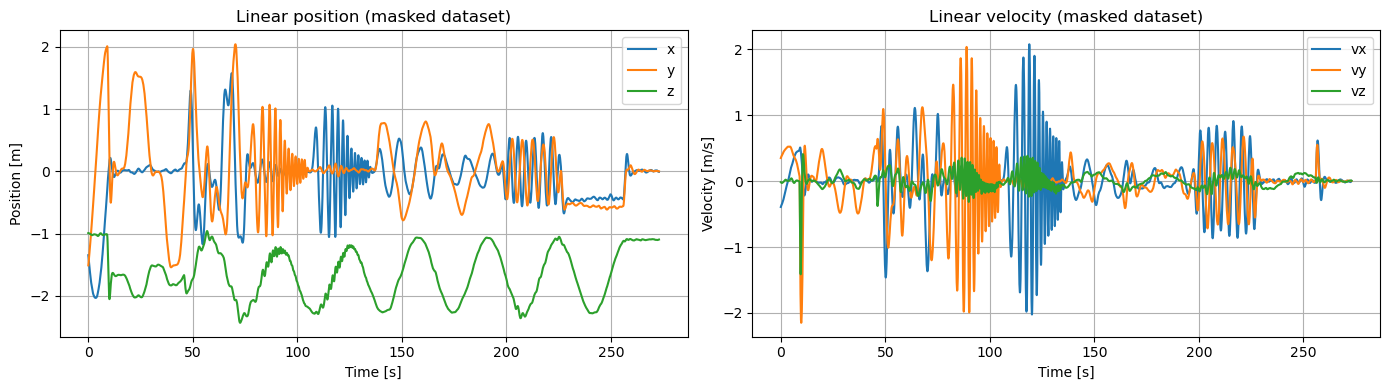

Dataset loaded from: dataset/dataset_original.csv
Total samples: 13652
Train pairs: 10799, Val pairs: 2700
Test segments: [50, 50, 50]


In [7]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use masked dataset
DATASET_PATH = os.path.join("dataset", "dataset_original.csv")
dataset_df = pd.read_csv(DATASET_PATH)
dataset_np = dataset_df.to_numpy(dtype=np.float32)

# Convert cmd thrust to actual thrust in Newtons
# dataset_np = px4_pwm_to_thrust(dataset_np)

# Global normalization statistics from masked dataset
mean, std = get_mean_and_std(dataset_np)

# Split into train/val pool and fixed test windows
dt_candidates = dataset_np[:, 1]
dt_nominal = float(np.median(dt_candidates[dt_candidates > 0])) if np.any(dt_candidates > 0) else 0.2
data_test_segments, data_train_val = split_data(dataset_np, time_period=1, dt=dt_nominal, t0=30, t1=150, t2=220)

pairs_curr, pairs_next, _ = create_and_shuffle_pairs(data_train_val)
split_idx = int(0.8 * len(pairs_curr))
split_idx = min(max(split_idx, 1), len(pairs_curr) - 1)

# Check pair alignment
print("Sanity check pair alignment:")

for i in range(3):
    print("X_curr:", pairs_curr[i][0])
    print("X_next:", pairs_next[i][0])

train_data_current, val_data_current = pairs_curr[:split_idx], pairs_curr[split_idx:]
train_data_next, val_data_next = pairs_next[:split_idx], pairs_next[split_idx:]

# Take a tiny subset (VERY IMPORTANT)
tiny_N = 128

tiny_curr = train_data_current[:tiny_N]
tiny_next = train_data_next[:tiny_N]

X_tiny, X_tiny_next, U_tiny, _, dt_tiny = configure_training_and_validation_data(
    tiny_curr, tiny_next
)

X_tiny = X_tiny[:, :12].float()
X_tiny_next = X_tiny_next[:, :12].float()
U_tiny = U_tiny.float()
dt_tiny = dt_tiny.float()

X_current_data_full, X_next_data_full, U_current_data_full, U_next_data_full, dt_full_data = configure_training_and_validation_data(pairs_curr, pairs_next)
X_train, X_train_next, U_train, U_train_next, dt_train = configure_training_and_validation_data(train_data_current, train_data_next)
X_val, X_val_next, U_val, U_val_next, dt_val = configure_training_and_validation_data(val_data_current, val_data_next)

# Keep only the 12-state used by physics/loss: [pos(3), euler(3), vel(3), ang_vel(3)]
X_train_phys = X_train[:, :12].float()
X_train_next_phys = X_train_next[:, :12].float()
X_val_phys = X_val[:, :12].float()
X_val_next_phys = X_val_next[:, :12].float()

X_current_data_full_use = X_current_data_full[:,:12].float()
X_next_data_full_use = X_next_data_full[:,:12].float()

U_train = U_train.float()
U_val = U_val.float()
dt_train = dt_train.float()
dt_val = dt_val.float()

# Quick visualization of masked data
time = dataset_np[:, 0]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(time, dataset_np[:, 2], label="x")
ax[0].plot(time, dataset_np[:, 3], label="y")
ax[0].plot(time, dataset_np[:, 4], label="z")
ax[0].set_title("Linear position (masked dataset)")
ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(time, dataset_np[:, 5], label="vx")
ax[1].plot(time, dataset_np[:, 6], label="vy")
ax[1].plot(time, dataset_np[:, 7], label="vz")
ax[1].set_title("Linear velocity (masked dataset)")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Velocity [m/s]")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Dataset loaded from: {DATASET_PATH}")
print(f"Total samples: {len(dataset_np)}")
print(f"Train pairs: {len(train_data_current)}, Val pairs: {len(val_data_current)}")
print(f"Test segments: {[seg.shape[0] for seg in data_test_segments]}")

## **Step 5: Data Loss**

In [8]:
import torch
import torch.nn as nn
# from a_System_dynamics.system_dynamics import system_dynamics

_mse_loss = nn.MSELoss()

def compute_new_pos_angles(delta_vw, X_curr, U_curr, dt, mass, inertia, g):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    # baseline physics derivative
    x_dot_phys = system_dynamics(X_curr, U_curr, mass, inertia=inertia, g=g)  # (B,12)
    
    delta_v = delta_vw[:, 0:3]  # (B,3) correction for linear velocities
    delta_w = delta_vw[:, 3:6]  # (B,3) correction for angular velocities
    
    x_next_base = X_curr + x_dot_phys * dt  # Next state
    
    v_next = x_next_base[:, 6:9] + delta_v  # New predicted next linear velocity with correction
    w_next = x_next_base[:, 9:12] + delta_w  # New predicted next angular velocity with correction

    # integrate position in world frame using trapezoid
    v_curr = X_curr[:, 6:9]
    pos_next = X_curr[:, 0:3] + 0.5 * (v_curr + v_next) * dt

    # integrate attitude using quaternion (singularity-free)
    roll  = X_curr[:, 3]
    pitch = X_curr[:, 4]
    yaw  = X_curr[:, 5]

    rpy_curr = X_curr[:,3:6]
    
    rpy_dot = x_dot_phys[:,3:6]
    w_curr = X_curr[:,9:12]
    
    #rpy_next = rpy_curr + (w_curr + w_next)*dt

    w_avg = 0.5 * (w_curr + w_next)
    
    r_dot = w_avg[:,0] + torch.sin(roll)*torch.tan(pitch)*w_avg[:,1] + torch.cos(roll)*torch.tan(pitch)*w_avg[:,2]
    p_dot = torch.cos(roll)*w_avg[:,1] - torch.sin(roll)*w_avg[:,2]
    y_dot = (torch.sin(roll)/torch.cos(pitch))*w_avg[:,1] + (torch.cos(roll)/torch.cos(pitch))*w_avg[:,2]
    
    rpy_next = X_curr[:, 3:6] + torch.stack([r_dot, p_dot, y_dot], dim=1) * dt
    
    #q0 = euler_to_quat(roll0, pitch0, yaw0)          # (B,4)
    #dq = omega_to_quat_delta(w_next, dt)             # (B,4)

    # NOTE on multiplication order:
    # This assumes w_next is expressed in the body frame. Using q_next = q0 ⊗ dq is a common convention for body-frame increment.
    #q_next = quat_mul(q0, dq)
    #q_next = quat_normalize(q_next)

    #rpy_next = quat_to_euler(q_next)                 # (B,3)
    #rpy_next = wrap_to_pi(rpy_next)

    # assemble final next state
    X_next = x_next_base.clone()
    X_next[:, 0:3] = pos_next
    X_next[:, 3:6] = rpy_next
    X_next[:, 6:9] = v_next
    X_next[:, 9:12] = w_next


    
    # 3) integrate pose using corrected velocities/angular velocities
    #roll  = X_curr[:, 3]
    #pitch = X_curr[:, 4]
    #yaw   = X_curr[:, 5]

    #vx, vy, vz = v_next[:, 0], v_next[:, 1], v_next[:, 2]
    #w_roll, w_pitch, w_yaw = w_next[:, 0], w_next[:, 1], w_next[:, 2]

    # position derivatives in world frame
    #x_dot = vx
    #y_dot = vy
    #z_dot = vz

    # Euler angle rates (same formulas you used) using corrected angular rates
    # NOTE: this has singularities at cos(pitch)=0 (pitch = +- 90 deg)
    #roll_dot  = w_roll + torch.sin(roll) * torch.tan(pitch) * w_pitch + torch.cos(roll) * torch.tan(pitch) * w_yaw
    #pitch_dot = torch.cos(roll) * w_pitch - torch.sin(roll) * w_yaw
    #yaw_dot   = (torch.sin(roll) / torch.cos(pitch)) * w_pitch + (torch.cos(roll) / torch.cos(pitch)) * w_yaw

    #pos_angles_dot = torch.stack([x_dot, y_dot, z_dot, roll_dot, pitch_dot, yaw_dot], dim=1)  # (B,6)
    #pos_angles_next = X_curr[:, 0:6] + pos_angles_dot * dt                                    # (B,6) Integrate to get new position and angles

    # Assemble final corrected next state
    #X_next = x_next_base.clone()
    #X_next[:, 0:6] = pos_angles_next
    #X_next[:, 6:9] = v_next
    #X_next[:, 9:12] = w_next

    return X_next


def data_loss(model, X_curr, U_curr_NN, X_next, dt,
              r_mean, r_std,
              mass=2.0, inertia=torch.tensor([0.0217, 0.0217, 0.04]), g=9.81,
              channel_weights=None):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    # physics baseline
    x_dot_phys = system_dynamics(X_curr, U_curr_NN, mass, inertia=inertia, g=g)   # (B,12)
    X_next_phys = X_curr + x_dot_phys * dt                                          # (B,12)

    # true residual in physical units
    r_true = X_next[:, 6:12] - X_next_phys[:, 6:12]                                 # (B,6)

    r_true_v = r_true[:, 0:3]
    r_true_w = r_true[:, 3:6]

    # normalize
    r_true_v_n = (r_true_v - r_mean[0:3]) / (r_std[0:3] + 1e-8)
    r_true_w_n = (r_true_w - r_mean[3:6]) / (r_std[3:6] + 1e-8)
    
    # combine correctly
    r_true_n = torch.cat((r_true_v_n, r_true_w_n), dim=1)   # (B,6)
    
    #r_true_n=r_true
    #print(r_true.std(dim=0))


    # Verification Check
    #if torch.rand(1) > 0.99:  # Only print occasionally so you don't slow down training
    #    print("\n--- Normalization Check ---")
    #    print(f"Mean (should be ~0): {r_true_n.mean(dim=0).cpu().detach().numpy()}")
    #    print(f"Std  (should be ~1): {r_true_n.std(dim=0).cpu().detach().numpy()}")
    
    # model predicts normalized residual
    r_pred_n = model(X_curr, U_curr_NN)                                              # (B,6)

    # balanced per-channel loss in normalized space
    per_channel_losses = torch.mean((r_pred_n - r_true_n) ** 2, dim=0)               # (6,)
    if channel_weights is None:
        cw = torch.ones(6, device=X_curr.device, dtype=X_curr.dtype)
    else:
        cw = channel_weights.to(device=X_curr.device, dtype=X_curr.dtype)

    loss_data_corr = torch.sum(cw * per_channel_losses)

    # 1. L2 penalty: Encourages 'small' corrections (prevents over-correction)
    penalty_l2 = torch.mean(r_pred_n**2)
    
    # 2. Total Variation penalty (Smoothness): Punishes jumpy predictions across the batch
    # This is key for killing jitter
    penalty_tv = torch.mean(torch.abs(r_pred_n[1:] - r_pred_n[:-1]))

    total_loss = loss_data_corr + 0.01 * penalty_l2 #+ 0.1 * penalty_tv

    # for evaluation/integration, denormalize correction
    r_pred = r_pred_n * r_std + r_mean                                                # (B,6)
    X_next_NN = compute_new_pos_angles(r_pred, X_curr, U_curr_NN, dt, mass, inertia, g)

    # --- residuals ---
    #r_true = X_next[:, 6:12] - X_next_phys[:, 6:12]
    
    # remove bias
    #r_dyn = r_true - r_mean
    
    # normalize
    #r_dyn_n = r_dyn / r_std
    
    # model predicts normalized dynamic residual
    #r_pred_dyn_n = model(X_curr, U_curr_NN)
    
    # loss
    #per_channel_losses = torch.mean((r_pred_dyn_n - r_dyn_n) ** 2, dim=0)
    
    #if channel_weights is None:
    #    cw = torch.ones(6, device=X_curr.device, dtype=X_curr.dtype)
    #else:
    #    cw = channel_weights.to(device=X_curr.device, dtype=X_curr.dtype)
    
    #loss_data_corr = torch.sum(cw * per_channel_losses)

    #total_loss = loss_data_corr

    # denormalize prediction
    #r_pred_dyn = r_pred_dyn_n * r_std
    
    # add bias back
    #r_pred = r_pred_dyn + r_mean
    
    # corrected state
    #X_next_NN = compute_new_pos_angles(
    #    r_pred, X_curr, U_curr_NN, dt, mass, inertia, g
    #)
    
    return total_loss, {
        "loss_data_corr": loss_data_corr.detach(),
        "per_channel_mse": per_channel_losses.detach(),   # add this
        "X_next_NN": X_next_NN.detach(),
        #"r_pred_dyn": r_pred_dyn.detach()
    }


In [9]:
@torch.no_grad()
def compute_checkpoint_score(
    model,
    val_segments,
    r_mean,
    r_std,
    mass,
    inertia,
    g,
    channel_weights,
    eps=1e-6,
    lambda_res=0.1
):
    w = channel_weights / channel_weights.sum()
    seg_scores = []
    per_seg_debug = []

    for seg in val_segments:
        Xc = seg["X_curr"]
        Uc = seg["U_curr"]
        Xn = seg["X_next"]
        dt = seg["dt"]

        if dt.ndim == 1:
            dt = dt.view(-1, 1)

        # --- physics rollout ---
        xdot = system_dynamics(Xc, Uc, mass=mass, inertia=inertia, g=g)
        X_phys = Xc + xdot * dt

        err_phys = X_phys[:, 6:12] - Xn[:, 6:12]
        mse_phys = (err_phys ** 2).mean(dim=0)

        # --- model rollout ---
        _, info = data_loss(
            model=model,
            X_curr=Xc,
            U_curr_NN=Uc,
            X_next=Xn,
            dt=dt,
            r_mean=r_mean,
            r_std=r_std,
            mass=mass,
            inertia=inertia,
            g=g,
            channel_weights=channel_weights,
        )

        X_model = info["X_next_NN"]
        err_model = X_model[:, 6:12] - Xn[:, 6:12]
        mse_model = (err_model ** 2).mean(dim=0)

        # --- residual structure ---
        residual_phys = (Xn[:, 6:12] - X_phys[:, 6:12])
        residual_model = (X_model[:, 6:12] - X_phys[:, 6:12])

        residual_error = ((residual_model - residual_phys) ** 2).mean(dim=0)
        
        # --- core objective: improvement over physics ---
        gain = mse_phys - mse_model
        
        # --- channel weighted score ---
        weighted_gain = w * gain
        
        # --- final score ---
        seg_score = weighted_gain.sum() - lambda_res * residual_error.mean()
        
        seg_scores.append(seg_score)

        per_seg_debug.append({
            "mse_phys": mse_phys.detach().cpu(),
            "mse_model": mse_model.detach().cpu(),
            "gain": gain.detach().cpu(),
            "residual_error": residual_error.detach().cpu(),
            "seg_score": float(seg_score.item())
        })

    return torch.stack(seg_scores).mean().item(), per_seg_debug

## **Step 6: Training and Validation**

## **Step 6-Extended: Closed-Loop Training**

Closed-loop training feeds the model's predictions back into itself, enabling it to learn how to recover from its own errors over multiple timesteps.

Linear Velocity STD: [0.4304496  0.4384467  0.12016158]
Angular Velocity STD: [0.23235749 0.22658028 0.05395425]
NN input normalization enabled for v, w, and u.
r_mean: tensor([1.3538e-04, 4.9461e-04, 1.5548e-03, 7.0853e-06, 8.7079e-07, 2.5974e-05],
       device='cuda:0')
r_std : tensor([0.0043, 0.0083, 0.0040, 0.0237, 0.0304, 0.0020], device='cuda:0')
Epoch 050/25000 | train: 8.838388 | val: 8.713514 | lr: 1.00e-04
  train ch mse [vx,vy,vz,wx,wy,wz]: [1.1726695 1.5384725 1.3953543 1.5028508 1.2656696 1.149166 ]
  val   ch mse [vx,vy,vz,wx,wy,wz]: [1.3663194  0.82015365 1.3044747  1.509592   1.0920259  2.0072408 ]
Epoch 100/25000 | train: 7.943766 | val: 7.785875 | lr: 1.00e-04
  train ch mse [vx,vy,vz,wx,wy,wz]: [1.1182048 1.4275384 1.1932108 1.4298272 1.2062068 0.9448015]
  val   ch mse [vx,vy,vz,wx,wy,wz]: [1.3113574  0.71144813 1.1043651  1.4379836  1.0384564  1.773518  ]
Epoch 150/25000 | train: 7.281712 | val: 7.097595 | lr: 1.00e-04
  train ch mse [vx,vy,vz,wx,wy,wz]: [1.075335

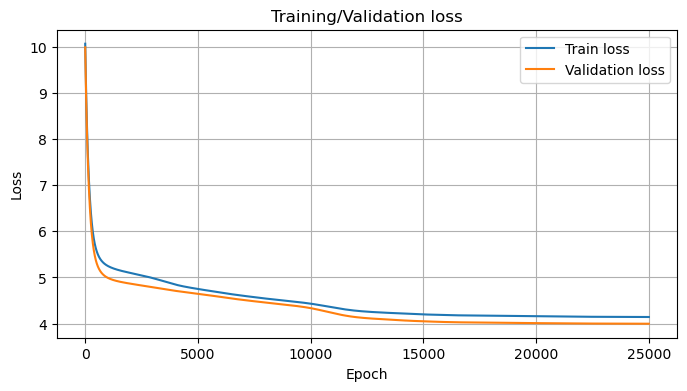

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Check for dead nodes in ReLU layers
dead_node_check = False
activation_class = nn.ELU

# ReLU, ReLU, Identity
model = ResidualBModel(
    hidden_layers_size=[32, 16],
    # activation_fn=nn.ReLU, # ReLU works but 20% of nodes are dead at the end of training in layer 3
    activation_fn=nn.ELU, # ELU works best
    # activation_fn=nn.SELU,
    output_activation=nn.Identity,
).to(device)

# Configure NN input normalization for [v, w, u] using dataset statistics from Step 4.
if 'mean' in globals() and 'std' in globals():
    model.set_input_norm_stats(mean, std)
    print('NN input normalization enabled for v, w, and u.')
else:
    print('Warning: mean/std not found. Run Step 4 before training to enable input normalization.')

#mean = torch.tensor(mean, dtype=torch.float32, device=device)
#std  = torch.tensor(std, dtype=torch.float32, device=device)


optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-2)


# Add scheduler

scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=50,
    threshold=1e-5,
    threshold_mode='abs',
    min_lr=1e-5 # Might be better with 5e-6 because of instability at ~20000-30000 epochs
)

scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max= 1500,      # decay over first ~1/3 training
    eta_min=1e-4
)

if dead_node_check == True:

    relu_stats = {}
    dead_neuron_stats = {}

    def relu_hook(name):
        def hook(module, input, output):
            if not isinstance(output, torch.Tensor):
                return

            # Fraction of near-zero activations
            zero_frac = (output < 1e-6).float().mean().item()

            # Fraction of neurons inactive across entire batch
            if output.dim() > 1:
                dead_frac = (output < 1e-6).all(dim=0).float().mean().item()
            else:
                dead_frac = 0.0

            relu_stats[name] = zero_frac
            dead_neuron_stats[name] = dead_frac

        return hook

    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, activation_class):
            hooks.append(layer.register_forward_hook(relu_hook(name)))

history_dead = {
    name: [] 
    for name, layer in model.named_modules() 
    if isinstance(layer, activation_class)
}




X_train_phys_d = X_train_phys.to(device)
X_train_next_phys_d = X_train_next_phys.to(device)
U_train_d = U_train.to(device)
dt_train_d = dt_train.to(device)

X_val_phys_d = X_val_phys.to(device)
X_val_next_phys_d = X_val_next_phys.to(device)
U_val_d = U_val.to(device)
dt_val_d = dt_val.to(device)


@torch.no_grad()
def compute_residual_stats(X_curr, U_curr, X_next, dt, mass, inertia, g, eps=1e-8):
    # 1. Identify the device of your inertia/model
    device = inertia.device 
    
    # 2. Move all inputs to that device
    X_curr = X_curr.to(device)
    U_curr = U_curr.to(device)
    X_next = X_next.to(device)
    dt     = dt.to(device)
    
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    # Now the dynamics call will work
    xdot = system_dynamics(X_curr, U_curr, mass=mass, inertia=inertia, g=g)
    X_next_phys = X_curr + xdot * dt
    r = X_next[:, 6:12] - X_next_phys[:, 6:12]
    
    # Calculate stats
    r_mean_v = r[:,0:3].mean(dim=0)
    r_std_v  = r[:,0:3].std(dim=0)
    
    r_mean_w = r[:,3:6].mean(dim=0)
    r_std_w  = r[:,3:6].std(dim=0)

    r_mean = torch.cat((r_mean_v, r_mean_w), dim=0)
    r_std  = torch.cat((r_std_v, r_std_w), dim=0)
    
    return r_mean, r_std

# 1) define constants used by physics
mass = 2.0
inertia = torch.tensor([0.0217, 0.0217, 0.04], device=device, dtype=X_train_phys_d.dtype)
g = 9.81

r_mean, r_std = compute_residual_stats(
    X_current_data_full_use, U_current_data_full, X_next_data_full_use, dt_full_data,
    mass=mass, inertia=inertia, g=g
)
print("r_mean:", r_mean)
print("r_std :", r_std)

# [vx, vy, vz, wx, wy, wz]
channel_weights = torch.tensor(
    [1.4, 2.0, 1.4, 0.2, 0.2, 1.4],
    device=device,
    dtype=X_train_phys_d.dtype
)

#channel_weights = 1.0 / (r_std ** 2 + 1e-8)
#channel_weights = channel_weights / channel_weights.mean()

# channel_weights = torch.ones(12, device=device)
num_epochs = 25000

train_losses = []
val_losses = []

best_score = -float("inf")
best_state = None
best_epoch = -1
epochs_no_improve = 0
min_delta = 1e-6
patience = 1500


segments_for_ckpt = [
    {"X_curr": X_val_phys_d, "U_curr": U_val_d, "X_next": X_val_next_phys_d, "dt": dt_val_d},
]

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    train_loss, train_info = data_loss(
        model=model,
        X_curr=X_train_phys_d,
        U_curr_NN=U_train_d,
        X_next=X_train_next_phys_d,
        dt=dt_train_d,
        r_mean=r_mean,
        r_std=r_std,
        mass=mass,
        inertia=inertia,
        g=g,
        channel_weights=channel_weights,
    )
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss, val_info = data_loss(
            model=model,
            X_curr=X_val_phys_d,
            U_curr_NN=U_val_d,
            X_next=X_val_next_phys_d,
            dt=dt_val_d,
            r_mean=r_mean,
            r_std=r_std,
            mass=mass,
            inertia=inertia,
            g=g,
            channel_weights=channel_weights,
        )

    if optimizer.param_groups[0]['lr'] > 1e-4:
        scheduler_cosine.step()
    else:
        scheduler_plateau.step(val_loss)  # adaptive decay after LR floor

    train_losses.append(float(train_loss.item()))
    val_losses.append(float(val_loss.item()))

    val_score, val_debug = compute_checkpoint_score(
        model=model,
        val_segments=segments_for_ckpt,
        r_mean=r_mean,
        r_std=r_std,
        mass=mass,
        inertia=inertia,
        g=g,
        channel_weights=channel_weights,
    )


   # --- checkpoint logic ---
    if val_score > best_score + min_delta:
        best_score = val_score
        best_epoch = epoch
        epochs_no_improve = 0
    
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
    
    else:
        epochs_no_improve += 1


    
    
    if (epoch + 1) % 50 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d}/{num_epochs} | train: {train_losses[-1]:.6f} | val: {val_losses[-1]:.6f} | lr: {lr:.2e}")
        tr_ch = train_info["per_channel_mse"].cpu().numpy()
        va_ch = val_info["per_channel_mse"].cpu().numpy()
        print("  train ch mse [vx,vy,vz,wx,wy,wz]:", np.round(tr_ch, 8))
        print("  val   ch mse [vx,vy,vz,wx,wy,wz]:", np.round(va_ch, 8))

    # --- early stopping ---
    #if epochs_no_improve >= patience:
    #    print(f"Early stopping at epoch {epoch}")
    #    break
        

# restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded best by custom score at epoch {best_epoch+1}, score={best_score:.6f}")

    if dead_node_check == True:
        if (epoch + 1) % 100 == 0:
            print("ReLU zero fractions:")
            for name, frac in relu_stats.items():
                print(f"  {name}: {frac:.3f}")
            for name in dead_neuron_stats:
                if name not in history_dead:
                    history_dead[name] = []
                history_dead[name].append(dead_neuron_stats[name])

print("Training complete.")


if dead_node_check == True:
    for h in hooks:
        h.remove()

    print("\nFinal dead neuron averages:")
    for name, values in history_dead.items():
        avg = sum(values) / len(values)
        print(f"{name}: {avg:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training/Validation loss")
plt.grid(True)
plt.legend()
plt.show()

trained_model = model

In [11]:
#print("Mean of predicted dynamic residual (should be ~0):")
#print(val_info["r_pred_dyn"].mean(dim=0))

In [12]:
# 1) verify forward output stats
with torch.no_grad():
    out_tr = model(X_train_phys_d[:2048], U_train_d[:2048])
    out_va = model(X_val_phys_d[:2048], U_val_d[:2048])
print("pred_n train mean/std:", out_tr.mean(0), out_tr.std(0))
print("pred_n val   mean/std:", out_va.mean(0), out_va.std(0))

# 2) verify normalized target stats
with torch.no_grad():
    def norm_target(Xc, Uc, Xn, dt):
        if dt.ndim == 1: dt = dt.view(-1,1)
        xdot = system_dynamics(Xc, Uc, mass=mass, inertia=inertia, g=g)
        Xp = Xc + xdot * dt
        r = Xn[:,6:12] - Xp[:,6:12]
        rn = (r - r_mean)/r_std
        return rn
    rn_tr = norm_target(X_train_phys_d[:4096], U_train_d[:4096], X_train_next_phys_d[:4096], dt_train_d[:4096])
    rn_va = norm_target(X_val_phys_d[:4096], U_val_d[:4096], X_val_next_phys_d[:4096], dt_val_d[:4096])

print("r_n train mean/std:", rn_tr.mean(0), rn_tr.std(0))
print("r_n val   mean/std:", rn_va.mean(0), rn_va.std(0))
print("finite check:", torch.isfinite(rn_tr).all().item(), torch.isfinite(rn_va).all().item())

pred_n train mean/std: tensor([-0.0049, -0.0081, -0.0302, -0.0093, -0.0230,  0.0207], device='cuda:0') tensor([0.4412, 0.2343, 0.9699, 0.6510, 0.6012, 0.6236], device='cuda:0')
pred_n val   mean/std: tensor([-0.0115,  0.0035,  0.0112, -0.0199,  0.0068, -0.0140], device='cuda:0') tensor([0.4154, 0.2260, 0.8705, 0.6479, 0.6011, 0.6486], device='cuda:0')
r_n train mean/std: tensor([ 0.0045, -0.0071, -0.0085, -0.0192,  0.0047,  0.0176], device='cuda:0') tensor([0.9476, 0.4808, 1.0270, 1.0094, 1.0679, 0.9510], device='cuda:0')
r_n val   mean/std: tensor([ 0.0091, -0.0054, -0.0112,  0.0119, -0.0141, -0.0392], device='cuda:0') tensor([1.0660, 0.6733, 0.9753, 0.9915, 0.9463, 1.2819], device='cuda:0')
finite check: True True


## **Step 7: Testing**

**7a: One-step**

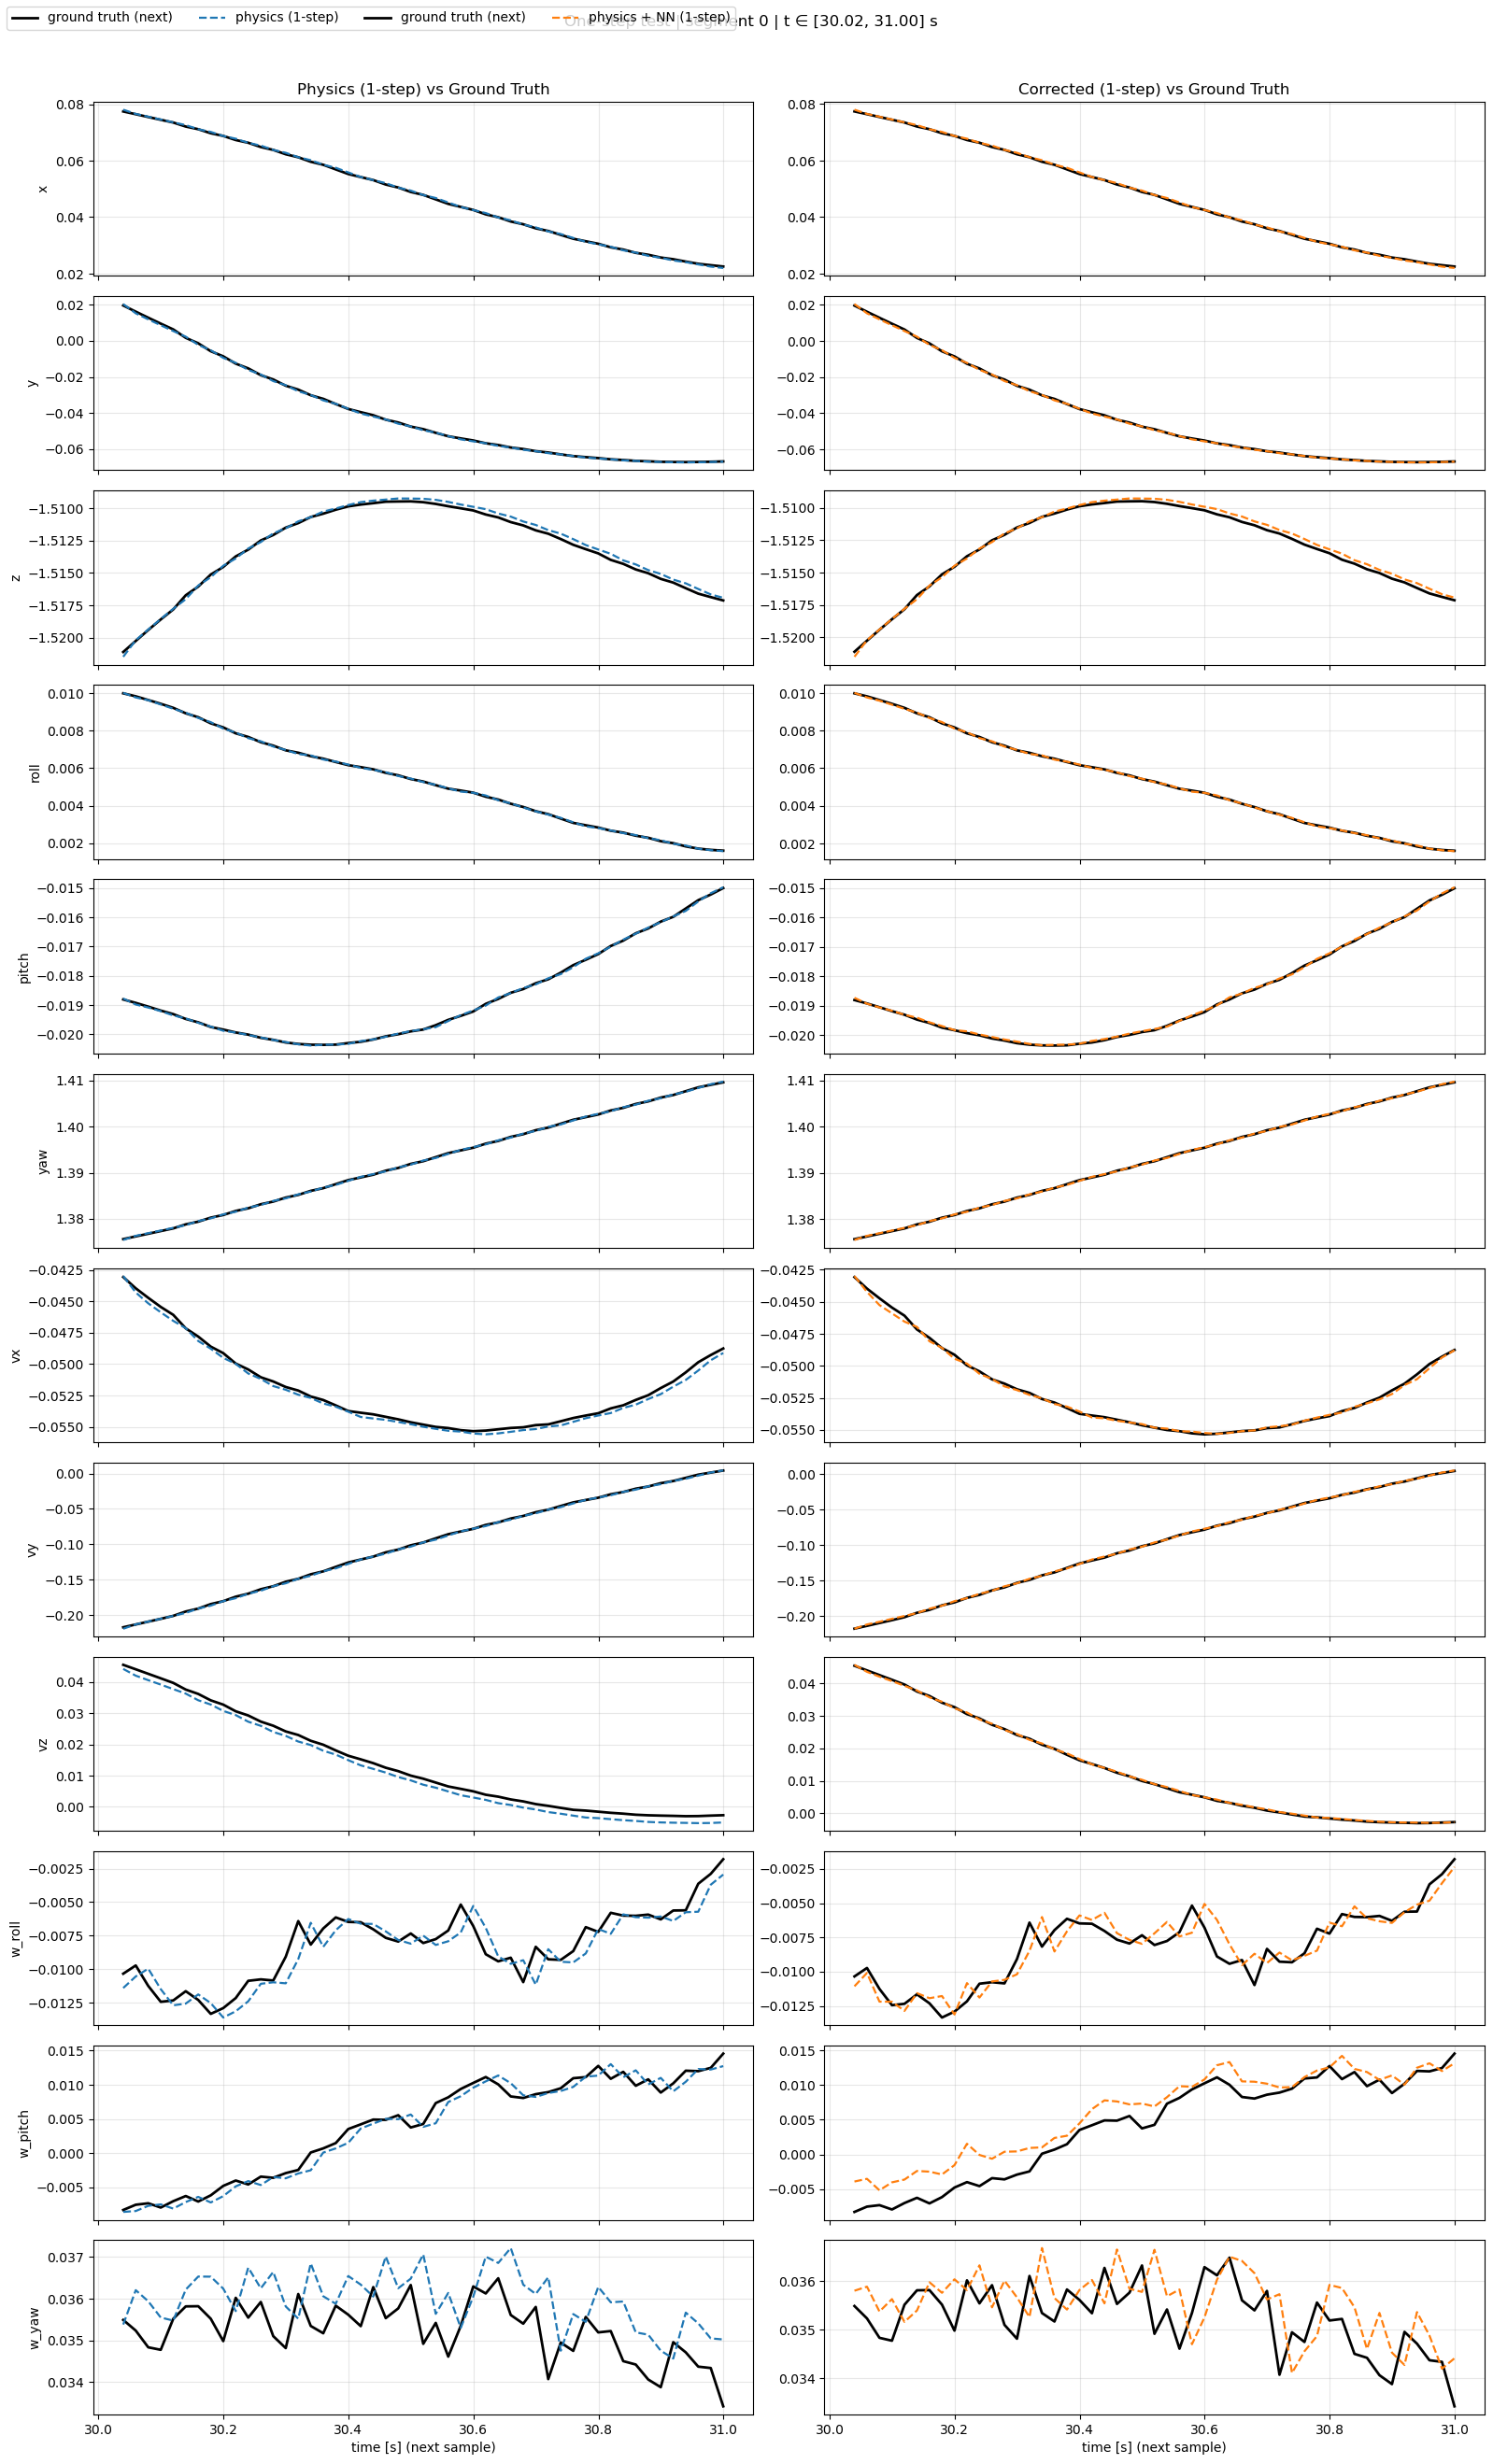

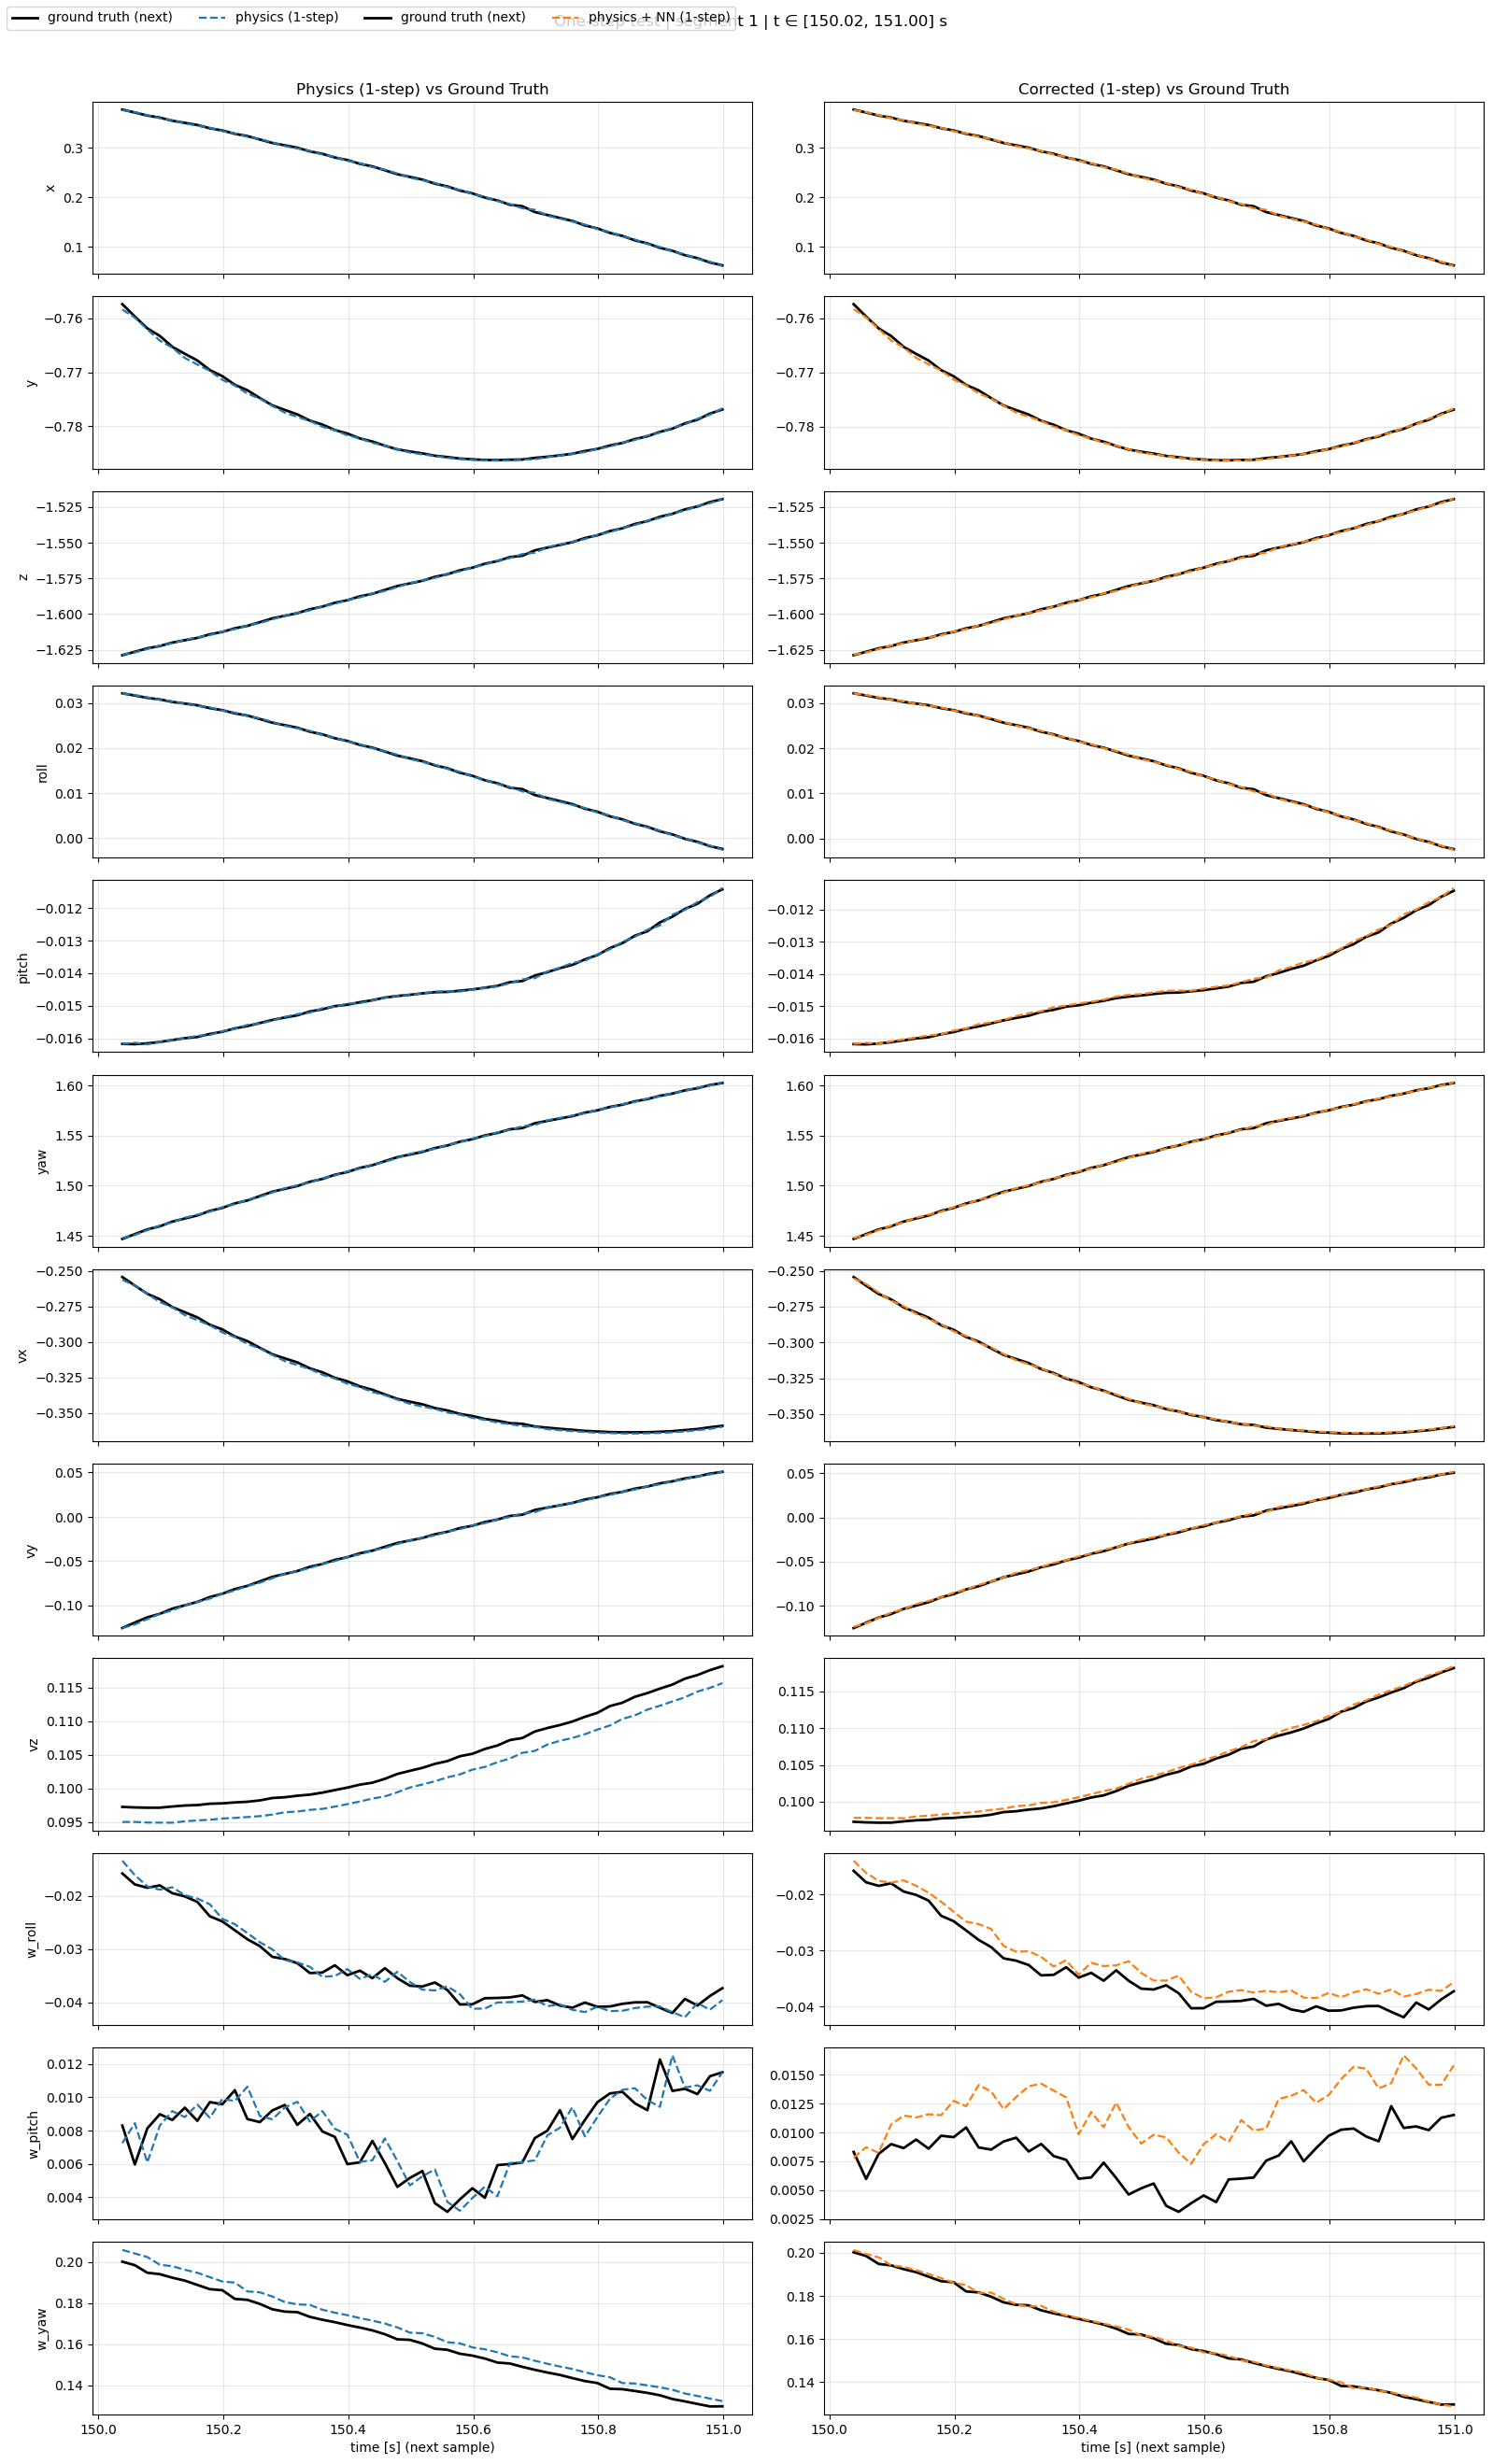

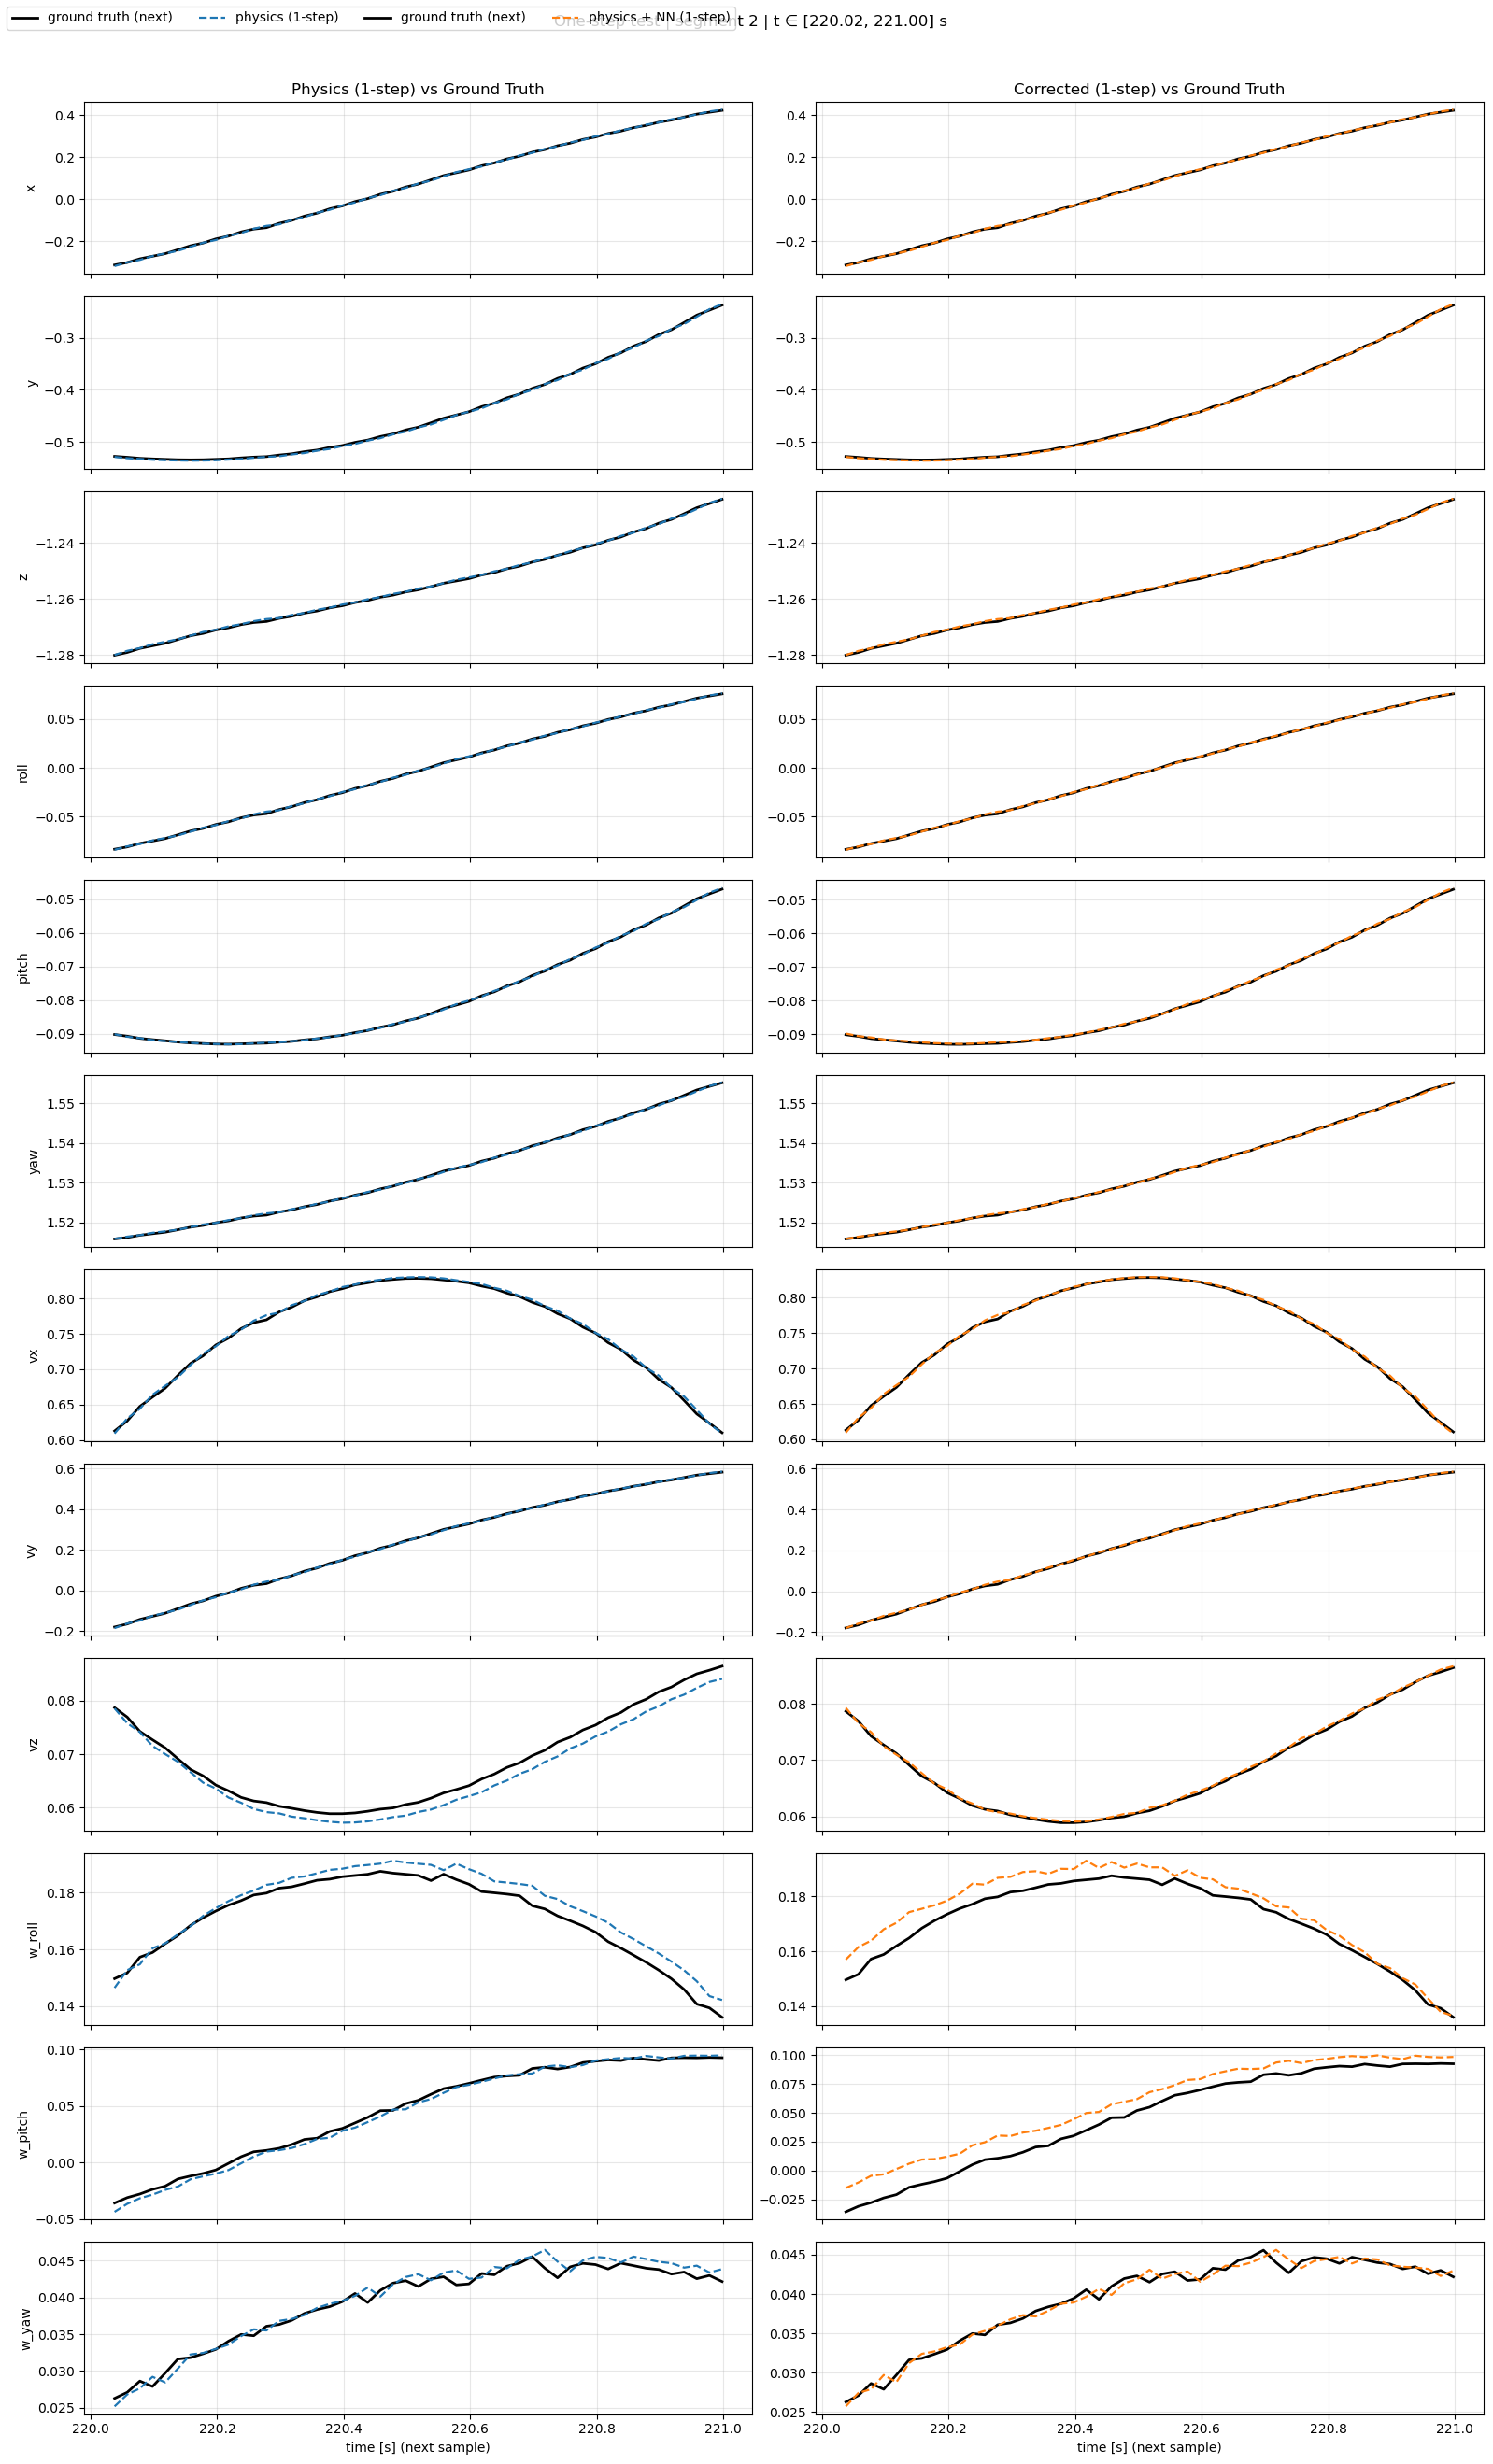

In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt

STATE_NAMES = ["x","y","z","roll","pitch","yaw","vx","vy","vz","w_roll","w_pitch","w_yaw"]

@torch.no_grad()
def one_step_predictions(model, X_curr, U_curr, dt_curr, mass, inertia, g):
    """
    X_curr: (N-1,12)
    U_curr: (N-1,4)
    dt_curr: (N-1,1) or (N-1,)
    returns:
      X_next_phys: (N-1,12)
      X_next_corr: (N-1,12)
    """
    if dt_curr.ndim == 1:
        dt_curr = dt_curr.view(-1, 1)

    # physics-only
    xdot = system_dynamics(X_curr, U_curr, mass=mass, inertia=inertia, g=g)  # (N-1,12)
    X_next_phys = X_curr + xdot * dt_curr

    # corrected
    delta_vw_n = model(X_curr, U_curr)
    delta_vw = delta_vw_n * r_std + r_mean
    X_next_corr = compute_new_pos_angles(delta_vw, X_curr, U_curr, dt_curr, mass, inertia, g)

    return X_next_phys, X_next_corr

def plot_two_column_next_state(t_next, X_next_gt, X_next_phys, X_next_corr, title):
    """
    t_next: (N-1,)
    X_next_*: (N-1,12)
    """
    n_states = 12
    fig, axes = plt.subplots(n_states, 2, figsize=(16, 2.2 * n_states), sharex=True)

    for i in range(n_states):
        axL = axes[i, 0]
        axL.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth (next)")
        axL.plot(t_next, X_next_phys[:, i], "C0--", lw=1.6, label="physics (1-step)")
        axL.set_ylabel(STATE_NAMES[i])
        axL.grid(True, alpha=0.3)
        if i == 0:
            axL.set_title("Physics (1-step) vs Ground Truth")
        if i == n_states - 1:
            axL.set_xlabel("time [s] (next sample)")

        axR = axes[i, 1]
        axR.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth (next)")
        axR.plot(t_next, X_next_corr[:, i], "C1--", lw=1.6, label="physics + NN (1-step)")
        axR.grid(True, alpha=0.3)
        if i == 0:
            axR.set_title("Corrected (1-step) vs Ground Truth")
        if i == n_states - 1:
            axR.set_xlabel("time [s] (next sample)")

    handlesL, labelsL = axes[0, 0].get_legend_handles_labels()
    handlesR, labelsR = axes[0, 1].get_legend_handles_labels()
    fig.legend(handlesL + handlesR, labelsL + labelsR, loc="upper left", ncol=4, frameon=True)

    fig.suptitle(title, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

# ---------- run on your test segments ----------
mass = 2.0
inertia = torch.tensor([0.0217, 0.0217, 0.04], dtype=torch.float32, device=device)
g = 9.81

model = trained_model.to(device)
model.eval()

for seg_i, seg in enumerate(data_test_segments):
    # seg: (N, dataset_cols)
    states_np, controls_np, dt_np = configure_data(seg)  # states_np: (N,18), controls_np: (N,4), dt_np: (N,1)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)  # (N,12)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)        # (N,4)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device) # (N,)

    # Build 1-step pairs inside the segment
    X_curr = X[:-1, :]
    X_next_gt = X[1:, :]

    U_curr = U[:-1, :]

    # dt that takes you from curr -> next (dt[0] is often 0 due to diff; so use dt[1:])
    dt_curr = dt[:-1]  # length N-1

    # time axis: next sample times
    t_next = seg[1:, 0]

    X_next_phys, X_next_corr = one_step_predictions(
        model=model,
        X_curr=X_curr,
        U_curr=U_curr,
        dt_curr=dt_curr,
        mass=mass,
        inertia=inertia,
        g=g
    )

    plot_two_column_next_state(
        t_next=t_next,
        X_next_gt=X_next_gt.detach().cpu().numpy(),
        X_next_phys=X_next_phys.detach().cpu().numpy(),
        X_next_corr=X_next_corr.detach().cpu().numpy(),
        title=f"One-step test | segment {seg_i} | t ∈ [{float(seg[0,0]):.2f}, {float(seg[-1,0]):.2f}] s"
    )

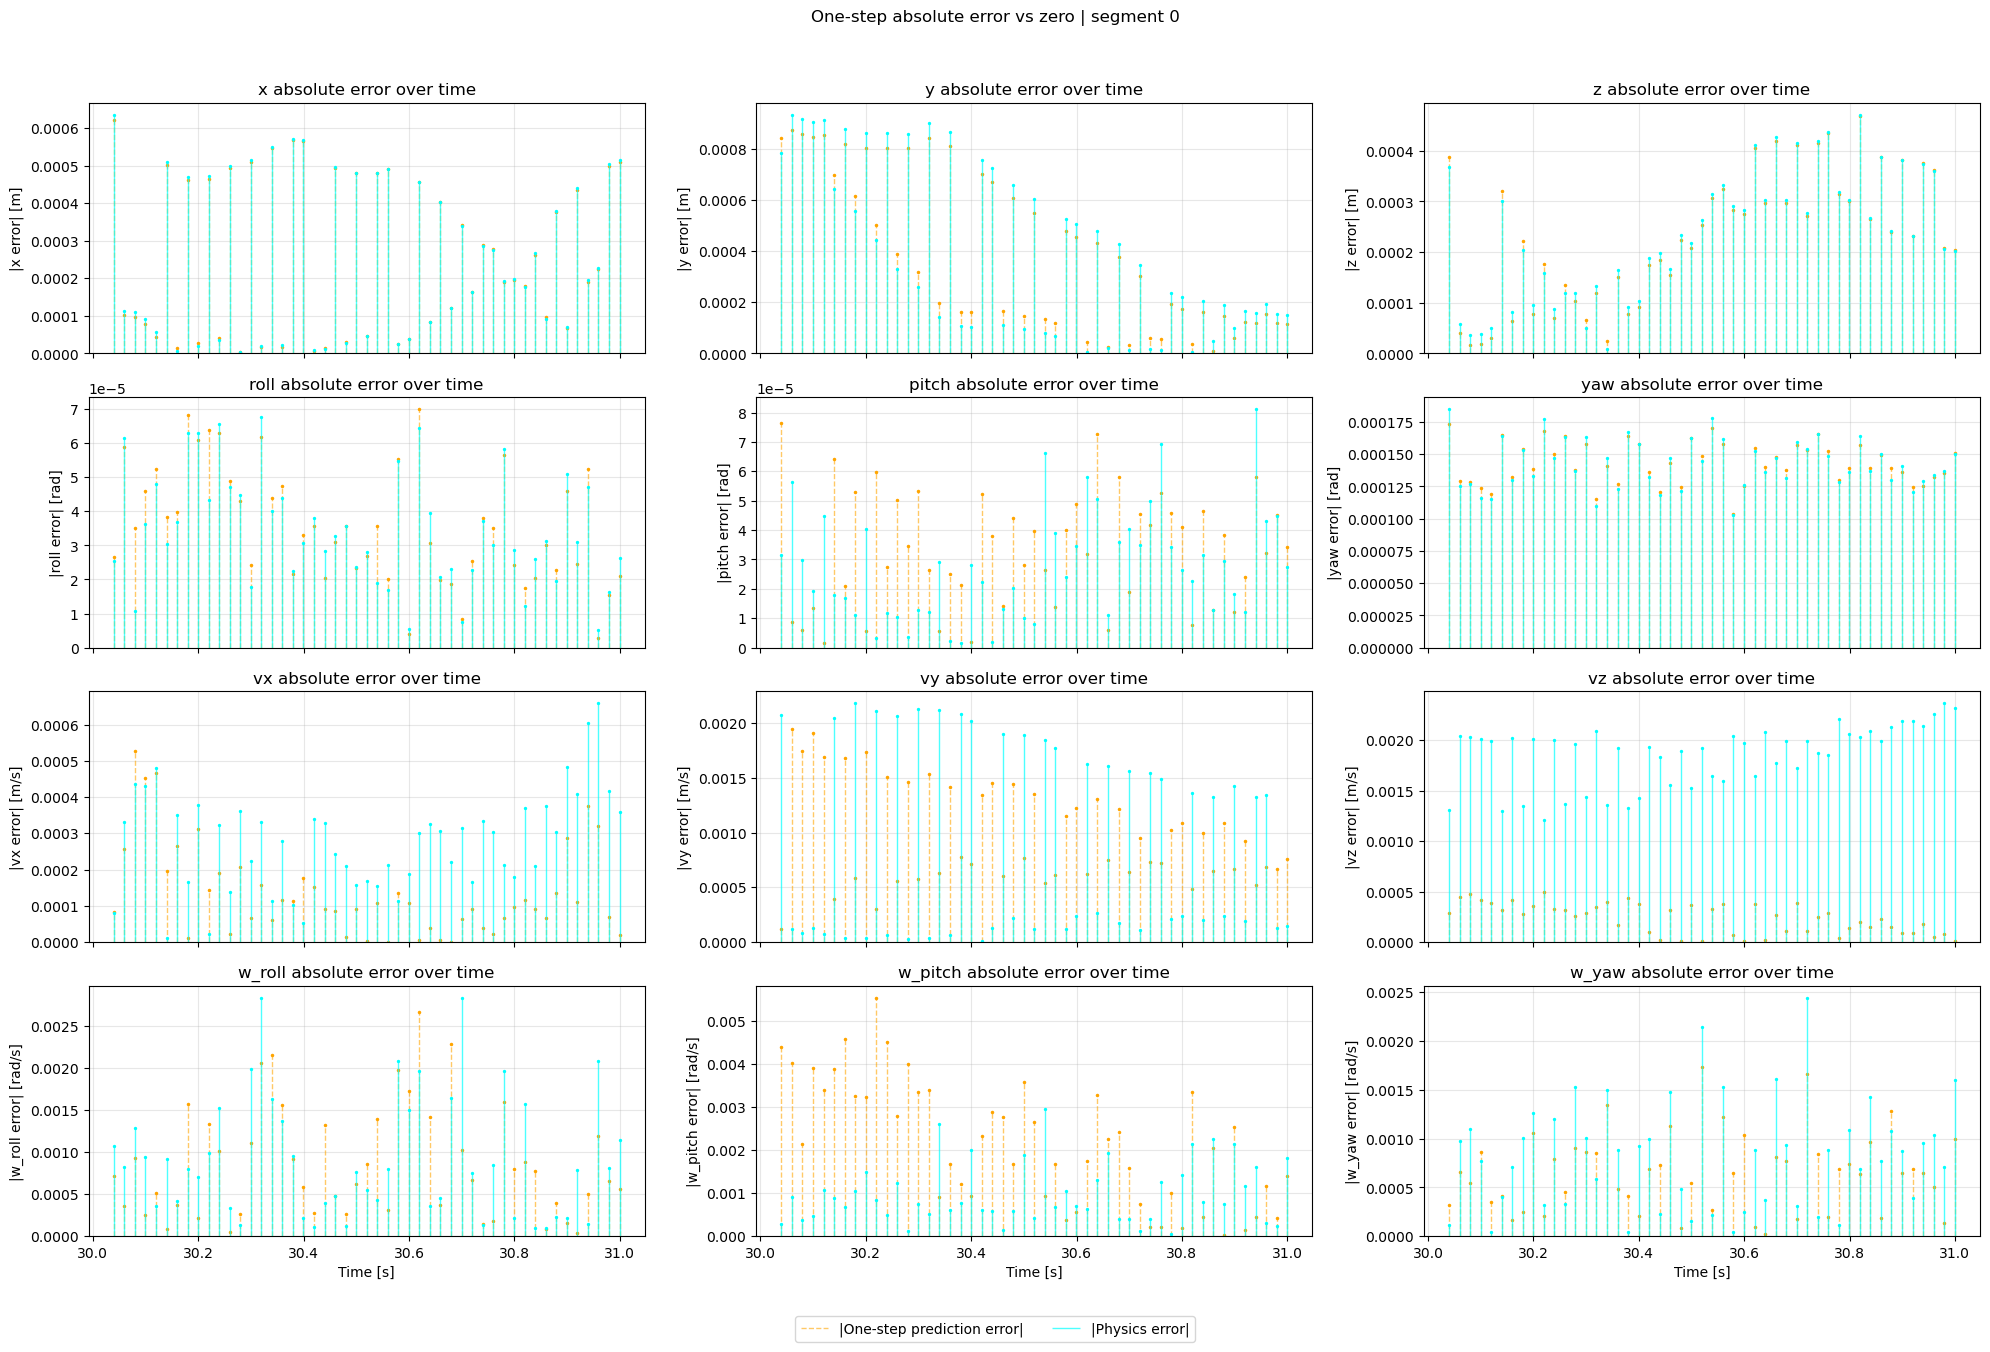

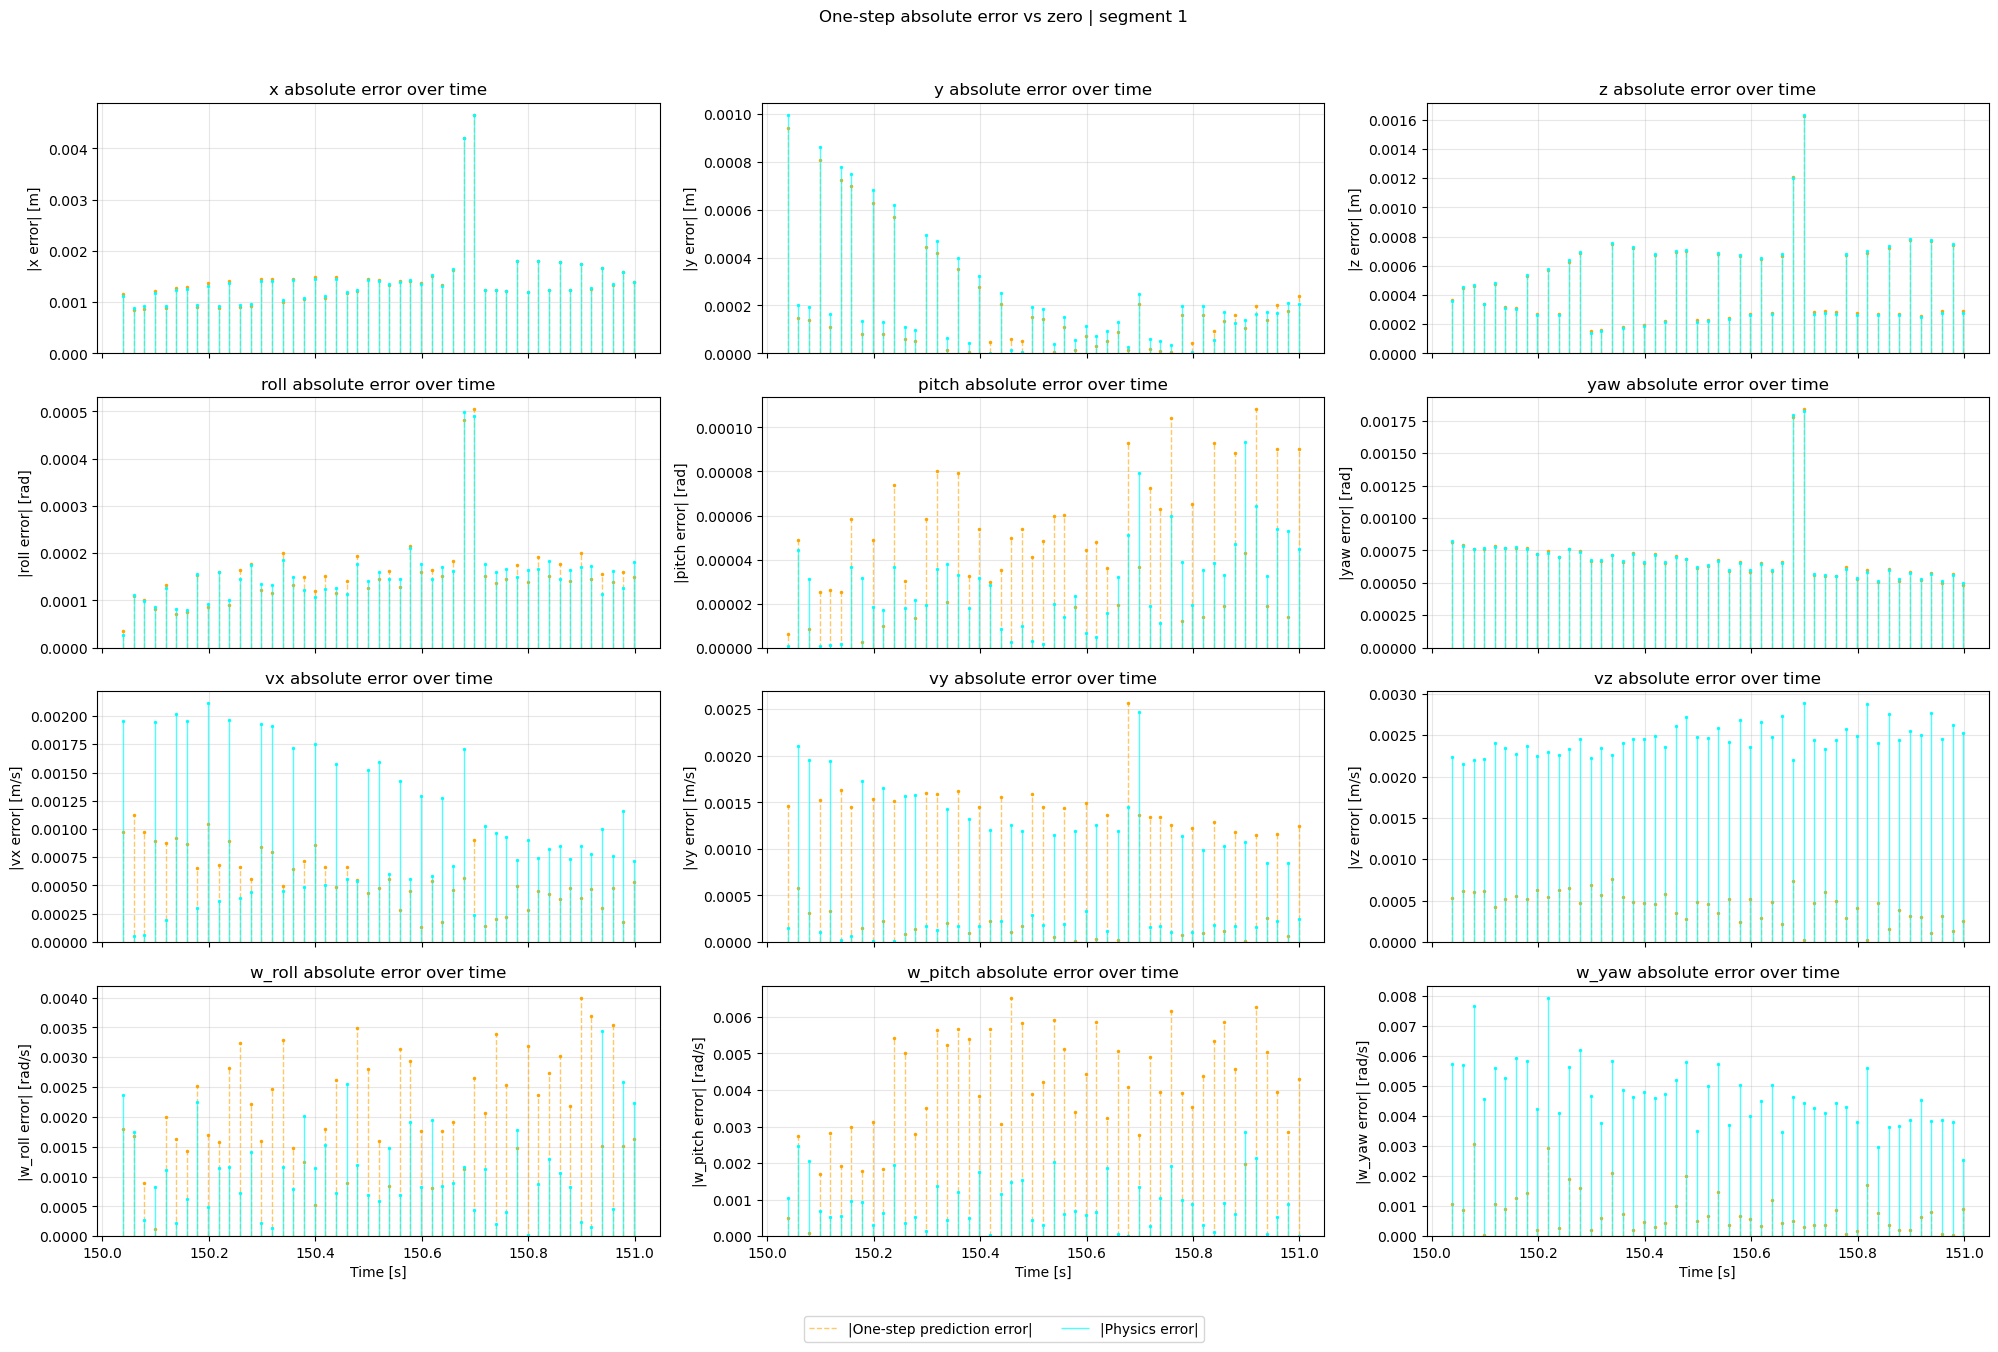

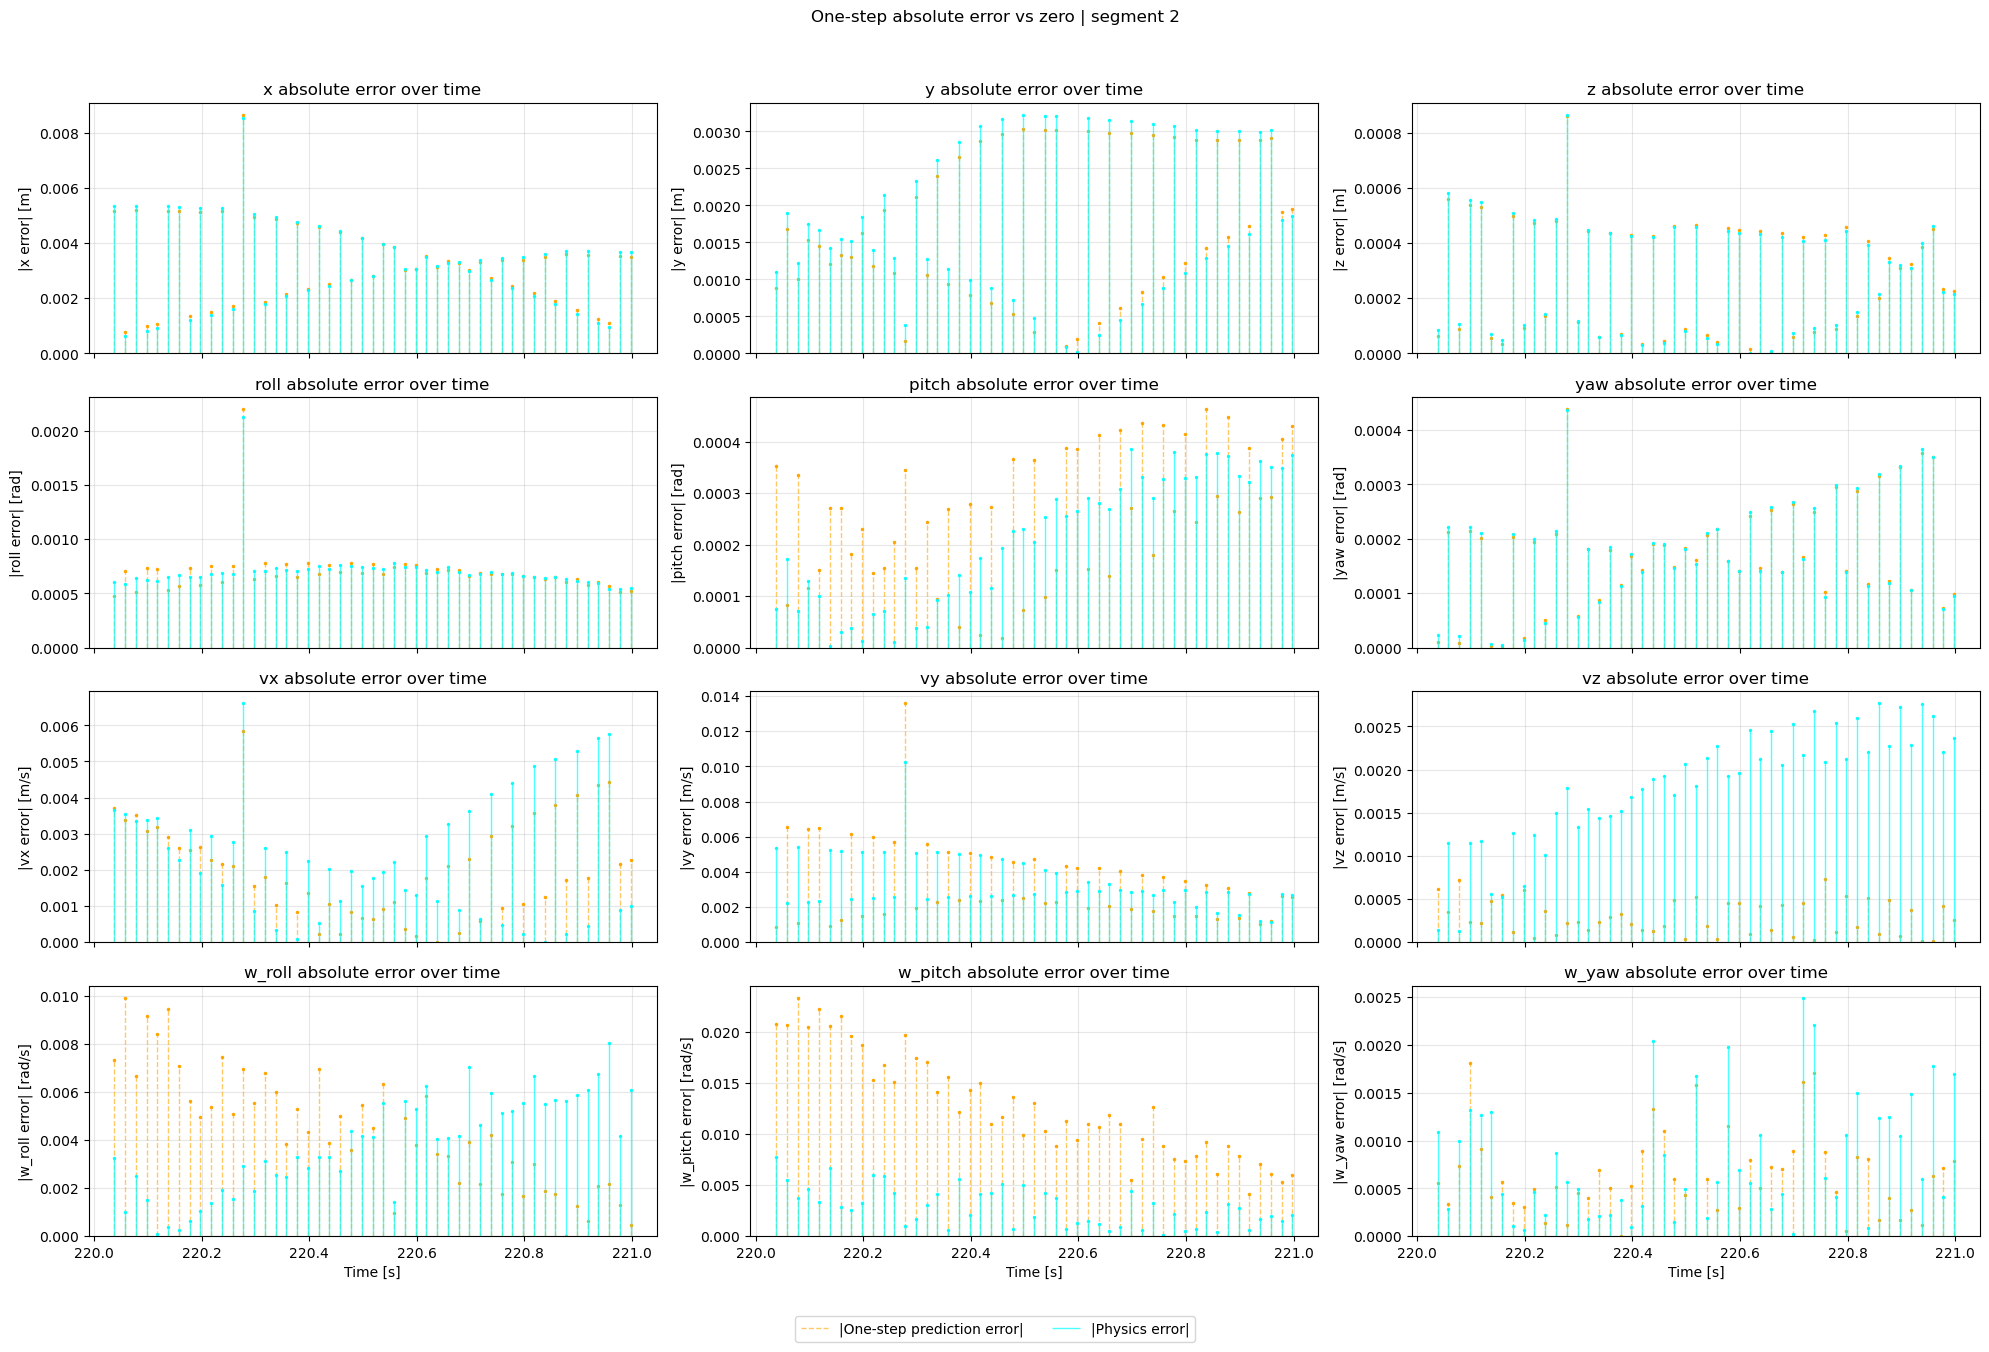

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt

STATE_NAMES = ["x", "y", "z", "roll", "pitch", "yaw", "vx", "vy", "vz", "w_roll", "w_pitch", "w_yaw"]
STATE_UNITS = ["m", "m", "m", "rad", "rad", "rad", "m/s", "m/s", "m/s", "rad/s", "rad/s", "rad/s"]

def plot_abs_errors_all_states(t_next, abs_err_phys, abs_err_one_step, title):
    """
    t_next:           (N-1,)
    abs_err_phys:     (N-1, 12)  absolute physics error
    abs_err_one_step: (N-1, 12)  absolute one-step prediction error
    """
    n_states = 12
    ncols = 3
    nrows = int(np.ceil(n_states / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, 3.4 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for i in range(n_states):
        ax = axes[i]

        # One-step absolute error (orange)
        ax.vlines(
            t_next, 0.0, abs_err_one_step[:, i],
            colors="orange", linestyles="--", lw=1.0, alpha=0.60,
            label="|One-step prediction error|" if i == 0 else None
        )
        ax.plot(t_next, abs_err_one_step[:, i], ".", color="orange", ms=3)

        # Physics absolute error (cyan)
        ax.vlines(
            t_next, 0.0, abs_err_phys[:, i],
            colors="cyan", linestyles="-", lw=1.0, alpha=0.70,
            label="|Physics error|" if i == 0 else None
        )
        ax.plot(t_next, abs_err_phys[:, i], ".", color="cyan", ms=2.8)

        ax.set_title(f"{STATE_NAMES[i]} absolute error over time")
        ax.set_ylabel(f"|{STATE_NAMES[i]} error| [{STATE_UNITS[i]}]")
        ax.set_ylim(bottom=0.0)   # positive axis only
        ax.grid(True, alpha=0.3)

    # Hide extra subplot slots
    for i in range(n_states, len(axes)):
        axes[i].axis("off")

    # X label only on bottom row
    start_bottom = (nrows - 1) * ncols
    for i in range(start_bottom, min(start_bottom + ncols, len(axes))):
        if axes[i].has_data():
            axes[i].set_xlabel("Time [s]")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=True, bbox_to_anchor=(0.5, 0.01))

    fig.suptitle(title, y=0.995)
    plt.tight_layout(rect=[0, 0.05, 1, 0.975])
    plt.show()


# ---- one-step absolute error plots for all states ----
for seg_i, seg in enumerate(data_test_segments):
    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device)

    X_curr = X[:-1, :]
    X_next_gt = X[1:, :]
    U_curr = U[:-1, :]
    dt_curr = dt[1:]    # current -> next
    t_next = seg[1:, 0] # time aligned with next sample

    with torch.no_grad():
        X_next_phys, X_next_corr = one_step_predictions(
            model=trained_model,
            X_curr=X_curr,
            U_curr=U_curr,
            dt_curr=dt_curr,
            mass=mass,
            inertia=inertia,
            g=g,
        )

    # Compute absolute errors ONCE
    abs_err_phys = torch.abs(X_next_phys - X_next_gt).detach().cpu().numpy()
    abs_err_one_step = torch.abs(X_next_corr - X_next_gt).detach().cpu().numpy()

    plot_abs_errors_all_states(
        t_next=t_next,
        abs_err_phys=abs_err_phys,
        abs_err_one_step=abs_err_one_step,
        title=f"One-step absolute error vs zero | segment {seg_i}",
    )

## **Step 8: Plot Multi-step**

In [15]:
@torch.no_grad()
def rollout_multistep_all(model, X_true, U_true, dt_true,
                           mass=2.0, inertia=torch.tensor([0.0217, 0.0217, 0.04]), g=9.81,
                           horizon_sec=3.0):
    device = next(model.parameters()).device
    X_true = X_true.to(device)
    U_true = U_true.to(device)
    dt_true = dt_true.to(device).view(-1)

    cum = torch.cumsum(dt_true, dim=0)
    K = int((cum <= horizon_sec).sum().item())
    K = max(1, min(K, X_true.shape[0] - 1))

    xk = X_true[0:1]  # (1,12)
    X_pred = [xk.squeeze(0)]
    X_ref  = [X_true[0]]

    for k in range(K-1):
        uk = U_true[k+1:k+2]         # (1,4)
        dt = dt_true[k].view(1, 1) # (1,1)

        xk = rollout_step_residual6(model, xk, uk, dt, r_mean, r_std, mass=mass, inertia=inertia, g=g)

        X_pred.append(xk.squeeze(0))
        X_ref.append(X_true[k+1])

    return torch.stack(X_pred, dim=0), torch.stack(X_ref, dim=0)

import torch

@torch.no_grad()
def rollout_step_residual6(model, xk, uk, dt,
                           r_mean, r_std,
                           mass=2.0,
                           inertia=torch.tensor([0.0217, 0.0217, 0.04]),
                           g=9.81):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    # model output is normalized residual
    delta_vw_n = model(xk, uk)                   # (B,6)
    delta_vw = delta_vw_n * r_std + r_mean       # (B,6) physical units

    x_next = compute_new_pos_angles(delta_vw, xk, uk, dt, mass, inertia, g)
    return x_next



@torch.no_grad()
def predict_onestep_over_segment(model, X_curr, U_curr, dt_curr, mass, inertia, g):
    if dt_curr.ndim == 1:
        dt_curr = dt_curr.view(-1, 1)
    return rollout_step_residual6(model, X_curr, U_curr, dt_curr, r_mean, r_std, mass=mass, inertia=inertia, g=g)

@torch.no_grad()

def rollout_multistep_over_segment(model, X0, U, dt, mass, inertia, g):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    xk = X0
    preds = []
    for k in range(U.shape[0]):
        xk = rollout_step_residual6(model, xk, U[k:k+1], dt[k:k+1], r_mean, r_std, mass=mass, inertia=inertia, g=g)
        preds.append(xk)
    return torch.cat(preds, dim=0)



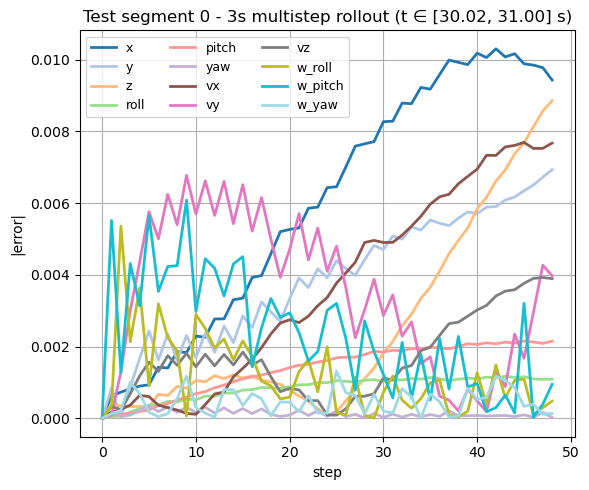

RMSE per channel:
      x: 0.006876
      y: 0.004269
      z: 0.003652
   roll: 0.000899
  pitch: 0.001543
    yaw: 0.000158
     vx: 0.004528
     vy: 0.004062
     vz: 0.002011
 w_roll: 0.001592
w_pitch: 0.002830
  w_yaw: 0.000574


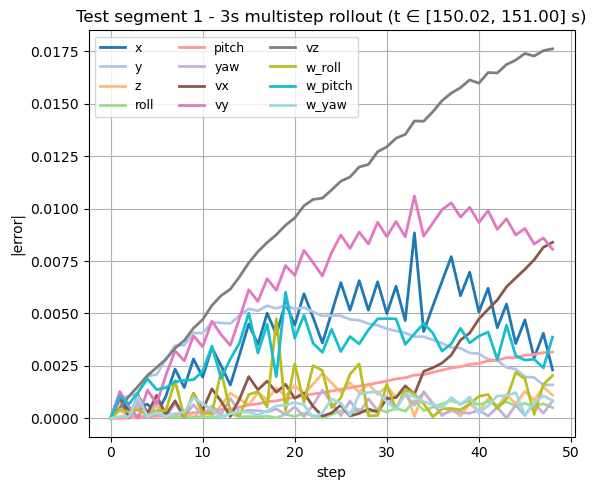

RMSE per channel:
      x: 0.004575
      y: 0.003858
      z: 0.001013
   roll: 0.000423
  pitch: 0.001732
    yaw: 0.000590
     vx: 0.003190
     vy: 0.007306
     vz: 0.011560
 w_roll: 0.001382
w_pitch: 0.003453
  w_yaw: 0.000707


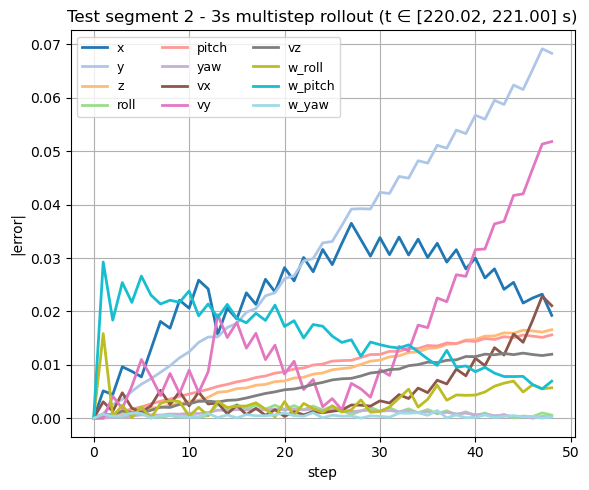

RMSE per channel:
      x: 0.025253
      y: 0.038571
      z: 0.010096
   roll: 0.001367
  pitch: 0.010499
    yaw: 0.001126
     vx: 0.007593
     vy: 0.021064
     vz: 0.007752
 w_roll: 0.004106
w_pitch: 0.016570
  w_yaw: 0.000573


In [16]:
import matplotlib.pyplot as plt
import torch

def plot_rollout_error(X_pred, X_ref, dt=None, title="1s multistep rollout error"):

    err = (X_pred - X_ref).detach().cpu()  # (K+1,12)

    channel_names = [
        "x", "y", "z",
        "roll", "pitch", "yaw",
        "vx", "vy", "vz",
        "w_roll", "w_pitch", "w_yaw",
    ]

    # x-axis
    if dt is None:
        t = torch.arange(err.shape[0])
        xlab = "step"
    else:
        dt = torch.as_tensor(dt).detach().cpu().view(-1)
        # If dt is length K (transitions), build K+1 timestamps
        if dt.numel() == err.shape[0] - 1:
            t = torch.cat([torch.zeros(1), torch.cumsum(dt, dim=0)])
        else:
            t = torch.cumsum(dt[:err.shape[0]], dim=0)
        xlab = "time [s]"


    colors = plt.cm.tab20(np.linspace(0, 1, err.shape[1]))
    
    plt.figure(figsize=(6, 5))
    for i in range(err.shape[1]):
        plt.plot(t.numpy(), err[:, i].abs().numpy(), label=channel_names[i], color=colors[i], linewidth=2)

    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel("|error|")
    plt.grid(True)
    plt.legend(ncol=3, fontsize=9)  # adjust columns/font as you like
    plt.tight_layout()
    plt.show()

    rmse = torch.sqrt(torch.mean(err**2, dim=0))
    print("RMSE per channel:")
    for name, val in zip(channel_names, rmse.numpy()):
        print(f"{name:>7s}: {val:.6f}")

for seg_i, seg in enumerate(data_test_segments):
    states, controls, dt_seg = configure_data(seg)

    X_true = torch.tensor(states[:, :12], dtype=torch.float32, device=device)
    U_true = torch.tensor(controls, dtype=torch.float32, device=device)
    dt_true = torch.tensor(dt_seg.squeeze(), dtype=torch.float32, device=device)

    # Your existing function (whatever it returns)
    X_pred, X_ref = rollout_multistep_all(model, X_true, U_true, dt_true)

    plot_rollout_error(
        X_pred, X_ref,
        title=f"Test segment {seg_i} - 3s multistep rollout (t ∈ [{float(seg[0,0]):.2f}, {float(seg[-1,0]):.2f}] s)"
    )

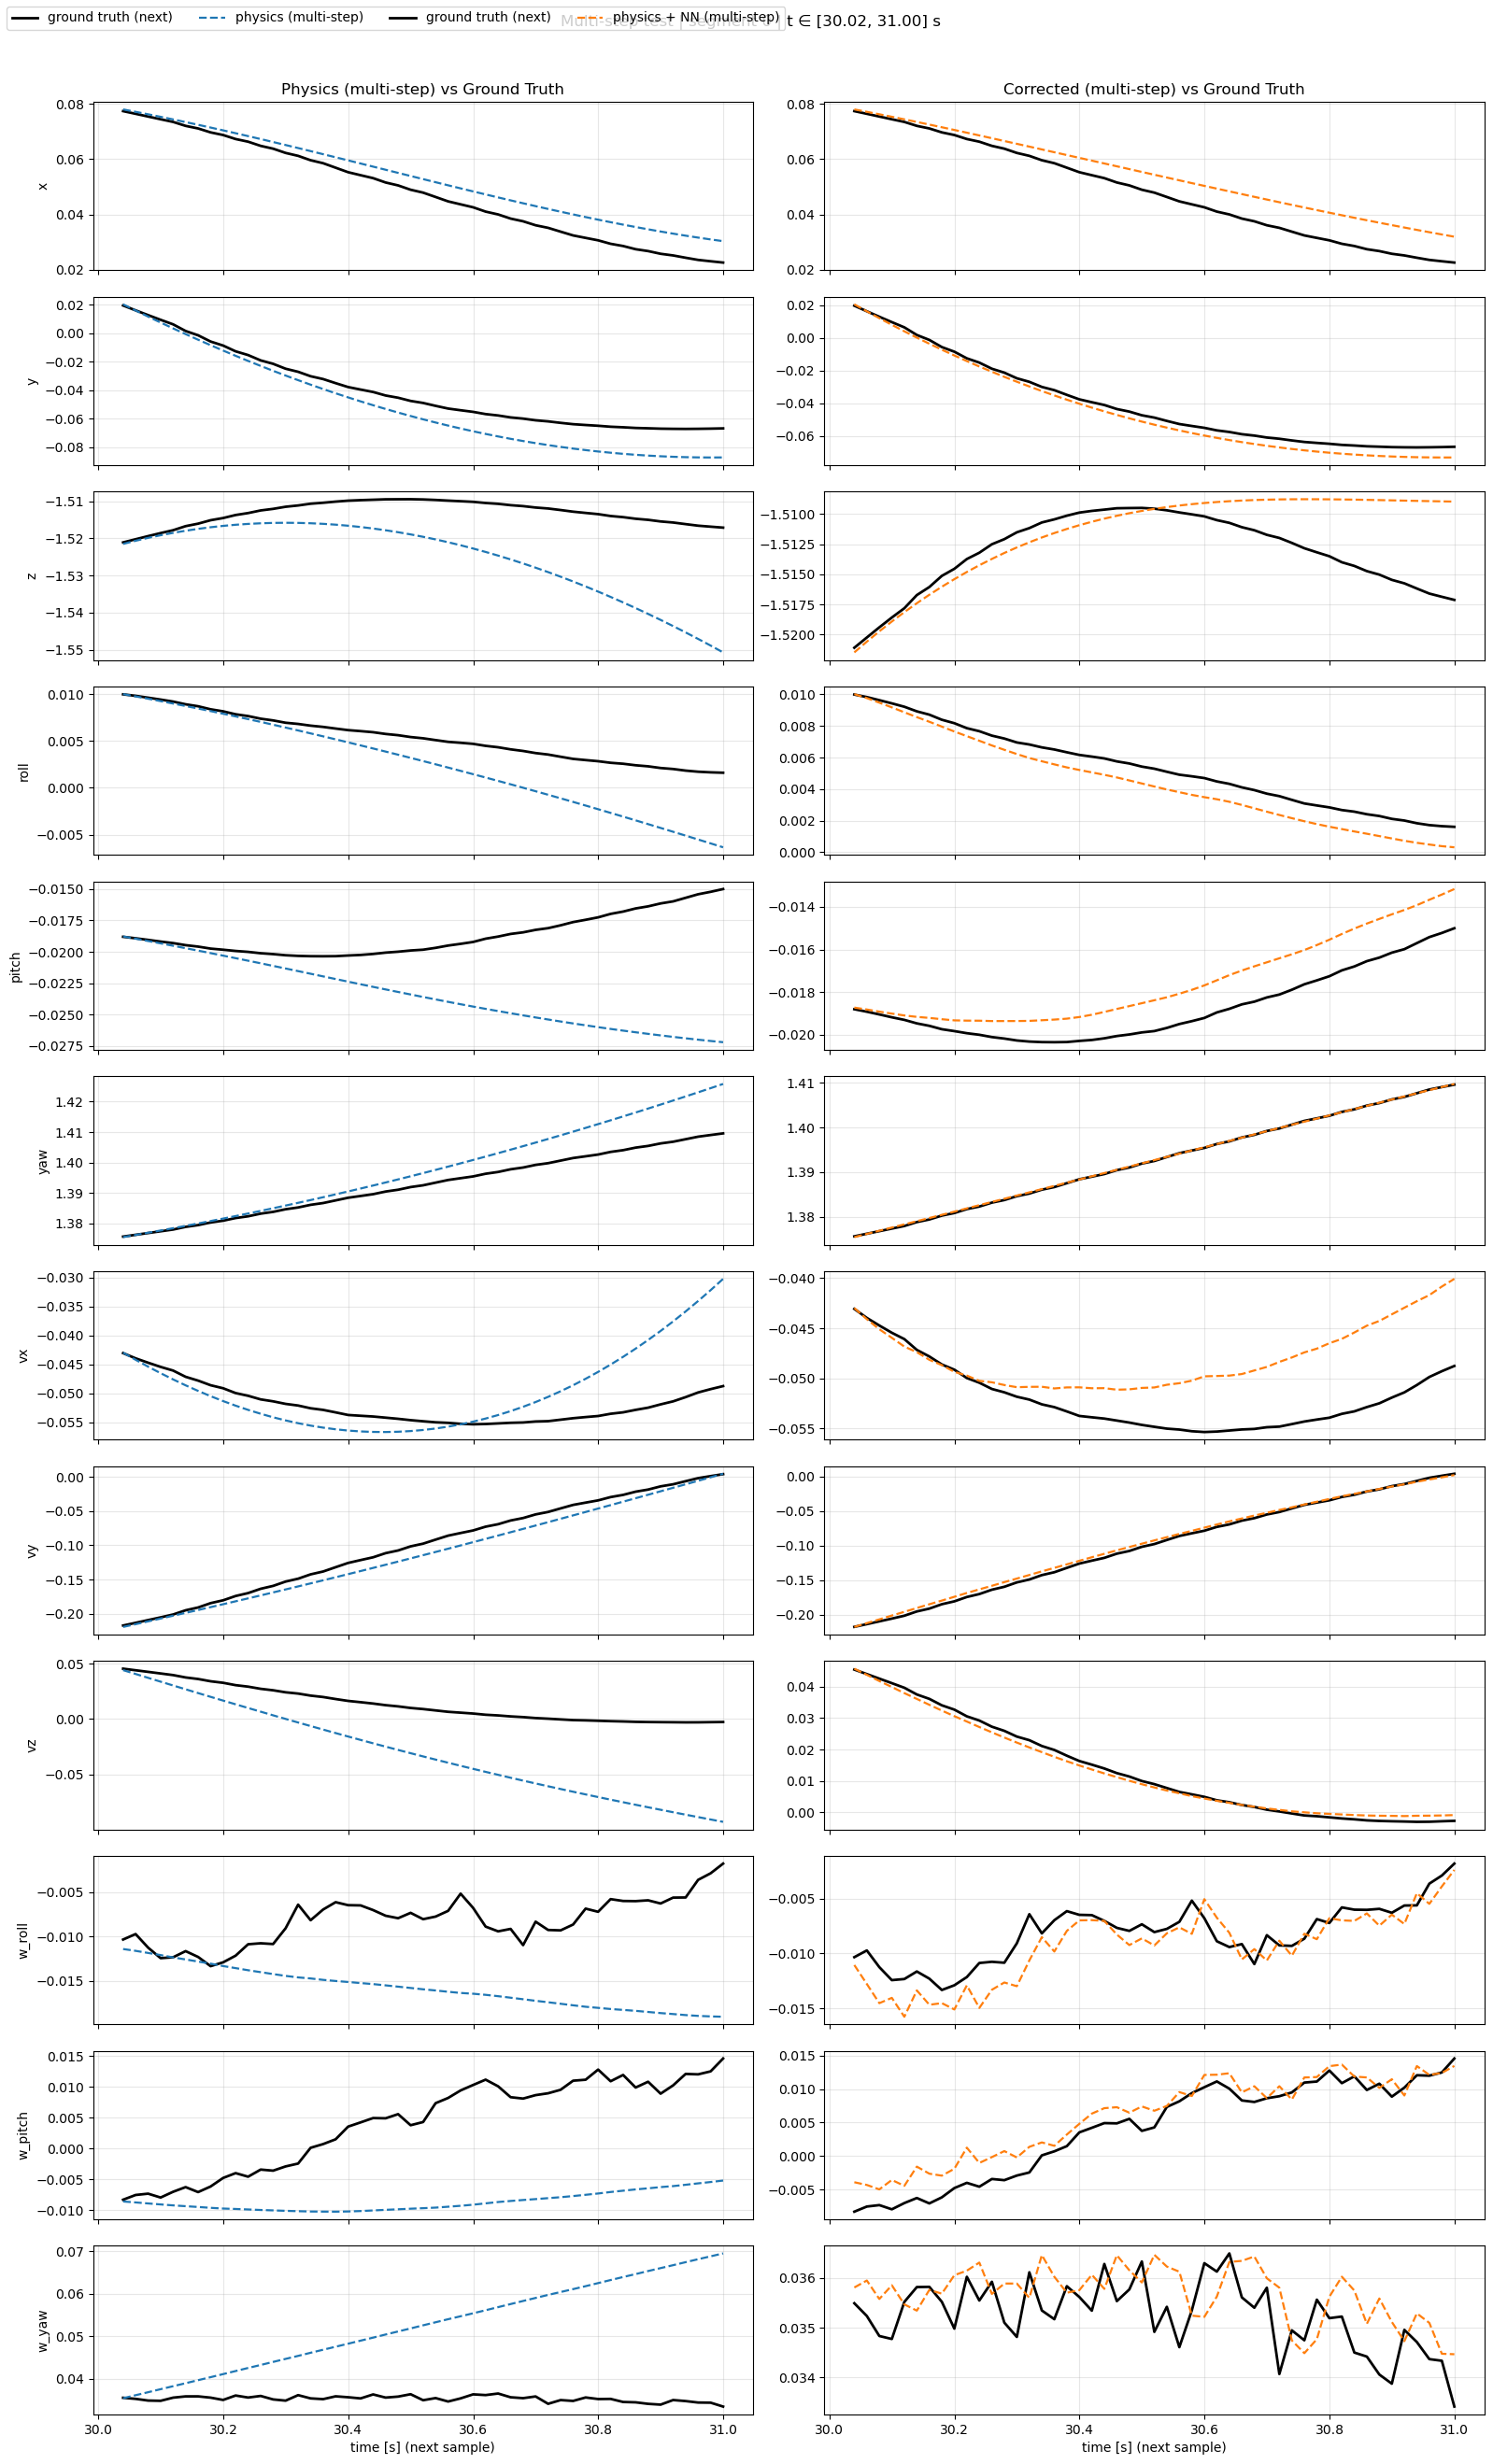

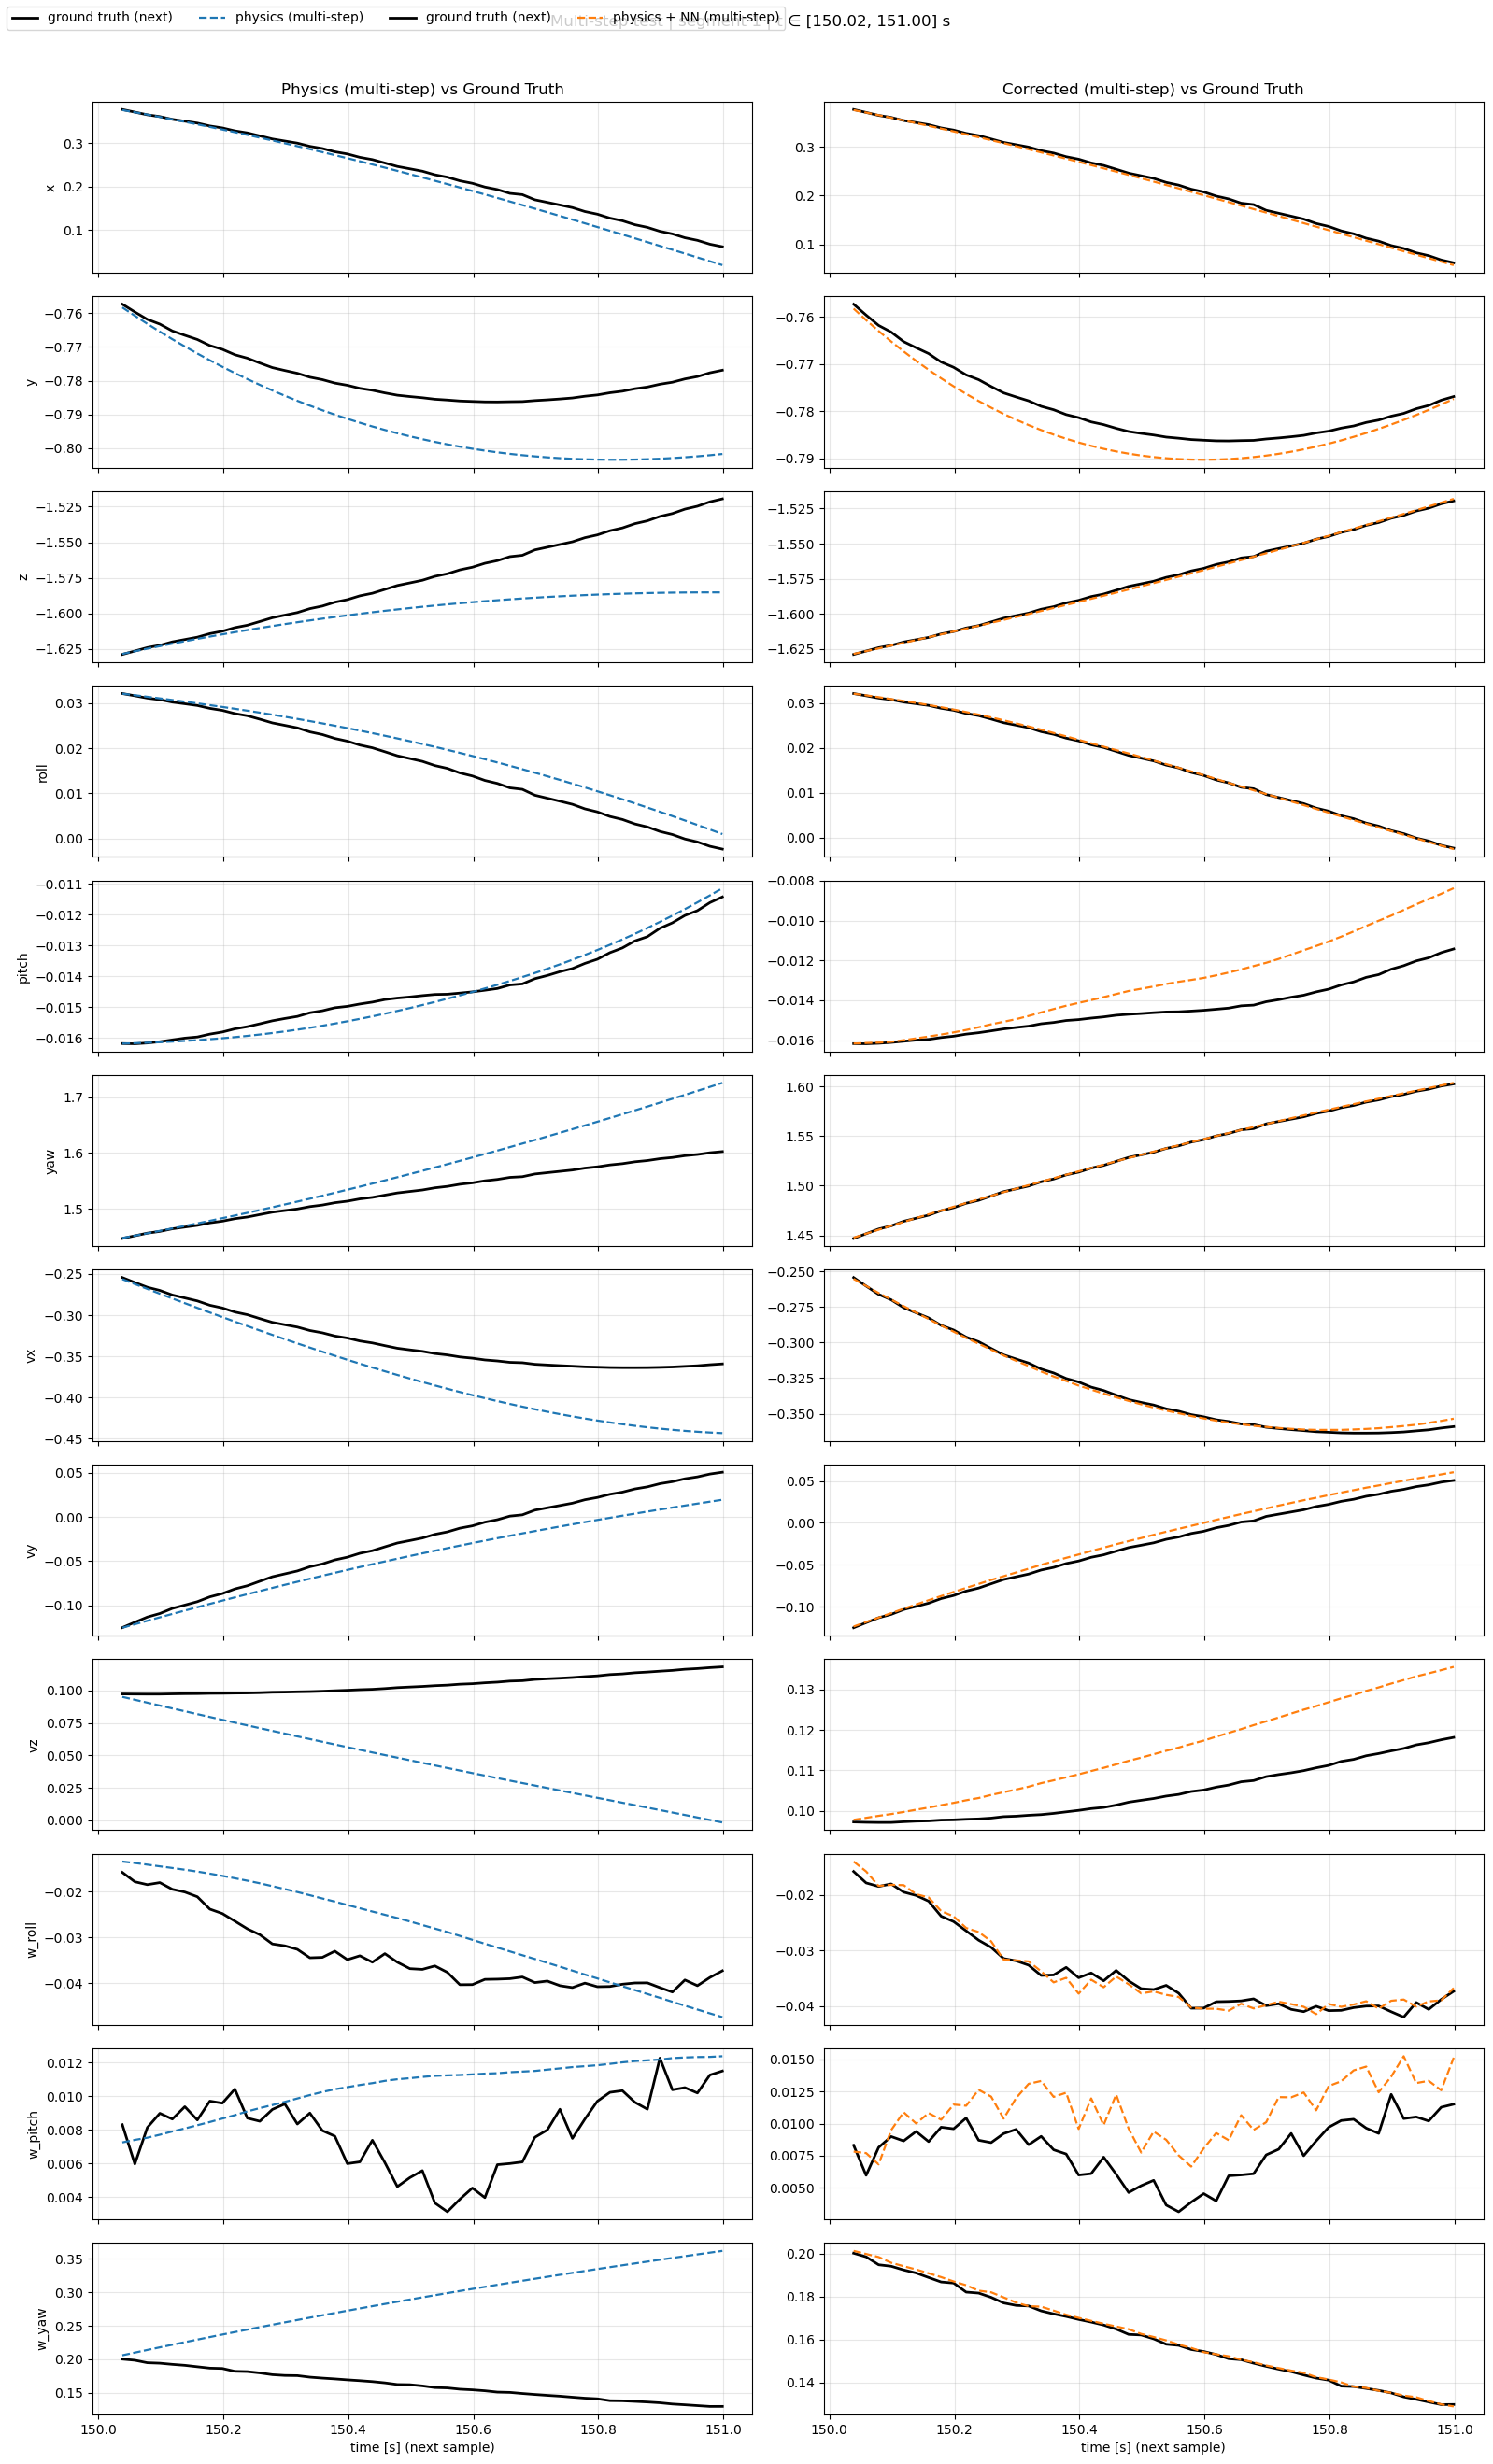

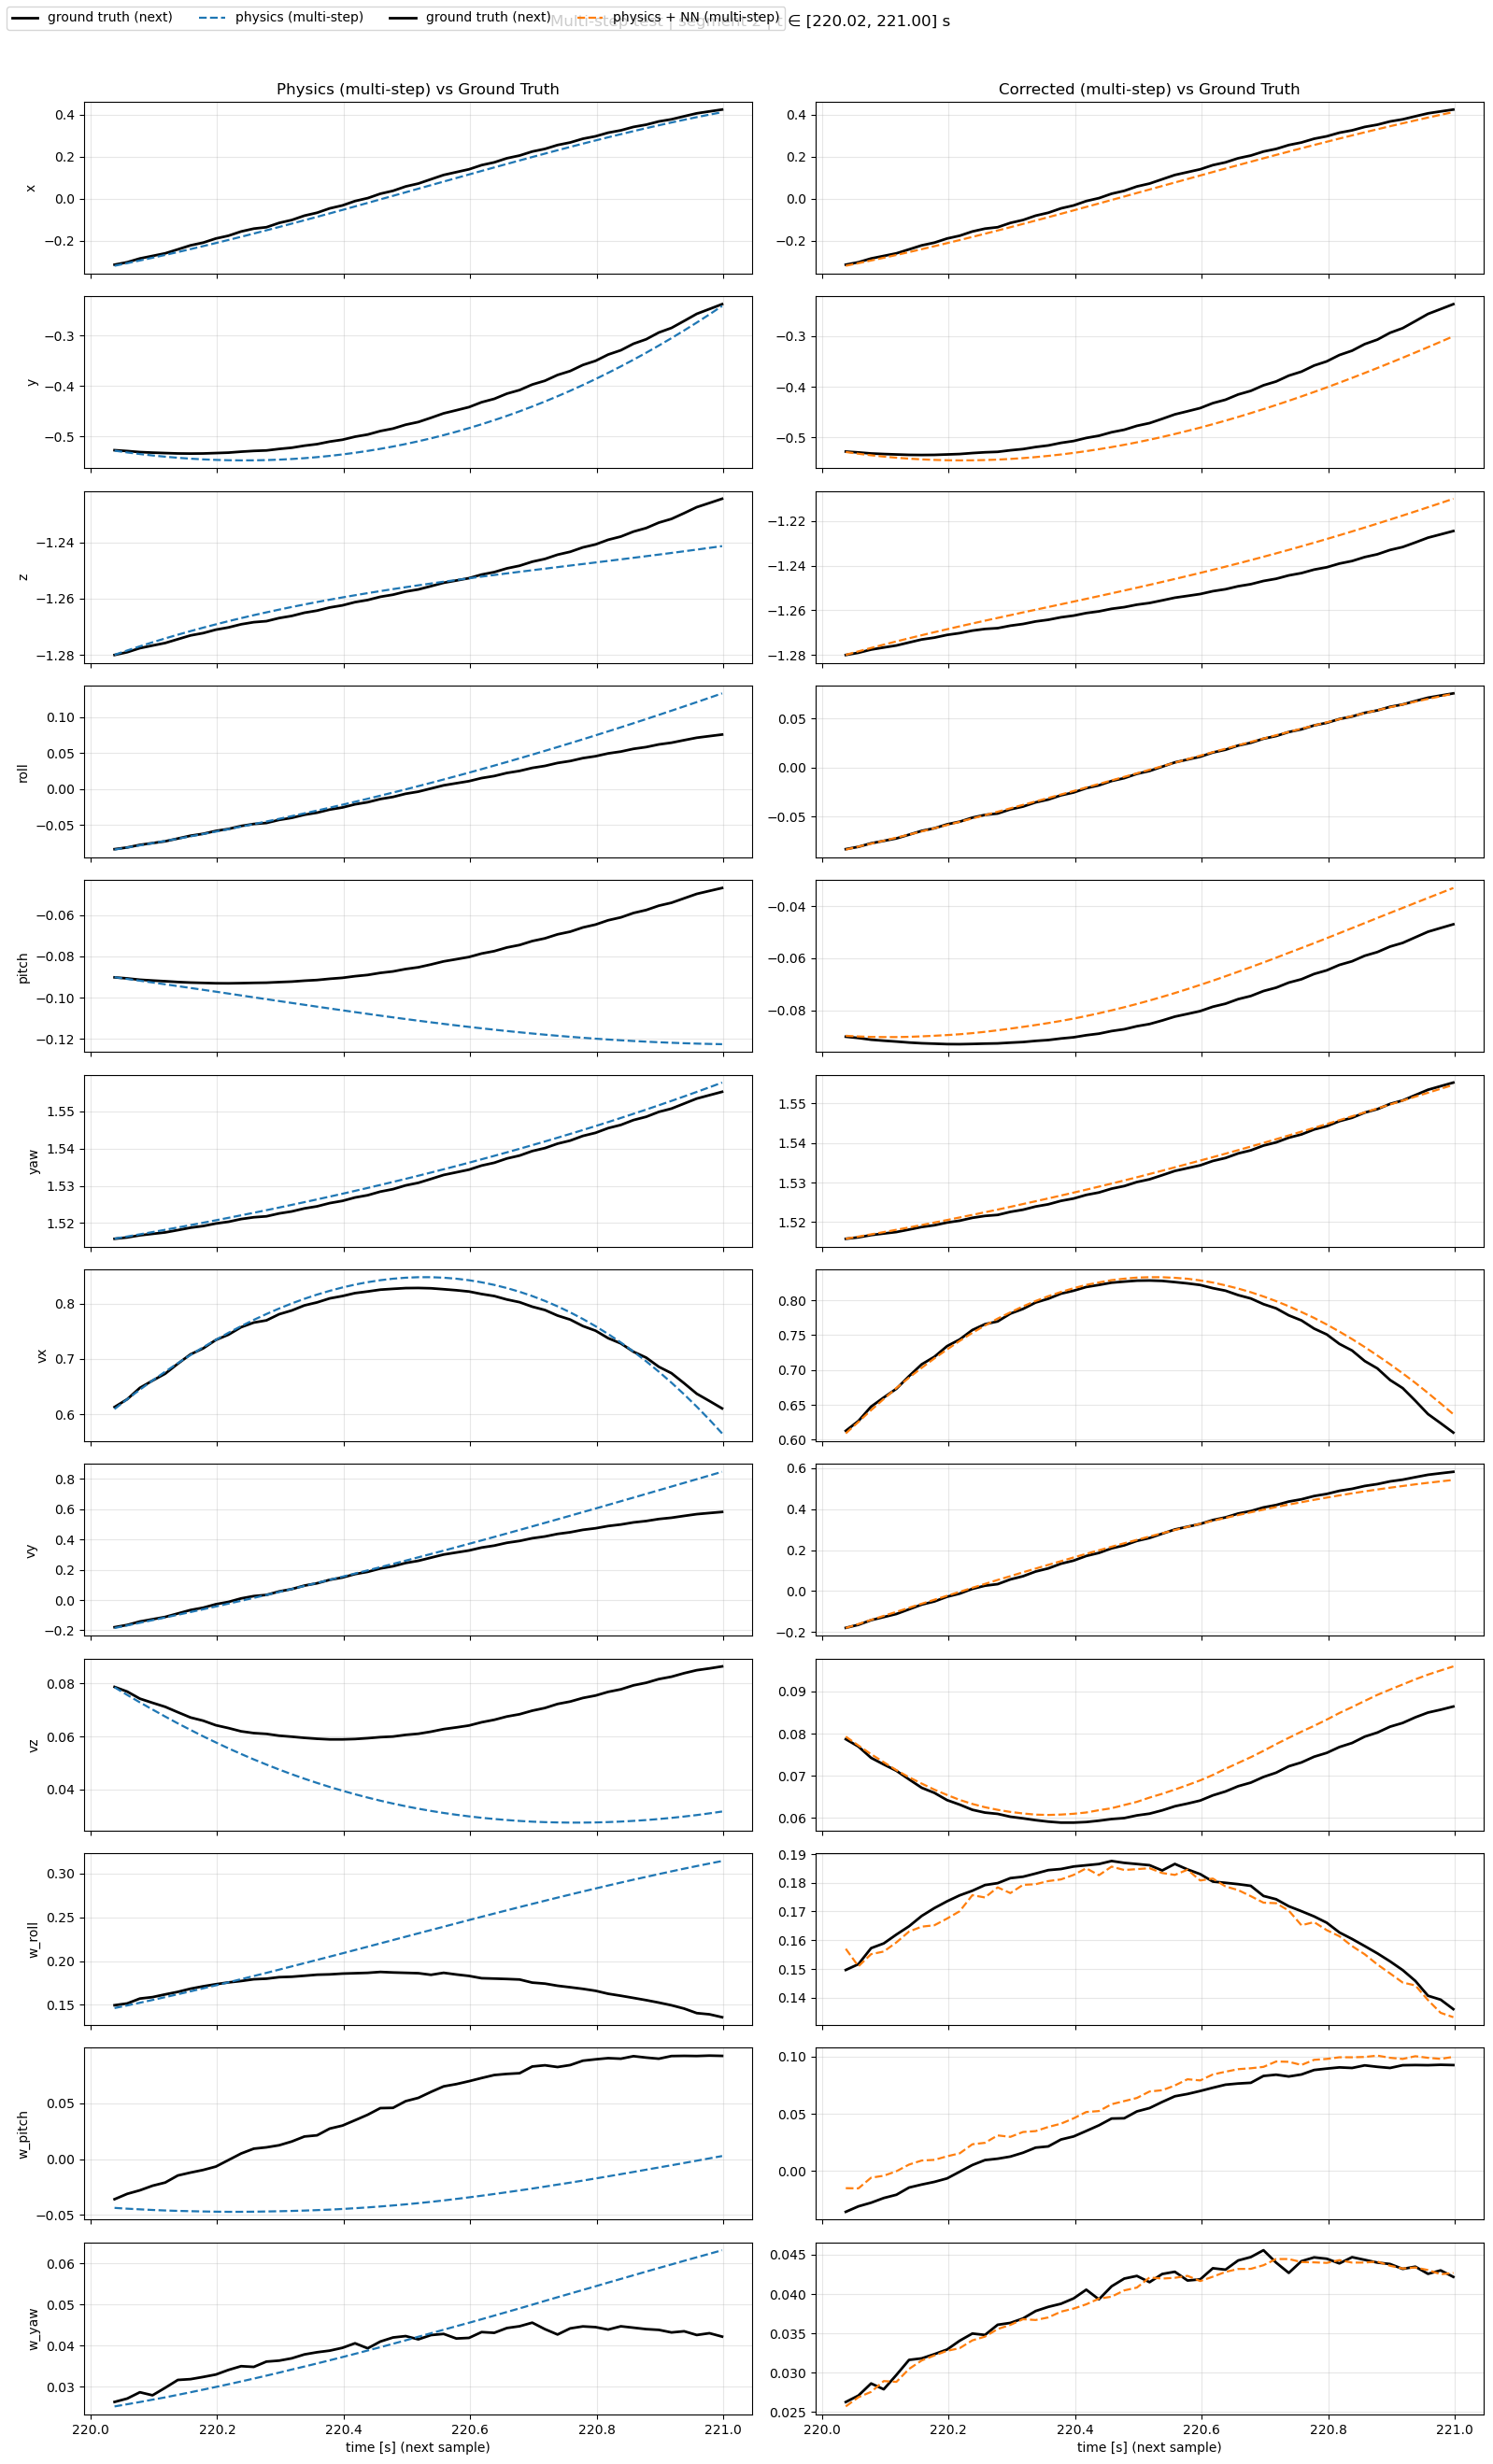

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

STATE_NAMES = ["x","y","z","roll","pitch","yaw","vx","vy","vz","w_roll","w_pitch","w_yaw"]

@torch.no_grad()
def multistep_rollout(model, X0, U_seq, dt_seq, mass, inertia, g, r_mean, r_std, use_nn=True):
    """
    X0:     (12,)
    U_seq:  (N-1,4)  controls at steps k=0..N-2
    dt_seq: (N-1,)   dt that takes you from k -> k+1 (aligned with U_seq)
    r_mean, r_std: (6,) residual normalization stats from TRAIN set
    returns:
      X_hat: (N,12) including X0 as first state
    """
    if dt_seq.ndim != 1:
        dt_seq = dt_seq.view(-1)

    N_minus_1 = U_seq.shape[0]
    dev = X0.device
    dtype = X0.dtype

    # move stats to same device/dtype
    r_mean = r_mean.to(device=dev, dtype=dtype).view(1, 6)
    r_std  = r_std.to(device=dev, dtype=dtype).view(1, 6)

    X_hat = torch.zeros((N_minus_1 + 1, 12), device=dev, dtype=dtype)
    X_hat[0] = X0

    x = X0.view(1, 12)
    for k in range(N_minus_1):
        u = U_seq[k].view(1, 4)
        dt = dt_seq[k].view(1, 1)

        if use_nn:
            # model output is normalized residual
            delta_vw_n = model(x, u)           # (1,6)
            delta_vw   = delta_vw_n * r_std + r_mean
        else:
            delta_vw = torch.zeros((1, 6), device=dev, dtype=dtype)

        x_next = compute_new_pos_angles(delta_vw, x, u, dt, mass, inertia, g)  # (1,12)

        # safety check
        if not torch.isfinite(x_next).all():
            raise RuntimeError(f"NaN/Inf detected at rollout step k={k}")

        X_hat[k + 1] = x_next.view(12)
        x = x_next

    return X_hat


def plot_two_column_next_state(t_next, X_next_gt, X_next_phys, X_next_corr, title):
    n_states = 12
    fig, axes = plt.subplots(n_states, 2, figsize=(16, 2.2 * n_states), sharex=True)

    for i in range(n_states):
        axL = axes[i, 0]
        axL.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth (next)")
        axL.plot(t_next, X_next_phys[:, i], "C0--", lw=1.6, label="physics (multi-step)")
        axL.set_ylabel(STATE_NAMES[i])
        axL.grid(True, alpha=0.3)
        if i == 0:
            axL.set_title("Physics (multi-step) vs Ground Truth")
        if i == n_states - 1:
            axL.set_xlabel("time [s] (next sample)")

        axR = axes[i, 1]
        axR.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth (next)")
        axR.plot(t_next, X_next_corr[:, i], "C1--", lw=1.6, label="physics + NN (multi-step)")
        axR.grid(True, alpha=0.3)
        if i == 0:
            axR.set_title("Corrected (multi-step) vs Ground Truth")
        if i == n_states - 1:
            axR.set_xlabel("time [s] (next sample)")

    handlesL, labelsL = axes[0, 0].get_legend_handles_labels()
    handlesR, labelsR = axes[0, 1].get_legend_handles_labels()
    fig.legend(handlesL + handlesR, labelsL + labelsR, loc="upper left", ncol=4, frameon=True)

    fig.suptitle(title, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()


# ---------- run on your test segments ----------
mass = 2.0
inertia = torch.tensor([0.0217, 0.0217, 0.04], dtype=torch.float32, device=device)
g = 9.81

model = trained_model.to(device)
model.eval()

# ensure these are tensors on device
r_mean_d = r_mean.to(device=device, dtype=torch.float32)
r_std_d  = r_std.to(device=device, dtype=torch.float32)

for seg_i, seg in enumerate(data_test_segments):
    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)   # (N,12)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)          # (N,4)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device)   # (N,)

    X_next_gt = X[1:, :]   # (N-1,12)
    t_next = seg[1:, 0]

    X0 = X[0]
    U_seq = U[:-1, :]
    dt_seq = dt[:-1]        # keep your original alignment choice

    X_hat_phys = multistep_rollout(
        model, X0, U_seq, dt_seq, mass, inertia, g, r_mean_d, r_std_d, use_nn=False
    )
    X_hat_corr = multistep_rollout(
        model, X0, U_seq, dt_seq, mass, inertia, g, r_mean_d, r_std_d, use_nn=True
    )

    X_next_phys = X_hat_phys[1:, :]
    X_next_corr = X_hat_corr[1:, :]

    plot_two_column_next_state(
        t_next=t_next,
        X_next_gt=X_next_gt.detach().cpu().numpy(),
        X_next_phys=X_next_phys.detach().cpu().numpy(),
        X_next_corr=X_next_corr.detach().cpu().numpy(),
        title=f"Multi-step test | segment {seg_i} | t ∈ [{float(seg[0,0]):.2f}, {float(seg[-1,0]):.2f}] s"
    )

## **Step 8d: In 3D space**

## **Step 8e: Plot 3D trajectory, with Sys dyn (RMSE, cumsum)**

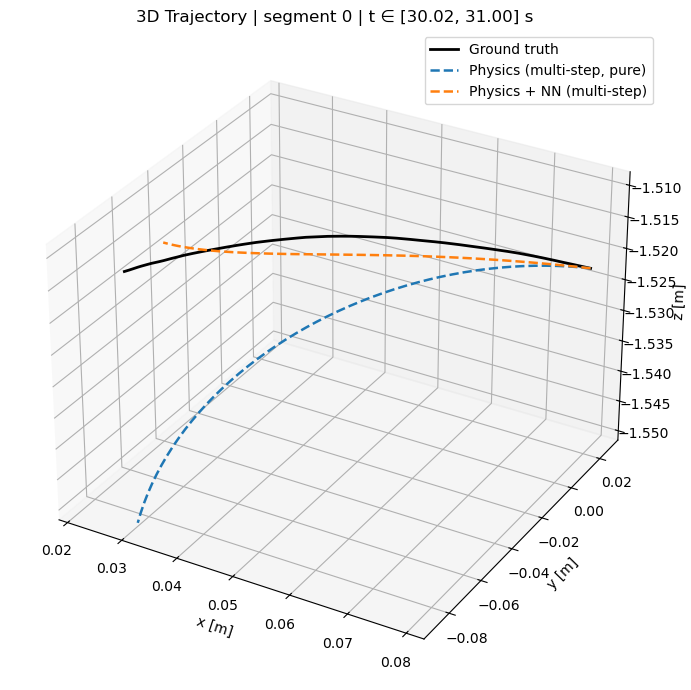

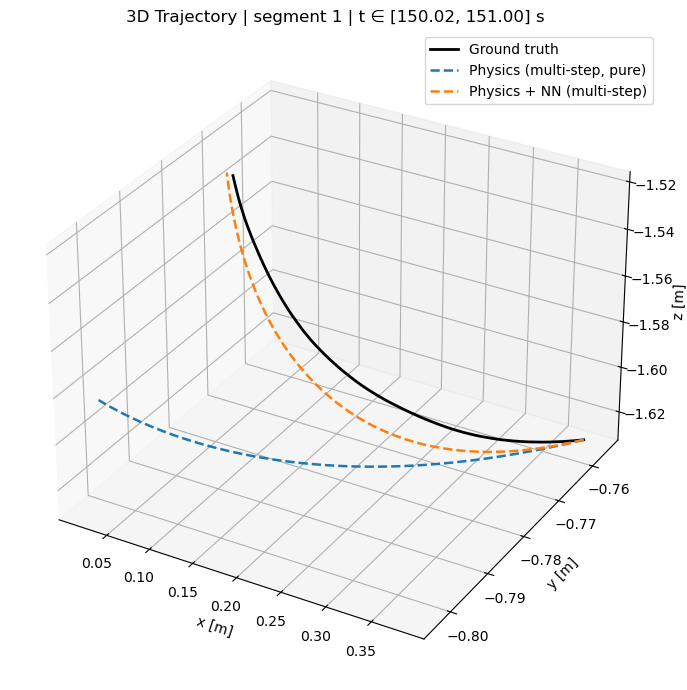

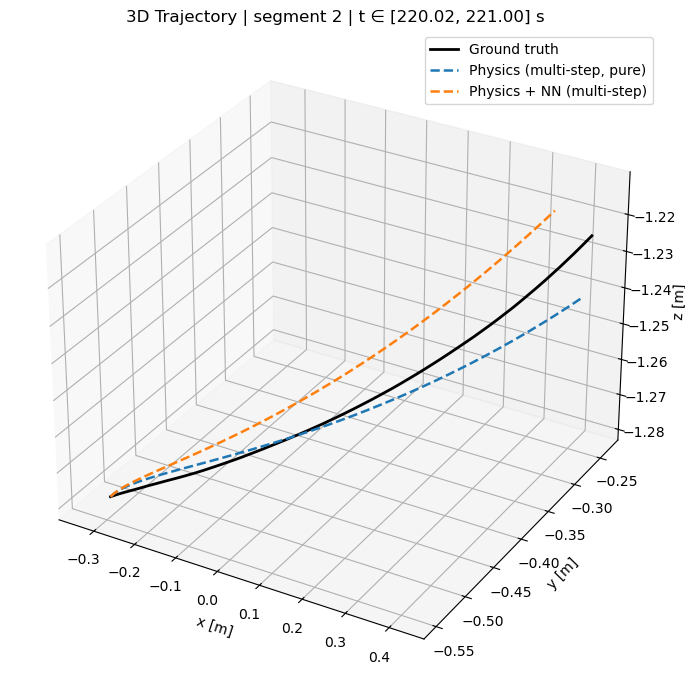

In [18]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

model = trained_model.to(device)
model.eval()

for seg_i, seg in enumerate(data_test_segments):
    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)  # (N,12)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)        # (N,4)

    # Robust dt per step from time column
    t = seg[:, 0].astype(np.float32)                       # (N,)
    dt_seq = torch.tensor(t[1:] - t[:-1], device=device)   # (N-1,)
    U_seq = U[:-1, :]                                      # (N-1,4)

    X0 = X[0]

    # Rollouts (N,12)
    X_hat_phys = multistep_rollout(model, X0, U_seq, dt_seq, mass, inertia, g, r_mean, r_std, use_nn=False)
    X_hat_corr = multistep_rollout(model, X0, U_seq, dt_seq, mass, inertia, g, r_mean, r_std, use_nn=True)

    # Convert to numpy for plotting
    gt = X.detach().cpu().numpy()
    phys = X_hat_phys.detach().cpu().numpy()
    corr = X_hat_corr.detach().cpu().numpy()

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(gt[:, 0],   gt[:, 1],   gt[:, 2],   "k-",  lw=2.0, label="Ground truth")
    ax.plot(phys[:, 0], phys[:, 1], phys[:, 2], "C0--", lw=1.8, label="Physics (multi-step, pure)")
    ax.plot(corr[:, 0], corr[:, 1], corr[:, 2], "C1--", lw=1.8, label="Physics + NN (multi-step)")

    ax.set_title(f"3D Trajectory | segment {seg_i} | t ∈ [{t[0]:.2f}, {t[-1]:.2f}] s")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")

    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

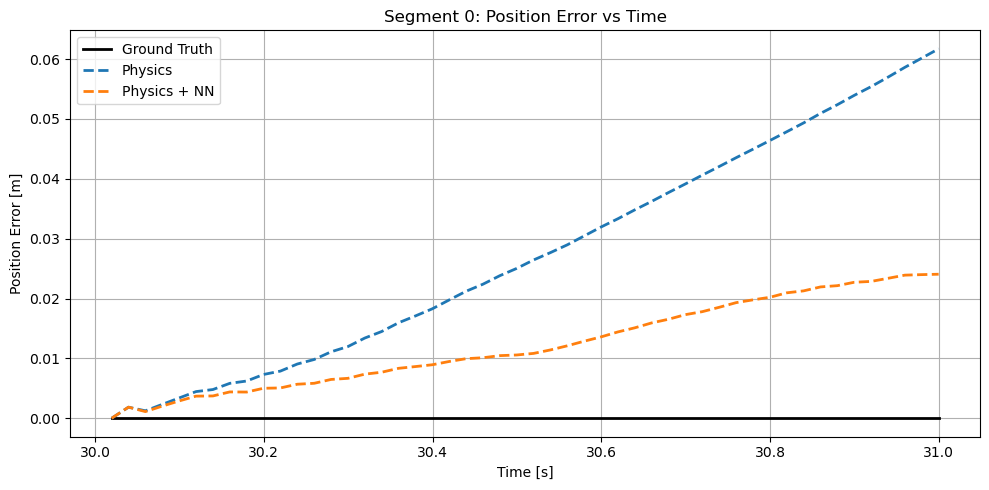

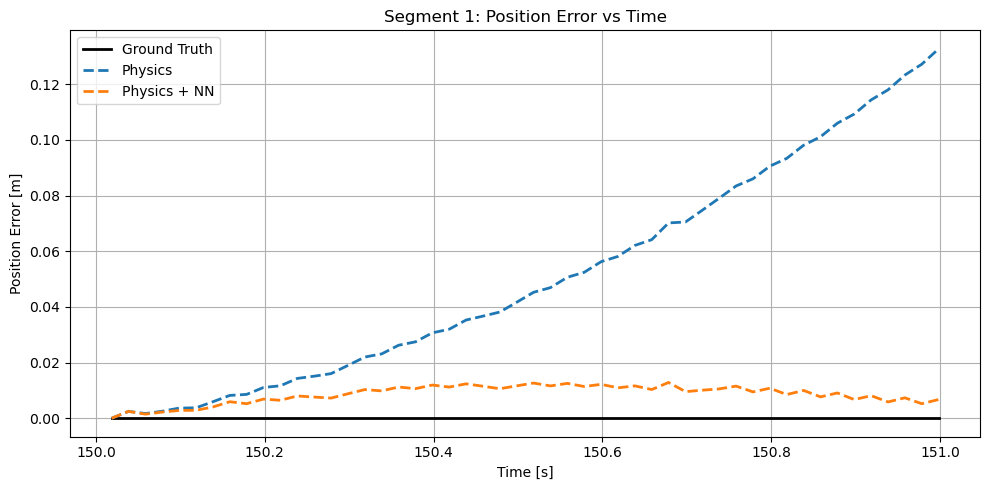

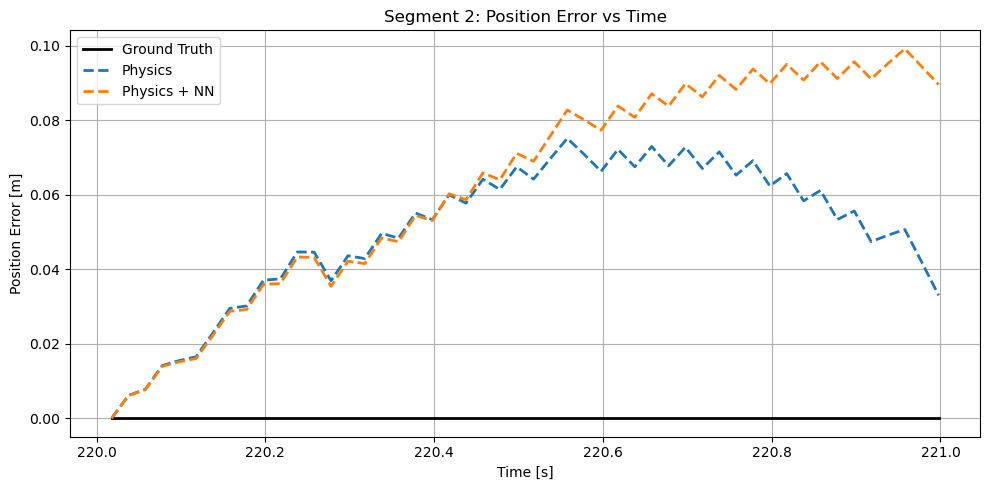

In [19]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

model = trained_model.to(device)
model.eval()

for seg_i, seg in enumerate(data_test_segments):

    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)

    # Time vector
    t = seg[:, 0].astype(np.float32)

    # Per-step dt
    dt_seq = torch.tensor(t[1:] - t[:-1], dtype=torch.float32, device=device)

    # Inputs aligned with transitions
    U_seq = U[:-1, :]

    # Initial state
    X0 = X[0]

    # Rollouts
    X_hat_phys = multistep_rollout(
        model, X0, U_seq, dt_seq,
        mass, inertia, g,
        r_mean, r_std,
        use_nn=False
    )

    X_hat_corr = multistep_rollout(
        model, X0, U_seq, dt_seq,
        mass, inertia, g,
        r_mean, r_std,
        use_nn=True
    )

    # Convert to numpy
    gt   = X.detach().cpu().numpy()
    phys = X_hat_phys.detach().cpu().numpy()
    corr = X_hat_corr.detach().cpu().numpy()

    # ---------------------------------------------------
    # Position error magnitude
    # ---------------------------------------------------
    #err_phys = np.linalg.norm(phys[:, 0:3] - gt[:, 0:3], axis=1)
    #err_corr = np.linalg.norm(corr[:, 0:3] - gt[:, 0:3], axis=1)
    err_phys = np.sum(np.abs(phys[:,0:3] - gt[:,0:3]), axis=1)
    err_corr = np.sum(np.abs(corr[:,0:3] - gt[:,0:3]), axis=1)

    # ---------------------------------------------------
    # Plot
    # ---------------------------------------------------
    plt.figure(figsize=(10,5))

    # Ground truth = zero error
    plt.plot(t, np.zeros_like(t), 'k-', lw=2, label='Ground Truth')

    # Model errors
    plt.plot(t, err_phys, 'C0--', lw=2, label='Physics')
    plt.plot(t, err_corr, 'C1--', lw=2, label='Physics + NN')

    plt.xlabel("Time [s]")
    plt.ylabel("Position Error [m]")
    plt.title(f"Segment {seg_i}: Position Error vs Time")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

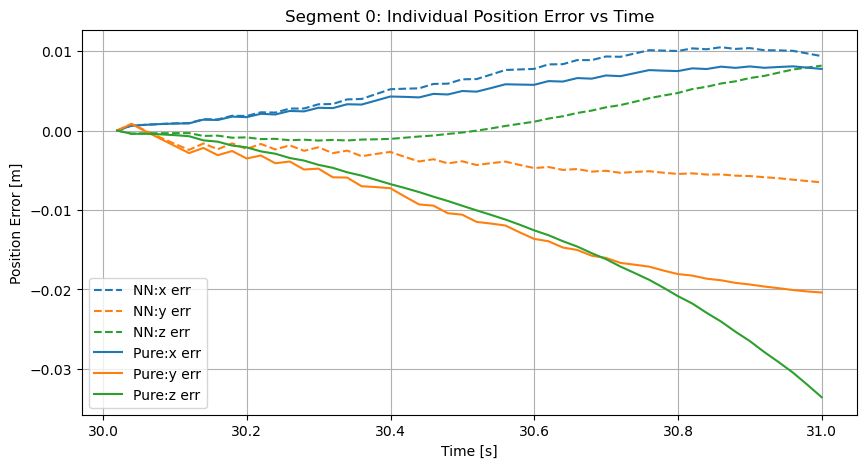

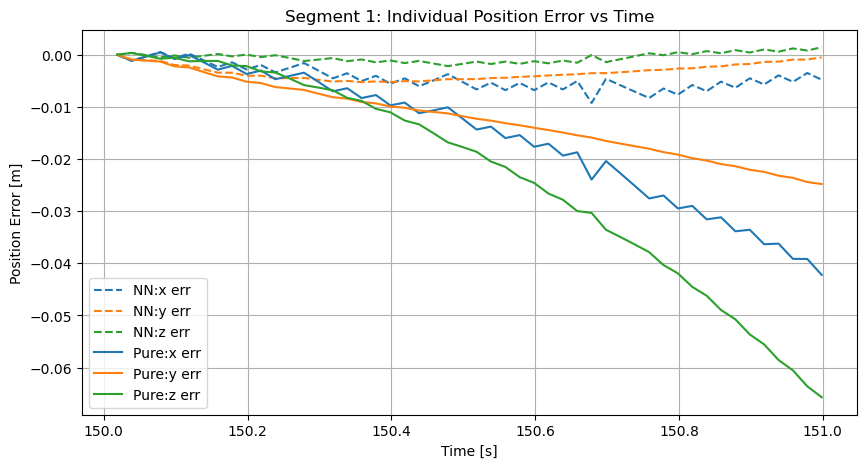

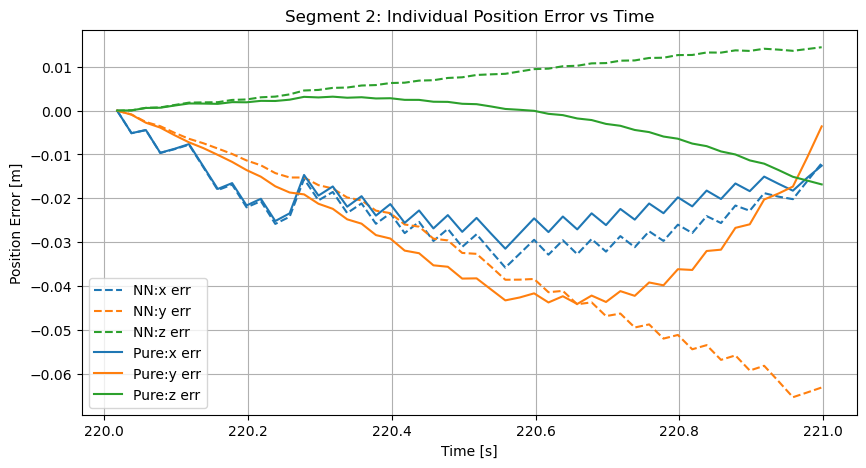

In [20]:
for seg_i, seg in enumerate(data_test_segments):

    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)

    # Time vector
    t = seg[:, 0].astype(np.float32)

    # Per-step dt
    dt_seq = torch.tensor(t[1:] - t[:-1], dtype=torch.float32, device=device)

    # Inputs aligned with transitions
    U_seq = U[:-1, :]

    # Initial state
    X0 = X[0]

    # Rollouts
    X_hat_phys = multistep_rollout(
        model, X0, U_seq, dt_seq,
        mass, inertia, g,
        r_mean, r_std,
        use_nn=False
    )

    X_hat_corr = multistep_rollout(
        model, X0, U_seq, dt_seq,
        mass, inertia, g,
        r_mean, r_std,
        use_nn=True
    )

    # Convert to numpy
    gt   = X.detach().cpu().numpy()
    phys = X_hat_phys.detach().cpu().numpy()
    corr = X_hat_corr.detach().cpu().numpy()

    # ---------------------------------------------------
    # Position error magnitude
    # ---------------------------------------------------
    #err_phys = np.linalg.norm(phys[:, 0:3] - gt[:, 0:3], axis=1)
    #err_corr = np.linalg.norm(corr[:, 0:3] - gt[:, 0:3], axis=1)
    err_phys = np.sum(np.abs(phys[:,0:3] - gt[:,0:3]), axis=1)
    err_corr = np.sum(np.abs(corr[:,0:3] - gt[:,0:3]), axis=1)


    pos_err = corr[:,0:3] - gt[:,0:3]
    err_phys = phys[:,0:3] - gt[:,0:3]
    plt.figure(figsize=(10,5))
    
    plt.plot(t, pos_err[:,0], 'C0--', label='NN:x err')
    plt.plot(t, pos_err[:,1], 'C1--', label='NN:y err')
    plt.plot(t, pos_err[:,2], 'C2--', label='NN:z err')
    plt.plot(t, err_phys[:,0], label='Pure:x err')
    plt.plot(t, err_phys[:,1], label='Pure:y err')
    plt.plot(t, err_phys[:,2], label='Pure:z err')
    plt.xlabel("Time [s]")
    plt.ylabel("Position Error [m]")
    plt.title(f"Segment {seg_i}: Individual Position Error vs Time")
    plt.legend()
    plt.grid()

In [21]:
import torch

@torch.no_grad()
def channel_stats(x, name):
    # x: (N, C)
    mean = x.mean(dim=0)
    std  = x.std(dim=0, unbiased=False)
    var  = std**2
    q05  = torch.quantile(x, 0.05, dim=0)
    q50  = torch.quantile(x, 0.50, dim=0)
    q95  = torch.quantile(x, 0.95, dim=0)
    print(f"\n{name}")
    print("mean:", mean.cpu().numpy())
    print("std :", std.cpu().numpy())
    print("var :", var.cpu().numpy())
    print("q05 :", q05.cpu().numpy())
    print("q50 :", q50.cpu().numpy())
    print("q95 :", q95.cpu().numpy())
    return {"mean": mean, "std": std, "var": var}

@torch.no_grad()
def compare_variance(train_x, val_x, ch_names):
    tr = channel_stats(train_x, "TRAIN")
    va = channel_stats(val_x, "VAL")

    var_ratio = va["var"] / (tr["var"] + 1e-12)   # >1 means val more variable
    std_ratio = va["std"] / (tr["std"] + 1e-12)

    print("\nVariance ratio (val/train):")
    for i, c in enumerate(ch_names):
        print(f"{c:>4}: var_ratio={var_ratio[i].item():.3f}, std_ratio={std_ratio[i].item():.3f}")

    return var_ratio, std_ratio

import matplotlib.pyplot as plt

@torch.no_grad()
def plot_histograms(train_x, val_x, ch_names, bins=100):
    train_x = train_x.cpu()
    val_x   = val_x.cpu()

    n_channels = train_x.shape[1]

    for i in range(n_channels):
        plt.figure(figsize=(6,4))

        plt.hist(train_x[:, i], bins=bins, alpha=0.5, label="train", density=True)
        plt.hist(val_x[:, i],   bins=bins, alpha=0.5, label="val",   density=True)

        plt.title(f"Distribution: {ch_names[i]}")
        plt.legend()
        plt.grid(True)
        plt.show()


from scipy.stats import ks_2samp

def ks_test(train_x, val_x, ch_names):
    train_x = train_x.cpu().numpy()
    val_x   = val_x.cpu().numpy()

    print("\nKS test (train vs val):")
    for i, name in enumerate(ch_names):
        stat, p = ks_2samp(train_x[:, i], val_x[:, i])
        print(f"{name:>4}: KS stat={stat:.4f}, p-value={p:.4f}")


TRAIN
mean: [ 1.2566832e-04  5.0589861e-04  1.5658489e-03 -6.3539257e-05
  1.0818975e-04  4.6059919e-05]
std : [0.00418874 0.00885963 0.0039807  0.02378363 0.0308311  0.00187558]
var : [1.7545583e-05 7.8492987e-05 1.5845972e-05 5.6566112e-04 9.5055677e-04
 3.5177970e-06]
q05 : [-0.00534827 -0.00388385 -0.00420929 -0.03598076 -0.04322924 -0.00203356]
q50 : [ 1.4935248e-04  3.7831068e-04  2.1501407e-03  4.8539601e-05
 -4.2984495e-05  2.5269110e-06]
q95 : [0.00542394 0.00521135 0.00508776 0.03662713 0.04366133 0.00223922]

VAL
mean: [ 1.7423210e-04  4.4948427e-04  1.5106226e-03  2.8955750e-04
 -4.2836525e-04 -5.4363696e-05]
std : [0.00454248 0.00559398 0.0038583  0.02352829 0.02879717 0.0026248 ]
var : [2.0634114e-05 3.1292642e-05 1.4886507e-05 5.5358058e-04 8.2927704e-04
 6.8895515e-06]
q05 : [-0.00502496 -0.00378111 -0.00412566 -0.0408711  -0.04928128 -0.00215078]
q50 : [ 1.6805180e-04  3.5866274e-04  2.1733623e-03 -3.8804254e-05
 -2.4601351e-05 -3.2479875e-06]
q95 : [0.00553748 0.0052

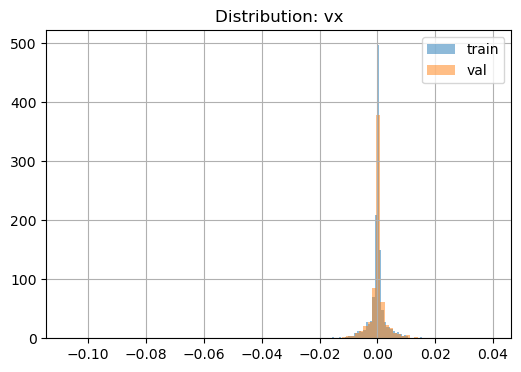

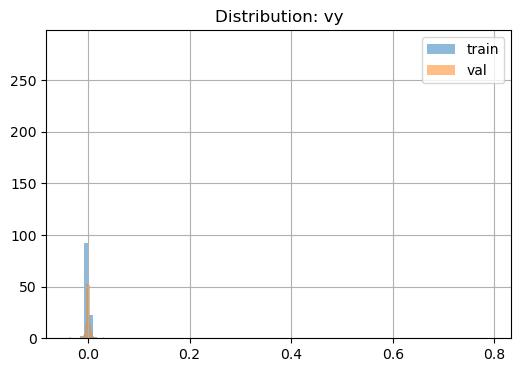

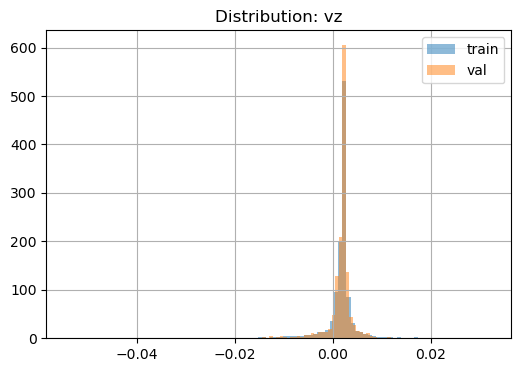

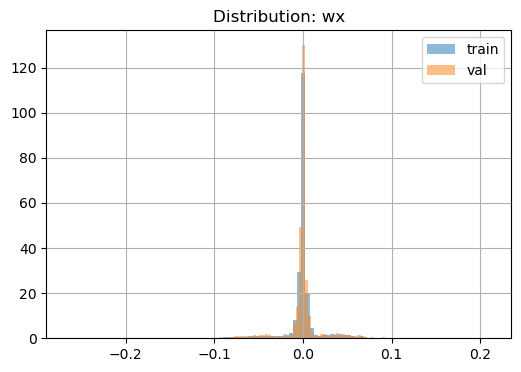

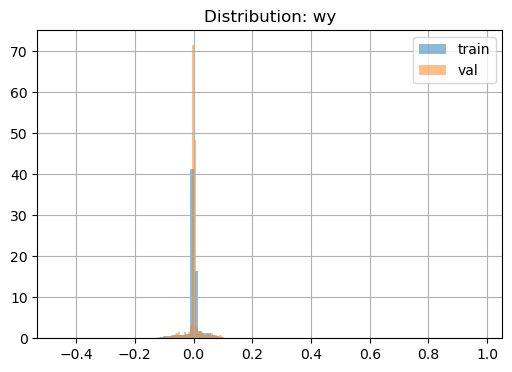

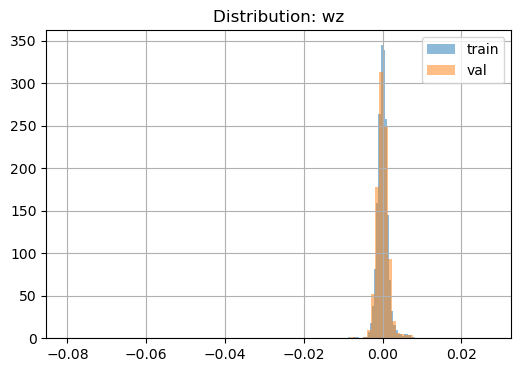


KS test (train vs val):
  vx: KS stat=0.0283, p-value=0.0617
  vy: KS stat=0.0226, p-value=0.2184
  vz: KS stat=0.0259, p-value=0.1086
  wx: KS stat=0.0198, p-value=0.3626
  wy: KS stat=0.0132, p-value=0.8403
  wz: KS stat=0.0251, p-value=0.1302


In [22]:
# Residual target in physical units
with torch.no_grad():
    xdot_tr = system_dynamics(X_train_phys_d, U_train_d, mass=mass, inertia=inertia, g=g)
    xdot_va = system_dynamics(X_val_phys_d,   U_val_d,   mass=mass, inertia=inertia, g=g)

    Xn_phys_tr = X_train_phys_d + xdot_tr * dt_train_d.view(-1,1)
    Xn_phys_va = X_val_phys_d   + xdot_va * dt_val_d.view(-1,1)

    r_tr = X_train_next_phys_d[:,6:12] - Xn_phys_tr[:,6:12]   # [vx,vy,vz,wx,wy,wz]
    r_va = X_val_next_phys_d[:,6:12]   - Xn_phys_va[:,6:12]

ch = ["vx","vy","vz","wx","wy","wz"]
compare_variance(r_tr, r_va, ch)
plot_histograms(r_tr, r_va, ch)
ks_test(r_tr, r_va, ch)